# Validation & Experimental Log — POD + Conditional Generative Surrogates

This notebook collects the **tests, smoke checks, benchmarks, diagnostic runs, and numerical validations carried out outside the Git repository** while the thesis codebase was being refactored and extended.

The stable implementation of the project lives in `src/spde_surrogates/...`. This notebook has a different purpose: it acts as an **experimental validation log**. Its role is to document how each component was checked before being considered reliable, to preserve the outputs used to make methodological decisions, and to provide a reproducible record of the intermediate experiments that led to the final static-surrogate comparison.

The notebook therefore contains both successful checks and a few historical troubleshooting cells. Errors that appear in some intermediate outputs should not be interpreted as failures of the final pipeline: they are intentionally kept when they help document how an interface mismatch, import issue, or configuration problem was diagnosed and fixed.

The main objectives validated here are the equivalence between the legacy and refactored implementations, the correctness of the data/POD pipeline, the implementation of conditional RealNVP and Flow Matching, the construction of a common evaluation framework, and the comparison of the two generative approaches on progressively more robust datasets.


## Main results at a glance

The validation process eventually led to two main experiments. The first one is a pilot with `20` parameter configurations and `10` stochastic realizations for each parameter. The second one doubles the number of parameter configurations while keeping the same number of realizations per parameter, resulting in a more robust `40 × 10` experiment.

For the **20 × 10 pilot**, the full-order trajectories contain 101 time instants and 2763 spatial degrees of freedom. POD reduces the state dimension to **76 modes**, with a test reconstruction error of about **1.27%**. On the unseen test parameters, the mean trajectory Energy Distance is approximately **22.14 for RealNVP** and **8.27 for Flow Matching**, corresponding to a reduction of about **62.6%** in favor of Flow Matching. Flow Matching is better on all **3/3** test parameter configurations. The price for this accuracy is sampling time: for 100 generated trajectories, RealNVP takes about **0.98 s**, while Flow Matching takes about **9.44 s**.

The **40 × 10 experiment** confirms the same qualitative picture on a larger parameter set. The split contains 28 training parameters, 6 validation parameters, and 6 unseen test parameters, with no group leakage. POD selects **79 modes** and achieves a test reconstruction error of about **1.22%**. The mean Energy Distance decreases from **19.13 for RealNVP** to **7.86 for Flow Matching**, a reduction of about **58.9%**, and Flow Matching is better on all **6/6** test configurations. At `N=100`, generation takes about **1.07 s** for RealNVP and **9.99 s** for Flow Matching.

Taken together, the experiments reveal a clear and stable **accuracy–efficiency trade-off**: Flow Matching provides substantially better distributional accuracy, while RealNVP remains considerably faster during online generation.


## How this notebook is organized

The notebook is structured as a validation narrative rather than as a single executable pipeline. The first part checks that the refactoring from the original notebooks to reusable Python modules preserves the numerical behavior of the existing code. The second part develops and validates the `20 × 10` pilot experiment. The third part repeats the comparison on the larger `40 × 10` dataset. The fourth part contains the final methodological checks on the Energy Distance estimator and on temporal coupling. The last part consolidates the results and verifies that all relevant artifacts have been saved persistently.

This structure is meant to make the notebook readable even without rerunning the expensive FOM calculations. The individual code cells show the checks that were performed, while the text cells explain why each check matters and how its output influenced the next step.


# Part I — Validation of the refactored pipeline

## 1. FOM, dataset construction, and POD equivalence

The first goal is to verify that moving the physical problem, the dataset builder, and the POD implementation from exploratory notebooks into reusable modules has not changed the numerical results. This is essential because the refactoring should improve structure and reusability without silently altering the underlying computation.

A deliberately small dataset is used here so that the legacy and refactored implementations can be compared directly. The checks focus on the selected POD dimension, the mean field, the singular values, and the reconstructed trajectories.


In [ ]:
import randomized_advection_diffusion as rad
import dataset as ds
import numpy as np
import pod as pod_module

In [ ]:
test_cfg = {
    "n_mu": 2,
    "n_realizations": 2,
    "nimp": 3,
    "dt": 0.05,
    "steps": 2,
    "seed": 123,
}

In [ ]:
new_dataset = ds.build_fom_dataset(
    problem=rad,
    **test_cfg
)

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_afa50c16163fd6db5cadce9c8cb245fc6081510f

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00444913 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.407

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_00f5c99235d7c07341f6c63ebd682228a61240ae

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00315714 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0156698 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_3bd2a85d925e7a582c33aef1af5f85fe86c857d3

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      2
  Arguments:                 '(v_0, v_1)'
  Number of coefficients:    3
  Coefficients:              '[f_87, f_90, f_91]'
  Unique elements:           'CG1(?,?), Vector<2 x CG1(?,?)>, R0(?,?)'
  Unique sub elements:       'CG1(?,?), Vector<2 x CG1(?,?)>, R0(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 2
INFO:FFC:  quadrature_degree: 2
INFO:FFC:  
INFO:FF

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_366c7a16e123cba595a3af1b6de0cf32aa302c69

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00250101 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0131042 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

mu   1/2, realizzazione  1/2, U.shape=(3, 2763)
mu   1/2, realizzazione  2/2, U.shape=(3, 2763)
mu   2/2, realizzazione  1/2, U.shape=(3, 2763)
mu   2/2, realizzazione  2/2, U.shape=(3, 2763)


In [ ]:
(
    mu_bank_new,
    times_new,
    conds_new,
    trajectories_new,
    group_ids_new,
) = new_dataset

In [ ]:
print("mu_bank:", mu_bank_new.shape)
print("times:", times_new.shape)
print("conds:", conds_new.shape)
print("trajectories:", trajectories_new.shape)
print("group_ids:", group_ids_new.shape)

mu_bank: (2, 3)
times: (3,)
conds: (4, 3)
trajectories: (4, 3, 2763)
group_ids: (4,)


In [ ]:
trajectories_test = trajectories_new

In [ ]:
print(trajectories_test.shape)

(4, 3, 2763)


In [ ]:
pod_new = pod_module.PODReducer(
    target_error=1e-2,
    max_modes=100,
    selection="trajectory_error",
)

pod_new.fit(trajectories_test)

In [ ]:
import importlib
import pod as pod_module

importlib.reload(pod_module)

<module 'pod' from '/content/pod.py'>

In [ ]:
pod_new = pod_module.PODReducer(
    target_error=1e-2,
    max_modes=100,
    selection="trajectory_error",
)

pod_new.fit(trajectories_test)

In [ ]:
print("Selected POD modes:", pod_new.n_modes_)
print("Basis shape:", pod_new.basis_.shape)
print("Mean shape:", pod_new.mean_.shape)

Selected POD modes: 3
Basis shape: (3, 2763)
Mean shape: (1, 2763)


In [ ]:
coeff_new = pod_new.transform(
    trajectories_test
)

reconstructed_new = pod_new.inverse_transform(
    coeff_new
)

print("Original:", trajectories_test.shape)
print("Coefficients:", coeff_new.shape)
print("Reconstructed:", reconstructed_new.shape)

Original: (4, 3, 2763)
Coefficients: (4, 3, 3)
Reconstructed: (4, 3, 2763)


In [ ]:
Ntraj, Nt, Vdim = trajectories_test.shape

snapshots_old = trajectories_test.reshape(
    Ntraj * Nt,
    Vdim
)

mean_old = snapshots_old.mean(
    axis=0,
    keepdims=True
)

centered_old = snapshots_old - mean_old

_, sigma_old, Vt_old = np.linalg.svd(
    centered_old,
    full_matrices=False
)

In [ ]:
errors_2_old = []

n_test = min(
    100,
    Vt_old.shape[0]
)

for n in range(1, n_test + 1):

    coeff = centered_old @ Vt_old[:n].T

    rec = (
        mean_old
        + coeff @ Vt_old[:n]
    )

    rec = rec.reshape(
        Ntraj,
        Nt,
        Vdim
    )

    num = np.linalg.norm(
        trajectories_test - rec,
        axis=-1
    )

    den = np.linalg.norm(
        trajectories_test,
        axis=-1
    )

    error_2 = np.mean(
        np.sum(num, axis=-1)
        /
        (
            np.sum(den, axis=-1)
            + 1e-12
        )
    )

    errors_2_old.append(error_2)

errors_2_old = np.array(errors_2_old)

In [ ]:
valid = np.where(
    errors_2_old <= 1e-2
)[0]

if len(valid) > 0:
    r_old = int(valid[0] + 1)
else:
    r_old = n_test

print("OLD r:", r_old)
print("NEW r:", pod_new.n_modes_)

OLD r: 3
NEW r: 3


In [ ]:
basis_old = Vt_old[:r_old]

coeff_old = (
    centered_old
    @ basis_old.T
)

reconstructed_old = (
    mean_old
    + coeff_old @ basis_old
)

reconstructed_old = reconstructed_old.reshape(
    Ntraj,
    Nt,
    Vdim
)

In [ ]:
print(
    "Same selected r:",
    r_old == pod_new.n_modes_
)

print(
    "Same mean:",
    np.allclose(
        mean_old,
        pod_new.mean_
    )
)

print(
    "Same singular values:",
    np.allclose(
        sigma_old,
        pod_new.singular_values_
    )
)

print(
    "Same reconstruction:",
    np.allclose(
        reconstructed_old,
        reconstructed_new
    )
)

print(
    "Max reconstruction difference:",
    np.max(
        np.abs(
            reconstructed_old
            - reconstructed_new
        )
    )
)

Same selected r: True
Same mean: True
Same singular values: True
Same reconstruction: True
Max reconstruction difference: 0.0


### Result and interpretation

The refactored POD reproduces the behavior of the previous implementation. The selected number of modes, the mean, the singular values, and the reconstructed trajectories agree with the reference calculation within numerical precision.

This is an important baseline result: from this point onward, differences observed in later experiments can be attributed to the generative models or to the experimental design rather than to an unintended change introduced by the POD refactoring.


## 2. Group-wise splitting and preprocessing

The train/validation/test split must be performed at the level of the conditioning parameter `μ`, not at the level of individual snapshots or trajectories. If realizations associated with the same parameter value were allowed to appear in both training and testing, the final generalization results would be overly optimistic.

This section therefore checks the group-wise split, the train-only fitting of the normalizers, the inverse transformation, and the construction of the static conditioning vector. In the static formulation, each reduced-order sample is conditioned on `(μ_1, μ_2, μ_3, t)`.


In [ ]:
import splitting as split_module
import preprocessing as prep
import numpy as np

In [ ]:
fake_group_ids = np.repeat(
    np.arange(10),
    3
)

print(fake_group_ids)

[0 0 0 1 1 1 2 2 2 3 3 3 4 4 4 5 5 5 6 6 6 7 7 7 8 8 8 9 9 9]


In [ ]:
split = split_module.split_by_group(
    fake_group_ids,
    train_fraction=0.6,
    val_fraction=0.2,
    test_fraction=0.2,
    seed=123,
)

In [ ]:
print(
    "Train groups:",
    split["train_groups"]
)

print(
    "Validation groups:",
    split["val_groups"]
)

print(
    "Test groups:",
    split["test_groups"]
)

print(
    "Train trajectories:",
    len(split["train_indices"])
)

print(
    "Validation trajectories:",
    len(split["val_indices"])
)

print(
    "Test trajectories:",
    len(split["test_indices"])
)

Train groups: [7 4 0 2 1 5]
Validation groups: [6 8]
Test groups: [3 9]
Train trajectories: 18
Validation trajectories: 6
Test trajectories: 6


In [ ]:
train_groups = set(
    split["train_groups"]
)

val_groups = set(
    split["val_groups"]
)

test_groups = set(
    split["test_groups"]
)

print(
    "Train ∩ Validation:",
    train_groups.intersection(
        val_groups
    )
)

print(
    "Train ∩ Test:",
    train_groups.intersection(
        test_groups
    )
)

print(
    "Validation ∩ Test:",
    val_groups.intersection(
        test_groups
    )
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [ ]:
X_train = np.array([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0],
    [4.0, 40.0],
])

X_test = np.array([
    [100.0, 1000.0]
])

In [ ]:
normalizer = prep.ArrayNormalizer()

X_train_norm = normalizer.fit_transform(
    X_train
)

X_test_norm = normalizer.transform(
    X_test
)

In [ ]:
print(
    "Train normalized mean:",
    X_train_norm.mean(axis=0)
)

print(
    "Train normalized std:",
    X_train_norm.std(axis=0)
)

Train normalized mean: [0. 0.]
Train normalized std: [1. 1.]


In [ ]:
X_reconstructed = (
    normalizer.inverse_transform(
        X_train_norm
    )
)

print(
    "Inverse correct:",
    np.allclose(
        X_train,
        X_reconstructed
    )
)

Inverse correct: True


In [ ]:
fake_mus = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
])

fake_times = np.array([
    0.0,
    0.5,
    1.0,
])

fake_coeff = np.random.randn(
    2,
    3,
    4,
)

In [ ]:
conditions, targets = (
    prep.build_static_samples(
        fake_mus,
        fake_times,
        fake_coeff,
    )
)

In [ ]:
print(
    "Conditions shape:",
    conditions.shape
)

print(
    "Targets shape:",
    targets.shape
)

print(
    conditions
)

Conditions shape: (6, 4)
Targets shape: (6, 4)
[[1.  2.  3.  0. ]
 [1.  2.  3.  0.5]
 [1.  2.  3.  1. ]
 [4.  5.  6.  0. ]
 [4.  5.  6.  0.5]
 [4.  5.  6.  1. ]]


### Result and interpretation

The synthetic groups are correctly separated across train, validation, and test. The normalization and inverse transformation are mutually consistent, and the static conditioning vectors have the expected four-dimensional structure `(μ_1, μ_2, μ_3, t)`.

These checks confirm that the preprocessing stage is suitable for a conditional surrogate and, most importantly, that no obvious parameter leakage is introduced before training.


## 3. RealNVP — elementary tests and early troubleshooting

This section documents the transition from the original RealNVP prototype to the packaged `ConditionalRealNVP` implementation. Some cells still show import or interface errors that occurred while the package structure was being stabilized.

Those errors are kept because they explain why later interface checks were added. The successful tests immediately following them are the ones that determine the final validity of the implementation.


In [ ]:
import realnvp as nf_module
import torch
import numpy as np

ModuleNotFoundError: No module named 'spde_surrogates'

In [ ]:
dim_cond = 4

In [ ]:
dim_y = 6

In [ ]:
model_test = nf_module.ConditionalRealNVP(
    dim_cond=4,
    dim_y=6,
    n_layers=8,
    hidden_size=128,
    hidden_depth=2,
)

NameError: name 'nf_module' is not defined

In [ ]:
batch_size = 5

cond_test = torch.randn(
    batch_size,
    4,
)

y_test = torch.randn(
    batch_size,
    6,
)

In [ ]:
print(cond_test.shape)
print(y_test.shape)

torch.Size([5, 4])
torch.Size([5, 6])


In [ ]:
z_test, log_det_test = (
    model_test.encode(
        y_test,
        cond_test,
    )
)

y_reconstructed = (
    model_test.decode(
        z_test,
        cond_test,
    )
)

NameError: name 'model_test' is not defined

In [ ]:
print(
    "z shape:",
    z_test.shape
)

print(
    "log det shape:",
    log_det_test.shape
)

print(
    "Reconstruction correct:",
    torch.allclose(
        y_test,
        y_reconstructed,
        rtol=1e-5,
        atol=1e-6,
    )
)

print(
    "Maximum difference:",
    torch.max(
        torch.abs(
            y_test
            - y_reconstructed
        )
    ).item()
)

NameError: name 'z_test' is not defined

In [ ]:
log_prob_test = model_test.log_prob(
    y_test,
    cond_test,
)

print(
    "log_prob shape:",
    log_prob_test.shape
)

print(
    "All finite:",
    torch.isfinite(
        log_prob_test
    ).all().item()
)

log_prob shape: torch.Size([5])
All finite: True


In [ ]:
samples_test = model_test.sample(
    cond_test
)

print(
    "Samples shape:",
    samples_test.shape
)

print(
    "All finite:",
    torch.isfinite(
        samples_test
    ).all().item()
)

Samples shape: torch.Size([5, 6])
All finite: True


In [ ]:
z_fixed = torch.randn(
    batch_size,
    6,
)

samples_1 = model_test.sample(
    cond_test,
    z=z_fixed,
)

samples_2 = model_test.sample(
    cond_test,
    z=z_fixed,
)

print(
    "Same z gives same result:",
    torch.allclose(
        samples_1,
        samples_2
    )
)

Same z gives same result: True


### 3.1 RealNVP — successful synthetic smoke test

Before applying the model to POD coefficients coming from the physical problem, RealNVP is tested on a small synthetic example. The goal is not to assess model quality, but to verify the basic mechanics of the implementation.

The checks cover `encode`, `decode`, `log_prob`, and `sample`, as well as tensor shapes, finiteness of the outputs, and reproducibility when the latent noise is fixed. A short training run is also used to confirm that the negative log-likelihood can actually decrease.


In [ ]:
import realnvp as nf_module
import realnvp_trainer as nf_train

import numpy as np
import torch

In [ ]:
np.random.seed(123)
torch.manual_seed(123)

n_train = 500
n_val = 100

dim_cond = 4
dim_y = 6

In [ ]:
X_train = np.random.randn(
    n_train,
    dim_cond,
)

X_val = np.random.randn(
    n_val,
    dim_cond,
)

In [ ]:
A = np.random.randn(
    dim_cond,
    dim_y,
)

Y_train = (
    X_train @ A
    + 0.3
    * np.random.randn(
        n_train,
        dim_y,
    )
)

Y_val = (
    X_val @ A
    + 0.3
    * np.random.randn(
        n_val,
        dim_y,
    )
)

In [ ]:
model_test = nf_module.ConditionalRealNVP(
    dim_cond=dim_cond,
    dim_y=dim_y,
    n_layers=8,
    hidden_size=128,
    hidden_depth=2,
)

In [ ]:
test_train_cfg = {
    "batch_size": 64,
    "epochs": 20,
    "lr": 1e-3,
    "weight_decay": 1e-5,
}

In [ ]:
(
    model_test,
    train_history,
    val_history,
    used_cfg,
) = nf_train.train_realnvp(
    model=model_test,
    train_conditions=X_train,
    train_targets=Y_train,
    val_conditions=X_val,
    val_targets=Y_val,
    config=test_train_cfg,
)

epoch    2/20 - train NLL=8.7688 - val NLL=7.8697
epoch    4/20 - train NLL=5.2143 - val NLL=4.1541
epoch    6/20 - train NLL=2.9937 - val NLL=2.4342
epoch    8/20 - train NLL=1.8682 - val NLL=1.8399
epoch   10/20 - train NLL=1.4641 - val NLL=1.6528
epoch   12/20 - train NLL=1.5765 - val NLL=1.7273
epoch   14/20 - train NLL=1.5495 - val NLL=1.7725
epoch   16/20 - train NLL=1.3792 - val NLL=1.6339
epoch   18/20 - train NLL=1.2299 - val NLL=1.6684
epoch   20/20 - train NLL=1.2301 - val NLL=1.6308


In [ ]:
print(
    "Train history length:",
    len(train_history)
)

print(
    "Validation history length:",
    len(val_history)
)

Train history length: 20
Validation history length: 20


In [ ]:
print(
    "Train losses finite:",
    np.isfinite(
        train_history
    ).all()
)

print(
    "Validation losses finite:",
    np.isfinite(
        val_history
    ).all()
)

Train losses finite: True
Validation losses finite: True


In [ ]:
cond_test = torch.tensor(
    X_val[:10],
    dtype=torch.float32,
)

device = next(
    model_test.parameters()
).device

cond_test = cond_test.to(
    device
)

generated = model_test.sample(
    cond_test
)

print(
    "Generated shape:",
    generated.shape
)

print(
    "Generated finite:",
    torch.isfinite(
        generated
    ).all().item()
)

Generated shape: torch.Size([10, 6])
Generated finite: True


In [ ]:
print(
    "Initial train NLL:",
    train_history[0]
)

print(
    "Final train NLL:",
    train_history[-1]
)

print(
    "Initial val NLL:",
    val_history[0]
)

print(
    "Final val NLL:",
    val_history[-1]
)

Initial train NLL: 11.049273133277893
Final train NLL: 1.2301222532987595
Initial val NLL: 9.067762851715088
Final val NLL: 1.6307770013809204


### Result and interpretation

The synthetic training produces finite losses and the negative log-likelihood decreases over the run. Sampling returns arrays with the expected shape and no invalid values.

This confirms that the core RealNVP operations and the training loop are functioning correctly before the model is connected to the full reduced-order pipeline.


## 4. End-to-end static RealNVP pipeline

The next check moves from isolated model functionality to the complete static pipeline. The purpose is to verify that `prepare_static_data` and `train_static_realnvp` work together with the group-wise split, the train-only POD fit, the train-only normalizers, and the static conditioning variables.

This is the first point at which the different refactored components are exercised as a single workflow rather than independently.


In [ ]:
!unzip -q src.zip

In [ ]:
!find src -maxdepth 4 -type f

src/spde_surrogates/training/__init__.py
src/spde_surrogates/training/realnvp_trainer.py
src/spde_surrogates/pipelines/static_realnvp.py
src/spde_surrogates/pipelines/__init__.py
src/spde_surrogates/__init__.py
src/spde_surrogates/problems/__init__.py
src/spde_surrogates/problems/randomized_advection_diffusion.py
src/spde_surrogates/models/__init__.py
src/spde_surrogates/models/realnvp.py
src/spde_surrogates/data/splitting.py
src/spde_surrogates/data/dataset.py
src/spde_surrogates/data/__init__.py
src/spde_surrogates/data/preprocessing.py
src/spde_surrogates/rom/pod.py
src/spde_surrogates/rom/__init__.py


In [ ]:
import sys

sys.path.insert(
    0,
    "/content/src"
)

In [ ]:
from spde_surrogates.pipelines.static_realnvp import (
    prepare_static_data,
    train_static_realnvp,
)

In [ ]:
import numpy as np

np.random.seed(123)

n_mu = 10
n_realizations = 2
n_times = 5
n_dofs = 20

In [ ]:
mu_bank_fake = np.random.uniform(
    -2,
    2,
    size=(n_mu, 3)
)

In [ ]:
times_fake = np.linspace(
    0,
    1,
    n_times
)

In [ ]:
fake_trajectories = []
fake_conds = []
fake_group_ids = []

for i, mu in enumerate(
    mu_bank_fake
):

    for realization in range(
        n_realizations
    ):

        base = np.outer(
            np.sin(
                times_fake
                * np.pi
            ),
            np.linspace(
                0.5,
                2.0,
                n_dofs
            )
        )

        parameter_effect = (
            0.2 * mu[0]
            + 0.1 * mu[1]
            - 0.15 * mu[2]
        )

        stochastic_effect = (
            0.05
            * np.random.randn(
                n_times,
                n_dofs
            )
        )

        trajectory = (
            base
            + parameter_effect
            + stochastic_effect
        )

        fake_trajectories.append(
            trajectory
        )

        fake_conds.append(
            mu.copy()
        )

        fake_group_ids.append(
            i
        )

fake_trajectories = np.stack(
    fake_trajectories
)

fake_conds = np.stack(
    fake_conds
)

fake_group_ids = np.array(
    fake_group_ids
)

In [ ]:
print(
    fake_trajectories.shape
)

print(
    fake_conds.shape
)

print(
    fake_group_ids.shape
)

(20, 5, 20)
(20, 3)
(20,)


In [ ]:
prepared = prepare_static_data(
    trajectories=fake_trajectories,
    conds=fake_conds,
    times=times_fake,
    group_ids=fake_group_ids,

    split_config={
        "train_fraction": 0.6,
        "val_fraction": 0.2,
        "test_fraction": 0.2,
        "seed": 123,
    },

    pod_config={
        "target_error": 1e-2,
        "max_modes": 20,
        "selection":
            "trajectory_error",
    },
)

In [ ]:
print(
    "POD modes:",
    prepared["pod"].n_modes_
)

print(
    "Train:",
    prepared[
        "X_train_norm"
    ].shape,
    prepared[
        "Y_train_norm"
    ].shape,
)

print(
    "Validation:",
    prepared[
        "X_val_norm"
    ].shape,
    prepared[
        "Y_val_norm"
    ].shape,
)

print(
    "Test:",
    prepared[
        "X_test_norm"
    ].shape,
    prepared[
        "Y_test_norm"
    ].shape,
)

POD modes: 18
Train: (60, 4) (60, 18)
Validation: (20, 4) (20, 18)
Test: (20, 4) (20, 18)


In [ ]:
print(
    prepared[
        "trajectories_train"
    ].shape
)

print(
    prepared[
        "pod"
    ].n_trajectories_
)

(12, 5, 20)
12


In [ ]:
print(
    "Condition train mean:",
    prepared[
        "X_train_norm"
    ].mean(axis=0)
)

print(
    "Condition train std:",
    prepared[
        "X_train_norm"
    ].std(axis=0)
)

Condition train mean: [-3.99680289e-16 -2.96059473e-17 -4.81096644e-16  0.00000000e+00]
Condition train std: [1. 1. 1. 1.]


In [ ]:
print(
    "Coefficient train mean:",
    prepared[
        "Y_train_norm"
    ].mean(axis=0)
)

print(
    "Coefficient train std:",
    prepared[
        "Y_train_norm"
    ].std(axis=0)
)

Coefficient train mean: [ 3.14563190e-17 -2.59052039e-17 -6.47630098e-17  3.70074342e-18
  1.48029737e-17  5.55111512e-18 -3.65448412e-17  4.44089210e-17
 -2.22044605e-17 -1.48029737e-17 -6.10622664e-17  1.07321559e-16
 -2.35922393e-17 -1.48029737e-17  4.44089210e-17 -1.11022302e-17
  2.59052039e-17  7.40148683e-18]
Coefficient train std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
result = train_static_realnvp(
    prepared_data=prepared,

    model_config={
        "n_layers": 4,
        "hidden_size": 64,
        "hidden_depth": 1,
    },

    train_config={
        "batch_size": 32,
        "epochs": 10,
        "lr": 1e-3,
        "weight_decay": 1e-5,
    },
)

epoch    1/10 - train NLL=26.0058 - val NLL=27.0551
epoch    2/10 - train NLL=25.7305 - val NLL=27.0358
epoch    3/10 - train NLL=25.5596 - val NLL=27.0284
epoch    4/10 - train NLL=25.3718 - val NLL=27.0453
epoch    5/10 - train NLL=25.2347 - val NLL=27.0715
epoch    6/10 - train NLL=25.0943 - val NLL=27.1052
epoch    7/10 - train NLL=24.9645 - val NLL=27.1491
epoch    8/10 - train NLL=24.8578 - val NLL=27.2019
epoch    9/10 - train NLL=24.7240 - val NLL=27.2587
epoch   10/10 - train NLL=24.6272 - val NLL=27.3265


In [ ]:
print(
    len(
        result[
            "train_history"
        ]
    )
)

print(
    len(
        result[
            "val_history"
        ]
    )
)

10
10


In [ ]:
print(
    "Train finite:",
    np.isfinite(
        result[
            "train_history"
        ]
    ).all()
)

print(
    "Validation finite:",
    np.isfinite(
        result[
            "val_history"
        ]
    ).all()
)

Train finite: True
Validation finite: True


### Result and interpretation

The prepared train, validation, and test arrays have consistent dimensions, the POD and normalizers are correctly attached to the prepared data, and the RealNVP training losses remain finite.

The static RealNVP pipeline can therefore be treated as the reference implementation against which Flow Matching will later be compared.


## 5. Flow Matching — model and trainer

Flow Matching is introduced as the alternative conditional generative model. The implementation follows the linear interpolation path

\[
x_\tau=(1-\tau)x_0+\tau x_1,
\]

with target velocity

\[
v^\star=x_1-x_0.
\]

The purpose of this section is to verify the velocity-field network, the training objective, the numerical sampler, and the compatibility of Flow Matching with the same POD coefficients and normalized conditioning variables used by RealNVP. Keeping the data pipeline identical is essential for a fair comparison.


In [ ]:
!rm -rf /content/src

In [ ]:
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
!find src -maxdepth 4 -type f

src/spde_surrogates/training/flow_matching_trainer.py
src/spde_surrogates/training/__init__.py
src/spde_surrogates/training/realnvp_trainer.py
src/spde_surrogates/pipelines/static_flow_matching.py
src/spde_surrogates/pipelines/static_realnvp.py
src/spde_surrogates/pipelines/__init__.py
src/spde_surrogates/__init__.py
src/spde_surrogates/problems/__init__.py
src/spde_surrogates/problems/randomized_advection_diffusion.py
src/spde_surrogates/models/flow_matching.py
src/spde_surrogates/models/__init__.py
src/spde_surrogates/models/realnvp.py
src/spde_surrogates/data/splitting.py
src/spde_surrogates/data/dataset.py
src/spde_surrogates/data/__init__.py
src/spde_surrogates/data/preprocessing.py
src/spde_surrogates/rom/pod.py
src/spde_surrogates/rom/__init__.py


In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.models.flow_matching import (
    ConditionalPODFlowMatching,
)

from spde_surrogates.pipelines.static_flow_matching import (
    train_static_flow_matching,
)

In [ ]:
import torch

model_fm_test = ConditionalPODFlowMatching(
    dim_y=6,
    dim_cond=4,
    hidden_dims=(64, 64),
)

x = torch.randn(
    5,
    6,
)

cond = torch.randn(
    5,
    4,
)

tau = torch.rand(
    5,
    1,
)

velocity = model_fm_test(
    x,
    cond,
    tau,
)

print(
    "Velocity shape:",
    velocity.shape
)

print(
    "Velocity finite:",
    torch.isfinite(
        velocity
    ).all().item()
)

Velocity shape: torch.Size([5, 6])
Velocity finite: True


In [ ]:
samples = model_fm_test.sample(
    cond,
    n_steps=10,
)

print(
    "Samples shape:",
    samples.shape
)

print(
    "Samples finite:",
    torch.isfinite(
        samples
    ).all().item()
)

Samples shape: torch.Size([5, 6])
Samples finite: True


In [ ]:
z_fixed = torch.randn(
    5,
    6,
)

samples_1 = model_fm_test.sample(
    cond,
    n_steps=10,
    z=z_fixed,
)

samples_2 = model_fm_test.sample(
    cond,
    n_steps=10,
    z=z_fixed,
)

print(
    "Same z gives same result:",
    torch.allclose(
        samples_1,
        samples_2
    )
)

Same z gives same result: True


In [ ]:
fm_result = train_static_flow_matching(
    prepared_data=prepared,

    model_config={
        "hidden_dims":
            (64, 64),
    },

    train_config={
        "batch_size": 32,
        "epochs": 10,
        "lr": 1e-4,
        "weight_decay": 1e-5,
    },

    sampling_config={
        "n_steps": 20,
    },
)

epoch    1/10 - train FM loss=1.9429e+00 - val FM loss=2.2440e+00
epoch    2/10 - train FM loss=1.9516e+00 - val FM loss=2.2839e+00
epoch    3/10 - train FM loss=2.0030e+00 - val FM loss=2.3414e+00
epoch    4/10 - train FM loss=2.0496e+00 - val FM loss=2.0265e+00
epoch    5/10 - train FM loss=1.9531e+00 - val FM loss=2.1091e+00
epoch    6/10 - train FM loss=2.0766e+00 - val FM loss=2.2674e+00
epoch    7/10 - train FM loss=1.9214e+00 - val FM loss=2.3238e+00
epoch    8/10 - train FM loss=1.9596e+00 - val FM loss=2.3669e+00
epoch    9/10 - train FM loss=1.9560e+00 - val FM loss=2.1269e+00
epoch   10/10 - train FM loss=1.9195e+00 - val FM loss=2.2661e+00


In [ ]:
import numpy as np

print(
    "Train history:",
    len(
        fm_result[
            "train_history"
        ]
    )
)

print(
    "Validation history:",
    len(
        fm_result[
            "val_history"
        ]
    )
)

print(
    "Train finite:",
    np.isfinite(
        fm_result[
            "train_history"
        ]
    ).all()
)

print(
    "Validation finite:",
    np.isfinite(
        fm_result[
            "val_history"
        ]
    ).all()
)

Train history: 10
Validation history: 10
Train finite: True
Validation finite: True


### Result and interpretation

The velocity-field network produces finite outputs, the Euler-based sampler returns samples with the expected dimensions, and the training loop runs correctly on the same reduced representation used by RealNVP.

This confirms that Flow Matching has been integrated as a genuine alternative model rather than as a separate experimental pipeline with different preprocessing assumptions.


## 6. Common surrogate interface

RealNVP and Flow Matching are wrapped inside the same `StaticPODGenerativeSurrogate` interface. This is a structural step rather than a modeling change: downstream code should only need to ask a surrogate to generate physical trajectories conditioned on `μ` and the time grid.

The common interface also exposes the temporal-coupling choice used during sampling, allowing the same evaluator to test `shared_noise` and `independent` sampling without model-specific branches.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.surrogates.static_pod import (
    StaticPODGenerativeSurrogate,
)

In [ ]:
nf_surrogate = StaticPODGenerativeSurrogate(
    model=result["model"],

    pod=prepared["pod"],

    condition_normalizer=prepared[
        "condition_normalizer"
    ],

    coefficient_normalizer=prepared[
        "coefficient_normalizer"
    ],

    sampling_config={},
)

In [ ]:
fm_surrogate = StaticPODGenerativeSurrogate(
    model=fm_result["model"],

    pod=prepared["pod"],

    condition_normalizer=prepared[
        "condition_normalizer"
    ],

    coefficient_normalizer=prepared[
        "coefficient_normalizer"
    ],

    sampling_config=fm_result[
        "sampling_config"
    ],
)

In [ ]:
fm_surrogate = StaticPODGenerativeSurrogate(
    model=fm_result["model"],

    pod=prepared["pod"],

    condition_normalizer=prepared[
        "condition_normalizer"
    ],

    coefficient_normalizer=prepared[
        "coefficient_normalizer"
    ],

    sampling_config=fm_result[
        "sampling_config"
    ],
)

In [ ]:
mu_query = prepared[
    "mus_test"
][0]

print(mu_query)

[-0.43152993 -0.62728794  0.91619883]


In [ ]:
nf_samples = nf_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
    temporal_coupling="shared_noise",
)

print(
    "NF shape:",
    nf_samples.shape
)

print(
    "NF finite:",
    np.isfinite(
        nf_samples
    ).all()
)

NF shape: (3, 5, 20)
NF finite: True


In [ ]:
fm_samples = fm_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
    temporal_coupling="shared_noise",
)

print(
    "FM shape:",
    fm_samples.shape
)

print(
    "FM finite:",
    np.isfinite(
        fm_samples
    ).all()
)

FM shape: (3, 5, 20)
FM finite: True


In [ ]:
nf_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
)

fm_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
)

array([[[0.74703068, 0.67386993, 0.63163913, 0.73380922, 0.78335535,
         0.82344323, 0.87896684, 0.81357832, 1.00204458, 0.99561779,
         0.96416621, 1.02392905, 1.04740674, 1.10182262, 1.12954061,
         1.16109527, 1.12768795, 1.26135252, 1.3040844 , 1.33201614],
        [0.74533405, 0.67371148, 0.63113018, 0.73293821, 0.78349676,
         0.82420372, 0.88005654, 0.81502603, 1.00336795, 0.99802965,
         0.96602156, 1.02707363, 1.05101027, 1.10494623, 1.13415581,
         1.16475696, 1.13184477, 1.26632565, 1.30866643, 1.33644236],
        [0.74386645, 0.67366843, 0.63084291, 0.7322559 , 0.78377882,
         0.82517163, 0.88132393, 0.81664733, 1.00482095, 1.00055922,
         0.96803495, 1.03035283, 1.0548299 , 1.10818733, 1.13895765,
         1.16862575, 1.13617648, 1.27146325, 1.31341285, 1.34103545],
        [0.74262819, 0.67373524, 0.63077753, 0.73176466, 0.78420145,
         0.82634479, 0.88276433, 0.81842939, 1.00639665, 1.00319566,
         0.97019633, 1.03376184

In [ ]:
nf_coeff = nf_surrogate.sample_coefficients(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
)

print(
    nf_coeff.shape
)

(3, 5, 18)


In [ ]:
fm_coeff = fm_surrogate.sample_coefficients(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
)

print(
    fm_coeff.shape
)

(3, 5, 18)


In [ ]:
fm_independent = fm_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
    temporal_coupling="independent",
)

print(
    fm_independent.shape
)

print(
    np.isfinite(
        fm_independent
    ).all()
)

(3, 5, 20)
True


### Result and interpretation

Both surrogate implementations return arrays with the convention

\[
(N_{\text{samples}}, N_t, N_h),
\]

and both support the same temporal-coupling options. The outputs are finite and compatible with the common evaluation code.

This greatly simplifies the rest of the project: evaluation and benchmarking no longer need to know whether the underlying generator is RealNVP or Flow Matching.


## 7. Metric smoke tests

The evaluation framework is first tested on small synthetic arrays. The goal is to validate the numerical behavior and dimensional conventions of the pairwise distances, Energy Distance, time-wise Energy Distance, and nearest-neighbor relative error before using them on expensive FOM data.

At this stage the focus is software correctness. The exact finite-sample form of the Energy Distance estimator is revisited later in the notebook as a separate methodological check.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.evaluation.metrics import (
    pairwise_distances,
    energy_distance_squared,
    timewise_energy_distance_squared,
    nearest_neighbor_relative_error,
)

import numpy as np

In [ ]:
rng = np.random.default_rng(
    123
)

real = rng.normal(
    size=(3, 4, 5)
)

generated = rng.normal(
    size=(7, 4, 5)
)

In [ ]:
D = pairwise_distances(
    real,
    generated
)

print(
    "Distance matrix shape:",
    D.shape
)

Distance matrix shape: (3, 7)


In [ ]:
energy = energy_distance_squared(
    real,
    generated
)

print(
    "Energy distance squared:",
    energy
)

print(
    "Finite:",
    np.isfinite(energy)
)

Energy distance squared: 2.6094384358302856
Finite: True


In [ ]:
time_errors = (
    timewise_energy_distance_squared(
        real,
        generated,
    )
)

print(
    "Timewise shape:",
    time_errors.shape
)

print(
    "All finite:",
    np.isfinite(
        time_errors
    ).all()
)

Timewise shape: (4,)
All finite: True


In [ ]:
nn_result = (
    nearest_neighbor_relative_error(
        real,
        generated,
    )
)

print(
    "NN mean:",
    nn_result["mean"]
)

print(
    "NN finite:",
    np.isfinite(
        nn_result["mean"]
    )
)

NN mean: 1.0953364644516397
NN finite: True


In [ ]:
same_energy = (
    energy_distance_squared(
        real,
        real.copy(),
    )
)

print(
    "Same-distribution test:",
    same_energy
)

Same-distribution test: 0.0


## 8. Common evaluator

The evaluator applies the same protocol to every surrogate. For each unseen parameter group, it collects the available FOM realizations, generates a prescribed number of synthetic trajectories, computes the distributional metrics, and then aggregates the results across the test parameters.

Using a single evaluator is important because it ensures that any difference between RealNVP and Flow Matching comes from the models rather than from differences in the evaluation implementation.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.evaluation.evaluator import (
    evaluate_surrogate,
)

In [ ]:
test_indices = prepared[
    "split"
]["test_indices"]

test_group_ids = fake_group_ids[
    test_indices
]

In [ ]:
print(
    test_group_ids.shape
)

print(
    np.unique(
        test_group_ids
    )
)

(4,)
[3 9]


In [ ]:
n_generated=7

In [ ]:
nf_evaluation = evaluate_surrogate(
    surrogate=nf_surrogate,

    real_trajectories=prepared[
        "trajectories_test"
    ],

    mus=prepared[
        "mus_test"
    ],

    group_ids=test_group_ids,

    times=times_fake,

    n_generated=7,

    temporal_coupling="shared_noise",
)

group   1/2 (id=3) - Nreal=2 - Ngen=7 - D2=1.084257e+01
group   2/2 (id=9) - Nreal=2 - Ngen=7 - D2=9.130332e+00


In [ ]:
print(
    nf_evaluation[
        "summary"
    ]
)

{'n_groups': 2, 'energy_mean': 9.986449843228932, 'energy_median': 9.986449843228932, 'energy_min': 9.130332174149443, 'energy_max': 10.842567512308422, 'energy_std': 0.8561176690794898, 'nearest_neighbor_mean': 0.9209097019673449, 'timewise_mean': array([5.96666345, 1.85735491, 2.33797236, 1.90885055, 5.73492928]), 'timewise_median': array([5.96666345, 1.85735491, 2.33797236, 1.90885055, 5.73492928]), 'timewise_min': array([4.77057264, 1.6943371 , 1.95191994, 1.68228125, 4.41590199]), 'timewise_max': array([7.16275426, 2.02037272, 2.72402478, 2.13541984, 7.05395657])}


In [ ]:
print(
    "Number of groups:",
    nf_evaluation[
        "summary"
    ]["n_groups"]
)

print(
    "Energy finite:",
    np.isfinite(
        nf_evaluation[
            "summary"
        ]["energy_mean"]
    )
)

print(
    "Timewise shape:",
    nf_evaluation[
        "summary"
    ]["timewise_mean"].shape
)

print(
    "Timewise finite:",
    np.isfinite(
        nf_evaluation[
            "summary"
        ]["timewise_mean"]
    ).all()
)

Number of groups: 2
Energy finite: True
Timewise shape: (5,)
Timewise finite: True


In [ ]:
fm_evaluation = evaluate_surrogate(
    surrogate=fm_surrogate,

    real_trajectories=prepared[
        "trajectories_test"
    ],

    mus=prepared[
        "mus_test"
    ],

    group_ids=test_group_ids,

    times=times_fake,

    n_generated=7,

    temporal_coupling="shared_noise",
)

group   1/2 (id=3) - Nreal=2 - Ngen=7 - D2=1.208049e+01
group   2/2 (id=9) - Nreal=2 - Ngen=7 - D2=1.480767e+01


In [ ]:
print(
    "Number of groups:",
    fm_evaluation[
        "summary"
    ]["n_groups"]
)

print(
    "Energy finite:",
    np.isfinite(
        fm_evaluation[
            "summary"
        ]["energy_mean"]
    )
)

print(
    "Timewise shape:",
    fm_evaluation[
        "summary"
    ]["timewise_mean"].shape
)

print(
    "Timewise finite:",
    np.isfinite(
        fm_evaluation[
            "summary"
        ]["timewise_mean"]
    ).all()
)

Number of groups: 2
Energy finite: True
Timewise shape: (5,)
Timewise finite: True


### Result and interpretation

Both models pass through the same evaluator successfully. The per-group statistics are finite, the time-wise curves have the correct temporal length, and the aggregation logic returns the expected summary quantities.

The common evaluator is therefore ready for use in the physical pilot and extended experiments.


## 9. Generation benchmark

This section validates the timing utility used to compare online sampling efficiency. The measured quantity includes the complete surrogate generation path: conditioning normalization, latent sampling or ODE integration, inverse coefficient normalization, and POD reconstruction in the physical space.

Warm-up runs and repeated measurements are used to reduce the influence of one-off initialization costs and to make the comparison more representative.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.evaluation.benchmark import (
    benchmark_generation,
    benchmark_surrogates,
)

In [ ]:
benchmark_results = benchmark_surrogates(
    surrogates={
        "NF": nf_surrogate,
        "FM": fm_surrogate,
    },

    mu=mu_query,

    times=times_fake,

    sample_sizes=[
        1,
        10,
        100,
    ],

    n_repeats=3,

    n_warmup=1,

    temporal_coupling="shared_noise",
)


Benchmarking NF...
  N=    1 | median=0.011445 s | per sample=1.144460e-02 s | throughput=87.38 samples/s
  N=   10 | median=0.009205 s | per sample=9.205311e-04 s | throughput=1086.33 samples/s
  N=  100 | median=0.037693 s | per sample=3.769326e-04 s | throughput=2652.99 samples/s

Benchmarking FM...
  N=    1 | median=0.020183 s | per sample=2.018332e-02 s | throughput=49.55 samples/s
  N=   10 | median=0.016337 s | per sample=1.633650e-03 s | throughput=612.13 samples/s
  N=  100 | median=0.069292 s | per sample=6.929173e-04 s | throughput=1443.17 samples/s


In [ ]:
print(
    benchmark_results.keys()
)

dict_keys(['NF', 'FM'])


In [ ]:
print(
    len(
        benchmark_results["NF"]
    )
)

print(
    len(
        benchmark_results["FM"]
    )
)

3
3


In [ ]:
for model_name in [
    "NF",
    "FM",
]:

    for result in benchmark_results[
        model_name
    ]:

        print(
            model_name,
            result["n_samples"],
            np.isfinite(
                result["median_seconds"]
            ),
            result["median_seconds"] > 0,
        )

NF 1 True True
NF 10 True True
NF 100 True True
FM 1 True True
FM 10 True True
FM 100 True True


### Result and interpretation

The benchmark returns finite median times, per-sample times, and throughput values for all tested batch sizes.

This establishes a common efficiency metric that can later be interpreted together with the accuracy results, which is crucial because RealNVP and Flow Matching have very different sampling mechanisms.


## 10. Qualitative diagnostics

Scalar metrics are not sufficient to understand whether a generated trajectory looks dynamically plausible. This section therefore checks the qualitative tools used to inspect the surrogate outputs.

The diagnostics include the automatic selection of a spatial probe with high variability, temporal comparisons of real and generated trajectories, the evolution of the Energy Distance over time, and FEniCS-based animations of physical fields.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
!find /content/src/spde_surrogates/evaluation -maxdepth 1 -type f -print

/content/src/spde_surrogates/evaluation/__init__.py
/content/src/spde_surrogates/evaluation/benchmark.py
/content/src/spde_surrogates/evaluation/metrics.py
/content/src/spde_surrogates/evaluation/evaluator.py
/content/src/spde_surrogates/evaluation/qualitative.py


In [ ]:
from spde_surrogates.evaluation.qualitative import (
    select_high_variance_probe,
    plot_temporal_probe_comparison,
    plot_timewise_energy_comparison,
)

import matplotlib.pyplot as plt

In [ ]:
prepared["trajectories_test"]

mu_query = prepared[
    "mus_test"
][0]

In [ ]:
nf_samples_plot = nf_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=20,
    temporal_coupling="shared_noise",
)

fm_samples_plot = fm_surrogate.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=20,
    temporal_coupling="shared_noise",
)

In [ ]:
mask_query = np.all(
    np.isclose(
        prepared["mus_test"],
        mu_query[None, :],
    ),
    axis=1,
)

real_query = prepared[
    "trajectories_test"
][mask_query]

print(real_query.shape)

(2, 5, 20)


Selected probe: 19


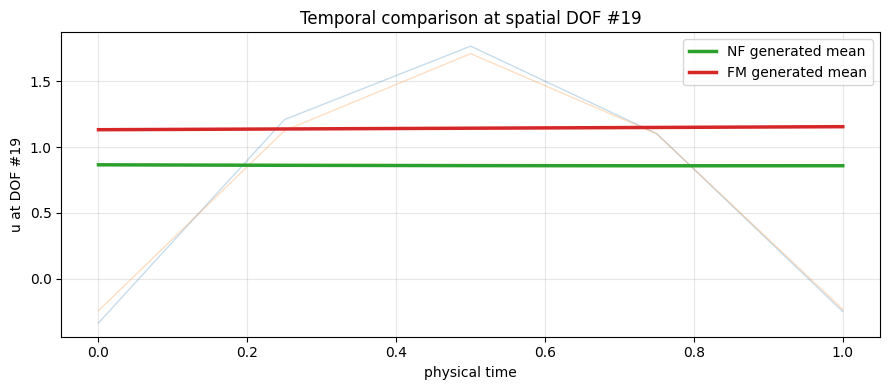

In [ ]:
fig, ax, probe = (
    plot_temporal_probe_comparison(
        times=times_fake,

        real_trajectories=
            real_query,

        generated_sets={
            "NF":
                nf_samples_plot,

            "FM":
                fm_samples_plot,
        },
    )
)

print(
    "Selected probe:",
    probe
)

plt.show()

In [ ]:
nf_evaluation
fm_evaluation

{'per_group': [{'group_id': 3,
   'mu': array([-0.43152993, -0.62728794,  0.91619883]),
   'n_real': 2,
   'n_generated': 7,
   'energy_distance_squared': 12.080487826356109,
   'timewise_energy_distance_squared': array([7.50175624, 2.36648228, 1.42704516, 2.44495523, 7.62774943]),
   'nearest_neighbor': {'mean': 0.835051069509822,
    'median': 0.835051069509822,
    'min': 0.8310568344251662,
    'max': 0.8390453045944778,
    'per_trajectory': array([0.83105683, 0.8390453 ])}},
  {'group_id': 9,
   'mu': array([-1.08694708, -0.82514381,  0.5239045 ]),
   'n_real': 2,
   'n_generated': 7,
   'energy_distance_squared': 14.807668347340941,
   'timewise_energy_distance_squared': array([10.21468699,  3.10435815,  1.57126637,  3.03950875, 10.24241157]),
   'nearest_neighbor': {'mean': 0.9307332841670548,
    'median': 0.9307332841670548,
    'min': 0.93052675406282,
    'max': 0.9309398142712895,
    'per_trajectory': array([0.93052675, 0.93093981])}}],
 'summary': {'n_groups': 2,
  'ener

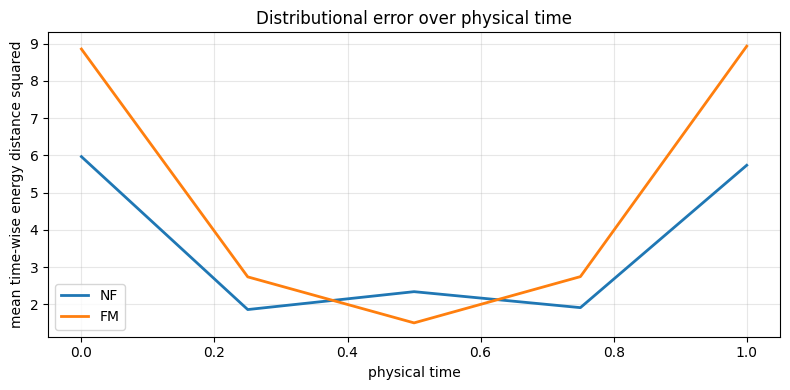

In [ ]:
fig, ax = (
    plot_timewise_energy_comparison(
        times=times_fake,

        evaluations={
            "NF":
                nf_evaluation,

            "FM":
                fm_evaluation,
        },
    )
)

plt.show()

In [ ]:
from spde_surrogates.problems import (
    randomized_advection_diffusion as rad
)

In [ ]:
np.random.seed(123)

mu_movie = np.array([
    1.0,
    -2.0,
    0.5,
])

permeability_movie = (
    rad.sample_permeability(3)
)

U_movie = rad.FOMsolver(
    mu=mu_movie,
    permeability=permeability_movie,
    dt=0.05,
    steps=3,
)

In [ ]:
print(U_movie.shape)

(4, 2763)


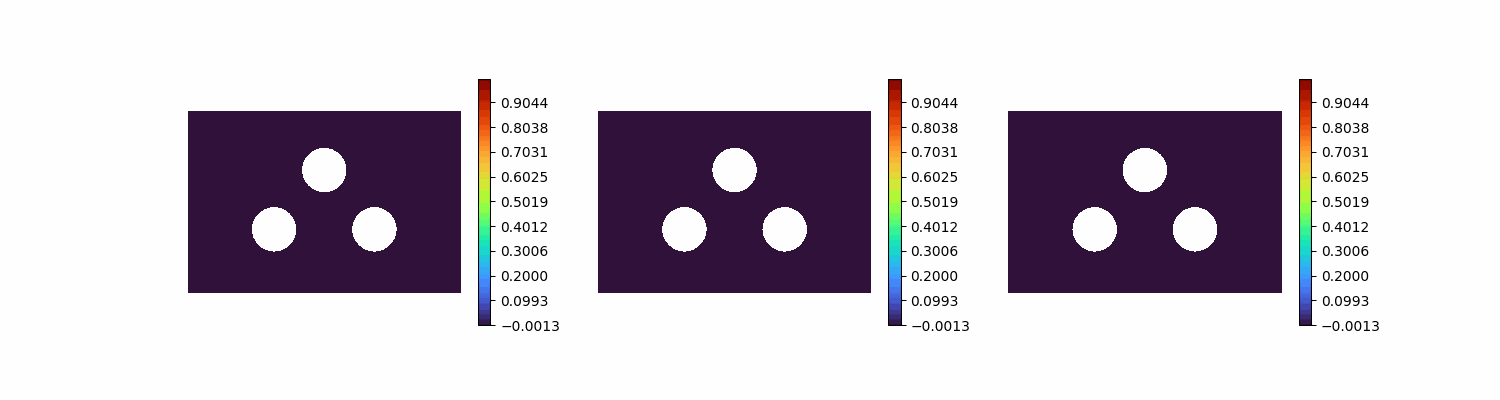

In [ ]:
rad.animate_trajectory_comparison(
    (
        U_movie,
        U_movie,
        U_movie,
    )
)

### Result and interpretation

The temporal probe plots, time-wise error curves, and FEniCS animations are generated correctly.

These tools complement the numerical metrics and provide an intuitive way to check whether a model that performs well statistically also produces physically plausible temporal behavior.


## 11. Checkpoint persistence

Because the experiments are run in Colab, model persistence is not optional. A valid checkpoint must contain enough information to reconstruct the full surrogate independently of the training runtime.

The checkpoint therefore stores the model weights and architecture together with the POD basis, normalizers, sampling configuration, training metadata, and other information needed for online generation.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.persistence.checkpoint import (
    save_static_surrogate,
    load_static_surrogate,
)

In [ ]:
print(nf_checkpoint)
print(save_static_surrogate)

/content/test_nf_surrogate.pt
<function save_static_surrogate at 0x7a5f53ed80e0>


In [ ]:
print(result.keys())

dict_keys(['n_samples', 'mean_seconds', 'median_seconds', 'std_seconds', 'seconds_per_sample', 'samples_per_second', 'all_times'])


In [ ]:
nf_model_config = {
    "n_layers": 4,
    "hidden_size": 64,
    "hidden_depth": 1,
}

nf_train_config = {
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-3,
    "weight_decay": 1e-5,
}

nf_checkpoint = "/content/test_nf_surrogate.pt"

save_static_surrogate(
    path=nf_checkpoint,
    surrogate=nf_surrogate,
    model_type="realnvp",
    model_config=nf_model_config,
    train_config=nf_train_config,
    metadata={
        "description": "Synthetic NF test"
    },
)

print(os.path.isfile(nf_checkpoint))

True


In [ ]:
import torch
import numpy as np

cond_np = nf_surrogate._build_conditions(
    mu_query,
    times_fake,
)

print(cond_np.shape)

(5, 4)


In [ ]:
cond_tensor = torch.tensor(
    cond_np,
    dtype=torch.float32,
    device=nf_surrogate.device,
)

In [ ]:
torch.manual_seed(123)

z_test = torch.randn(
    len(times_fake),
    nf_surrogate.model.dim_y,
    device=nf_surrogate.device,
)

print(z_test.shape)

torch.Size([5, 18])


In [ ]:
with torch.no_grad():

    output_before = (
        nf_surrogate.model.sample(
            cond_tensor,
            z=z_test,
        )
        .cpu()
        .numpy()
    )

print(output_before.shape)
print(np.isfinite(output_before).all())

(5, 18)
True


In [ ]:
nf_loaded, nf_info = load_static_surrogate(
    nf_checkpoint
)

In [ ]:
print("Model type:", nf_info["model_type"])
print("POD modes:", nf_loaded.pod.n_modes_)
print("Physical DOFs:", nf_loaded.pod.n_dofs_)
print("Sampling config:", nf_info["sampling_config"])

Model type: realnvp
POD modes: 18
Physical DOFs: 20
Sampling config: {}


In [ ]:
cond_loaded = torch.tensor(
    cond_np,
    dtype=torch.float32,
    device=nf_loaded.device,
)

In [ ]:
z_loaded = z_test.to(
    nf_loaded.device
)

In [ ]:
with torch.no_grad():

    output_after = (
        nf_loaded.model.sample(
            cond_loaded,
            z=z_loaded,
        )
        .cpu()
        .numpy()
    )

In [ ]:
print(
    "Same NF output:",
    np.allclose(
        output_before,
        output_after,
    )
)

print(
    "Maximum difference:",
    np.max(
        np.abs(
            output_before
            - output_after
        )
    )
)

Same NF output: True
Maximum difference: 0.0


In [ ]:
nf_loaded_samples = nf_loaded.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
    temporal_coupling="shared_noise",
)

print(
    "Loaded NF samples shape:",
    nf_loaded_samples.shape
)

print(
    "Loaded NF finite:",
    np.isfinite(
        nf_loaded_samples
    ).all()
)

Loaded NF samples shape: (3, 5, 20)
Loaded NF finite: True


In [ ]:
fm_model_config = {
    "hidden_dims": (64, 64),
}

fm_train_config = {
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-5,
}

In [ ]:
print(fm_surrogate.sampling_config)

{'n_steps': 20}


In [ ]:
fm_checkpoint = "/content/test_fm_surrogate.pt"

save_static_surrogate(
    path=fm_checkpoint,
    surrogate=fm_surrogate,
    model_type="flow_matching",
    model_config=fm_model_config,
    train_config=fm_train_config,
    metadata={
        "description": "Synthetic FM test"
    },
)

In [ ]:
import os

print(
    "FM checkpoint exists:",
    os.path.isfile(
        fm_checkpoint
    )
)

FM checkpoint exists: True


In [ ]:
cond_np_fm = fm_surrogate._build_conditions(
    mu_query,
    times_fake,
)

cond_fm = torch.tensor(
    cond_np_fm,
    dtype=torch.float32,
    device=fm_surrogate.device,
)

In [ ]:
torch.manual_seed(456)

z_fm = torch.randn(
    len(times_fake),
    fm_surrogate.model.dim_y,
    device=fm_surrogate.device,
)

In [ ]:
with torch.no_grad():

    fm_before = (
        fm_surrogate.model.sample(
            cond_fm,
            z=z_fm,
            **fm_surrogate.sampling_config,
        )
        .cpu()
        .numpy()
    )

print(fm_before.shape)
print(np.isfinite(fm_before).all())

(5, 18)
True


In [ ]:
fm_loaded, fm_info = load_static_surrogate(
    fm_checkpoint
)

In [ ]:
print("Model type:", fm_info["model_type"])
print("POD modes:", fm_loaded.pod.n_modes_)
print("Physical DOFs:", fm_loaded.pod.n_dofs_)
print("Sampling config:", fm_info["sampling_config"])

Model type: flow_matching
POD modes: 18
Physical DOFs: 20
Sampling config: {'n_steps': 20}


In [ ]:
cond_fm_loaded = torch.tensor(
    cond_np_fm,
    dtype=torch.float32,
    device=fm_loaded.device,
)

In [ ]:
with torch.no_grad():

    fm_after = (
        fm_loaded.model.sample(
            cond_fm_loaded,
            z=z_fm.to(
                fm_loaded.device
            ),
            **fm_loaded.sampling_config,
        )
        .cpu()
        .numpy()
    )

In [ ]:
print(
    "Same FM output:",
    np.allclose(
        fm_before,
        fm_after,
    )
)

print(
    "Maximum difference:",
    np.max(
        np.abs(
            fm_before
            - fm_after
        )
    )
)

Same FM output: True
Maximum difference: 0.0


In [ ]:
fm_loaded_samples = fm_loaded.sample(
    mu=mu_query,
    times=times_fake,
    n_samples=3,
    temporal_coupling="shared_noise",
)

print(
    "Loaded FM samples shape:",
    fm_loaded_samples.shape
)

print(
    "Loaded FM finite:",
    np.isfinite(
        fm_loaded_samples
    ).all()
)

Loaded FM samples shape: (3, 5, 20)
Loaded FM finite: True


### Result and interpretation

After saving and reloading the checkpoint, the model type, reduced dimension, physical dimension, and configuration are recovered correctly. When the same latent noise is supplied before and after reload, the generated output is identical within numerical precision.

This confirms that the saved checkpoint is a faithful representation of the trained surrogate and can be safely used for later evaluation or reporting.


## 12. YAML configuration and end-to-end runner

The final infrastructure check verifies that an entire experiment can be described through a YAML configuration and executed by the common runner. This is the intended long-term workflow: the notebooks should specify and inspect experiments, while the reusable implementation remains inside the package.

A few debugging cells are kept in this section because they document how an intermediate indentation problem in the runner was located and corrected.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q src.zip

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
import yaml

print(yaml.__version__)

6.0.3


In [ ]:
from spde_surrogates.config import (
    load_config,
)

In [ ]:
config = load_config(
    "/content/static_comparison_smoke.yaml"
)

In [ ]:
print(config.keys())

dict_keys(['experiment', 'data', 'split', 'pod', 'realnvp', 'flow_matching', 'evaluation', 'benchmark'])


In [ ]:
print(
    "Experiment:",
    config["experiment"]["name"]
)

print(
    "Number of mu:",
    config["data"]["n_mu"]
)

print(
    "Realizations per mu:",
    config["data"]["n_realizations"]
)

print(
    "NF epochs:",
    config["realnvp"]["training"]["epochs"]
)

print(
    "FM epochs:",
    config["flow_matching"]["training"]["epochs"]
)

print(
    "FM sampling steps:",
    config["flow_matching"]["sampling"]["n_steps"]
)

Experiment: static_comparison_smoke
Number of mu: 4
Realizations per mu: 2
NF epochs: 10
FM epochs: 10
FM sampling steps: 20


In [ ]:
print(
    config["split"]
)

{'train_fraction': 0.5, 'val_fraction': 0.25, 'test_fraction': 0.25, 'seed': 1}


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src"
    )

In [ ]:
from spde_surrogates.config import (
    load_config,
)

from spde_surrogates.experiments.static_comparison import (
    run_static_comparison,
)

In [ ]:
print(config.keys())

dict_keys(['experiment', 'problem', 'data', 'split', 'pod', 'realnvp', 'flow_matching', 'evaluation', 'benchmark'])


In [ ]:
!cat /content/static_comparison_smoke.yaml

experiment:
  name: static_comparison_smoke
  seed: 123
  output_dir: outputs/static_comparison_smoke

problem:
  module: spde_surrogates.problems.randomized_advection_diffusion

data:
  path: data/static_comparison_smoke.npz
  n_mu: 4
  n_realizations: 2
  nimp: 3
  dt: 0.05
  steps: 4

split:
  train_fraction: 0.5
  val_fraction: 0.25
  test_fraction: 0.25
  seed: 1

pod:
  target_error: 0.01
  max_modes: 100
  selection: trajectory_error
  energy_threshold: 0.999

realnvp:
  model:
    n_layers: 4
    hidden_size: 64
    hidden_depth: 1

  training:
    batch_size: 32
    epochs: 10
    lr: 0.001
    weight_decay: 0.00001

flow_matching:
  model:
    hidden_dims:
      - 64
      - 64

  training:
    batch_size: 32
    epochs: 10
    lr: 0.0001
    weight_decay: 0.00001

  sampling:
    n_steps: 20

evaluation:
  n_generated: 10
  temporal_coupling: shared_noise

benchmark:
  sample_sizes:
    - 1
    - 10
    - 50

  n_repeats: 3
  n_warmup: 1

In [ ]:
from spde_surrogates.config import load_config

config = load_config(
    "/content/static_comparison_smoke.yaml"
)

In [ ]:
print(config.keys())

dict_keys(['experiment', 'problem', 'data', 'split', 'pod', 'realnvp', 'flow_matching', 'evaluation', 'benchmark'])


In [ ]:
print(
    config["problem"]["module"]
)

print(
    config["experiment"]["output_dir"]
)

spde_surrogates.problems.randomized_advection_diffusion
outputs/static_comparison_smoke


In [ ]:
from importlib import import_module

problem_test = import_module(
    config["problem"]["module"]
)

print(problem_test.Vh.dim())
print(problem_test.Dh.dim())

2763
5234


In [ ]:
print(config["data"])

{'path': 'data/static_comparison_smoke.npz', 'n_mu': 4, 'n_realizations': 2, 'nimp': 3, 'dt': 0.05, 'steps': 4}


In [ ]:
print("n_mu:", config["data"]["n_mu"])
print("n_realizations:", config["data"]["n_realizations"])
print("steps:", config["data"]["steps"])

n_mu: 4
n_realizations: 2
steps: 4


In [ ]:
import sys
import importlib

module_name = (
    "spde_surrogates.experiments."
    "static_comparison"
)

if module_name in sys.modules:
    del sys.modules[module_name]

importlib.invalidate_caches()

from spde_surrogates.experiments.static_comparison import (
    run_static_comparison,
)

IndentationError: unindent does not match any outer indentation level (static_comparison.py, line 260)

In [ ]:
results_smoke = run_static_comparison(
    config=config,
    verbose=True,
)

NameError: name 'run_static_comparison' is not defined

In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/experiments/static_comparison.py

Sorry: IndentationError: unindent does not match any outer indentation level (static_comparison.py, line 260)

In [ ]:
from spde_surrogates.config import load_config

config = load_config(
    "/content/static_comparison_smoke.yaml"
)

print(config)

{'experiment': {'name': 'static_comparison_smoke', 'seed': 123, 'output_dir': 'outputs/static_comparison_smoke'}, 'problem': {'module': 'spde_surrogates.problems.randomized_advection_diffusion'}, 'data': {'path': 'data/static_comparison_smoke.npz', 'n_mu': 4, 'n_realizations': 2, 'nimp': 3, 'dt': 0.05, 'steps': 4}, 'split': {'train_fraction': 0.5, 'val_fraction': 0.25, 'test_fraction': 0.25, 'seed': 1}, 'pod': {'target_error': 0.01, 'max_modes': 100, 'selection': 'trajectory_error', 'energy_threshold': 0.999}, 'realnvp': {'model': {'n_layers': 4, 'hidden_size': 64, 'hidden_depth': 1}, 'training': {'batch_size': 32, 'epochs': 10, 'lr': 0.001, 'weight_decay': 1e-05}}, 'flow_matching': {'model': {'hidden_dims': [64, 64]}, 'training': {'batch_size': 32, 'epochs': 10, 'lr': 0.0001, 'weight_decay': 1e-05}, 'sampling': {'n_steps': 20}}, 'evaluation': {'n_generated': 10, 'temporal_coupling': 'shared_noise'}, 'benchmark': {'sample_sizes': [1, 10, 50], 'n_repeats': 3, 'n_warmup': 1}}


In [ ]:
print(config["experiment"]["name"])
print(config["problem"]["module"])
print(config["data"]["n_mu"])
print(config["data"]["n_realizations"])
print(config["data"]["steps"])

static_comparison_smoke
spde_surrogates.problems.randomized_advection_diffusion
4
2
4


In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/experiments/static_comparison.py

In [ ]:
import sys
import importlib

module_name = "spde_surrogates.experiments.static_comparison"

if module_name in sys.modules:
    del sys.modules[module_name]

importlib.invalidate_caches()

from spde_surrogates.experiments.static_comparison import (
    run_static_comparison,
)

print("Import OK")

Import OK


In [ ]:
results_smoke = run_static_comparison(
    config=config,
    verbose=True,
)

Experiment: static_comparison_smoke

[1/9] Loading physical problem...
Problem module: spde_surrogates.problems.randomized_advection_diffusion

[2/9] Loading or generating FOM dataset...
Loading existing dataset from: data/static_comparison_smoke.npz
mu_bank shape: (4, 3)
times shape: (5,)
trajectories shape: (8, 5, 2763)
group_ids shape: (8,)

[3/9] Preparing common POD representation...
Selected POD modes: 4
Training static samples: 20
Validation static samples: 10
Test static samples: 10

[4/9] Training RealNVP...
epoch    1/10 - train NLL=5.8303 - val NLL=5.5187
epoch    2/10 - train NLL=5.7140 - val NLL=5.4183
epoch    3/10 - train NLL=5.6087 - val NLL=5.3250
epoch    4/10 - train NLL=5.5121 - val NLL=5.2373
epoch    5/10 - train NLL=5.4220 - val NLL=5.1539
epoch    6/10 - train NLL=5.3369 - val NLL=5.0740
epoch    7/10 - train NLL=5.2554 - val NLL=4.9969
epoch    8/10 - train NLL=5.1768 - val NLL=4.9222
epoch    9/10 - train NLL=5.1003 - val NLL=4.8495
epoch   10/10 - train NLL=5

### Result and interpretation

After the runner fix, the smoke experiment completes the entire sequence from dataset preparation to POD, model training, evaluation, benchmarking, and checkpoint creation.

At this point the refactored infrastructure is considered operational, and the project can move from software validation to experiments on the physically meaningful datasets.


In [ ]:
print(
    "Dataset shape:",
    results_smoke["trajectories"].shape
)

print(
    "Times shape:",
    results_smoke["times"].shape
)

print(
    "POD modes:",
    results_smoke["prepared"]["pod"].n_modes_
)

Dataset shape: (8, 5, 2763)
Times shape: (5,)
POD modes: 4


In [ ]:
import numpy as np

nf_energy = results_smoke[
    "nf_evaluation"
]["summary"]["energy_mean"]

fm_energy = results_smoke[
    "fm_evaluation"
]["summary"]["energy_mean"]

print("NF energy:", nf_energy)
print("FM energy:", fm_energy)

print("NF finite:", np.isfinite(nf_energy))
print("FM finite:", np.isfinite(fm_energy))

NF energy: 4.707620047220548
FM energy: 5.245781035431126
NF finite: True
FM finite: True


In [ ]:
import os

print(
    "NF checkpoint:",
    os.path.isfile(
        results_smoke["nf_checkpoint"]
    )
)

print(
    "FM checkpoint:",
    os.path.isfile(
        results_smoke["fm_checkpoint"]
    )
)

NF checkpoint: True
FM checkpoint: True


In [ ]:
print(results_smoke["benchmark"].keys())

for model_name in ["NF", "FM"]:
    print("\n", model_name)

    for row in results_smoke["benchmark"][model_name]:
        print(
            "N =",
            row["n_samples"],
            "| median =",
            row["median_seconds"],
            "| samples/s =",
            row["samples_per_second"],
        )

dict_keys(['NF', 'FM'])

 NF
N = 1 | median = 0.0029396319987426978 | samples/s = 340.17863475010046
N = 10 | median = 0.006561468999279896 | samples/s = 1524.048959325644
N = 50 | median = 0.006817670999225811 | samples/s = 7333.882788664606

 FM
N = 1 | median = 0.010371935000875965 | samples/s = 96.41402495441253
N = 10 | median = 0.011933379999391036 | samples/s = 837.9855498199423
N = 50 | median = 0.028858086001491756 | samples/s = 1732.6166398358976


In [ ]:
results_smoke_2 = run_static_comparison(
    config=config,
    verbose=True,
)

Experiment: static_comparison_smoke

[1/9] Loading physical problem...
Problem module: spde_surrogates.problems.randomized_advection_diffusion

[2/9] Loading or generating FOM dataset...
Loading existing dataset from: data/static_comparison_smoke.npz
mu_bank shape: (4, 3)
times shape: (5,)
trajectories shape: (8, 5, 2763)
group_ids shape: (8,)

[3/9] Preparing common POD representation...
Selected POD modes: 4
Training static samples: 20
Validation static samples: 10
Test static samples: 10

[4/9] Training RealNVP...
epoch    1/10 - train NLL=5.8303 - val NLL=5.5187
epoch    2/10 - train NLL=5.7140 - val NLL=5.4183
epoch    3/10 - train NLL=5.6087 - val NLL=5.3250
epoch    4/10 - train NLL=5.5121 - val NLL=5.2373
epoch    5/10 - train NLL=5.4220 - val NLL=5.1539
epoch    6/10 - train NLL=5.3369 - val NLL=5.0740
epoch    7/10 - train NLL=5.2554 - val NLL=4.9969
epoch    8/10 - train NLL=5.1768 - val NLL=4.9222
epoch    9/10 - train NLL=5.1003 - val NLL=4.8495
epoch   10/10 - train NLL=5

# Part II — Pilot experiment `20 × 10`

## 13. Full Order Model timing

Before generating the pilot dataset, the computational cost of one complete FOM trajectory is measured. A trajectory contains 101 time instants and 2763 spatial degrees of freedom.

The observed runtime is about **20.95 seconds per trajectory**. This value is used to estimate the cost of dataset generation and motivates the need for generative surrogates: once trained, the surrogate should be able to produce many stochastic trajectories at a fraction of the cost of repeatedly solving the FOM.


In [ ]:
from spde_surrogates.problems import (
    randomized_advection_diffusion as rad
)

import numpy as np
import time

In [ ]:
print("Vh:", rad.Vh.dim())
print("Dh:", rad.Dh.dim())

Vh: 2763
Dh: 5234


In [ ]:
FULL_DT = 0.05
FULL_STEPS = 100
FULL_NIMP = 3
SEED = 123

In [ ]:
np.random.seed(SEED)

mu_benchmark = rad.sample_mu()

permeability_benchmark = (
    rad.sample_permeability(
        FULL_NIMP
    )
)

print("mu:", mu_benchmark)
print(
    "permeability shape:",
    permeability_benchmark.shape
)

mu: [ 2.35763023 -2.56632798 -3.27778256]
permeability shape: (5234,)


In [ ]:
_ = rad.FOMsolver(
    mu=mu_benchmark,
    permeability=permeability_benchmark,
    dt=FULL_DT,
    steps=2,
)

print("Warm-up completed")

Warm-up completed


In [ ]:
start = time.perf_counter()

U_full = rad.FOMsolver(
    mu=mu_benchmark,
    permeability=permeability_benchmark,
    dt=FULL_DT,
    steps=FULL_STEPS,
)

elapsed = (
    time.perf_counter()
    - start
)

print(
    "Trajectory shape:",
    U_full.shape
)

print(
    "Elapsed seconds:",
    elapsed
)

print(
    "Elapsed minutes:",
    elapsed / 60.0
)

Trajectory shape: (101, 2763)
Elapsed seconds: 20.947849757998483
Elapsed minutes: 0.34913082929997474


### Result and interpretation

A single full trajectory takes approximately **20.95 s**. Even a moderate dataset therefore requires a non-negligible amount of computational time.

This timing becomes the practical reference against which the online generation cost of RealNVP and Flow Matching can later be interpreted.


In [ ]:
bytes_per_trajectory = (
    U_full.nbytes
)

print(
    "One trajectory MiB:",
    bytes_per_trajectory
    / 1024**2
)

for n in [
    50,
    100,
    200,
    400,
]:

    size_gib = (
        bytes_per_trajectory
        * n
        / 1024**3
    )

    print(
        n,
        "trajectories ->",
        size_gib,
        "GiB raw"
    )

One trajectory MiB: 2.1290817260742188
50 trajectories -> 0.10395906865596771 GiB raw
100 trajectories -> 0.20791813731193542 GiB raw
200 trajectories -> 0.41583627462387085 GiB raw
400 trajectories -> 0.8316725492477417 GiB raw


## 14. Pilot dataset construction and backup

The pilot dataset is designed to balance two requirements: coverage of the conditioning space and multiple stochastic realizations for each conditioning parameter. The selected configuration is

\[
20\ \mu \times 10\ \omega = 200\ \text{trajectories}.
\]

This is substantially more informative for learning a conditional distribution than either using many `μ` values with only one realization each or using many realizations at a single fixed `μ`.

After generation, the dataset is validated and copied to Google Drive. A SHA-256 comparison is used to verify that the persistent backup is identical to the local copy.


In [ ]:
from spde_surrogates.config import load_config

pilot_config = load_config(
    "/content/static_comparison_pilot.yaml"
)

print(pilot_config["data"])

{'path': 'data/static_comparison_pilot_20x10.npz', 'n_mu': 20, 'n_realizations': 10, 'nimp': 3, 'dt': 0.05, 'steps': 100}


In [ ]:
print("n_mu:", pilot_config["data"]["n_mu"])
print(
    "n_realizations:",
    pilot_config["data"]["n_realizations"]
)
print("dt:", pilot_config["data"]["dt"])
print("steps:", pilot_config["data"]["steps"])

n_mu: 20
n_realizations: 10
dt: 0.05
steps: 100


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

drive_data_dir = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/data"
)

drive_data_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(drive_data_dir)

/content/drive/MyDrive/Tesi/generative-spde-surrogates/data


In [ ]:
local_dataset_path = Path(
    "/content/data/"
    "static_comparison_pilot_20x10.npz"
)

drive_dataset_path = (
    drive_data_dir
    / "static_comparison_pilot_20x10.npz"
)

local_dataset_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

print("Local:")
print(local_dataset_path)

print("\nDrive:")
print(drive_dataset_path)

Local:
/content/data/static_comparison_pilot_20x10.npz

Drive:
/content/drive/MyDrive/Tesi/generative-spde-surrogates/data/static_comparison_pilot_20x10.npz


In [ ]:
print(
    "Local exists:",
    local_dataset_path.exists()
)

print(
    "Drive exists:",
    drive_dataset_path.exists()
)

Local exists: False
Drive exists: False


In [ ]:
from spde_surrogates.data.dataset import (
    get_fom_dataset,
)

from spde_surrogates.problems import (
    randomized_advection_diffusion as rad
)

import time
import numpy as np

In [ ]:
data_config = pilot_config["data"]
seed = pilot_config["experiment"]["seed"]

print(
    "Trajectories to generate:",
    data_config["n_mu"]
    * data_config["n_realizations"]
)

Trajectories to generate: 200


In [ ]:
start = time.perf_counter()

(
    mu_bank,
    times,
    mus,
    trajectories,
    group_ids,
) = get_fom_dataset(
    path=local_dataset_path,
    problem=rad,
    n_mu=int(
        data_config["n_mu"]
    ),
    n_realizations=int(
        data_config["n_realizations"]
    ),
    nimp=int(
        data_config["nimp"]
    ),
    dt=float(
        data_config["dt"]
    ),
    steps=int(
        data_config["steps"]
    ),
    seed=int(seed),
)

elapsed_dataset = (
    time.perf_counter()
    - start
)

print("\nGeneration/load completed.")
print(
    "Elapsed minutes:",
    elapsed_dataset / 60
)
print(
    "Elapsed hours:",
    elapsed_dataset / 3600
)

Dataset not found. Generating: /content/data/static_comparison_pilot_20x10.npz
mu   1/20, realizzazione  1/10, U.shape=(101, 2763)
mu   1/20, realizzazione  2/10, U.shape=(101, 2763)
mu   1/20, realizzazione  3/10, U.shape=(101, 2763)
mu   1/20, realizzazione  4/10, U.shape=(101, 2763)
mu   1/20, realizzazione  5/10, U.shape=(101, 2763)
mu   1/20, realizzazione  6/10, U.shape=(101, 2763)
mu   1/20, realizzazione  7/10, U.shape=(101, 2763)
mu   1/20, realizzazione  8/10, U.shape=(101, 2763)
mu   1/20, realizzazione  9/10, U.shape=(101, 2763)
mu   1/20, realizzazione 10/10, U.shape=(101, 2763)
mu   2/20, realizzazione  1/10, U.shape=(101, 2763)
mu   2/20, realizzazione  2/10, U.shape=(101, 2763)
mu   2/20, realizzazione  3/10, U.shape=(101, 2763)
mu   2/20, realizzazione  4/10, U.shape=(101, 2763)
mu   2/20, realizzazione  5/10, U.shape=(101, 2763)
mu   2/20, realizzazione  6/10, U.shape=(101, 2763)
mu   2/20, realizzazione  7/10, U.shape=(101, 2763)
mu   2/20, realizzazione  8/10, U.sha

In [ ]:
print("mu_bank:", mu_bank.shape)
print("times:", times.shape)
print("mus:", mus.shape)
print("trajectories:", trajectories.shape)
print("group_ids:", group_ids.shape)

mu_bank: (20, 3)
times: (101,)
mus: (200, 3)
trajectories: (200, 101, 2763)
group_ids: (200,)


In [ ]:
print(
    "All trajectories finite:",
    np.isfinite(
        trajectories
    ).all()
)

print(
    "Number of unique mu groups:",
    len(
        np.unique(group_ids)
    )
)

All trajectories finite: True
Number of unique mu groups: 20


In [ ]:
unique_groups, counts = np.unique(
    group_ids,
    return_counts=True,
)

print(
    "Realizations per group:",
    counts
)

print(
    "All groups have 10 realizations:",
    np.all(counts == 10)
)

Realizations per group: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]
All groups have 10 realizations: True


In [ ]:
print(
    "Dataset saved locally:",
    local_dataset_path.is_file()
)

print(
    "Size GiB:",
    local_dataset_path.stat().st_size
    / 1024**3
)

Dataset saved locally: True
Size GiB: 0.3939973870292306


In [ ]:
import shutil

shutil.copy2(
    local_dataset_path,
    drive_dataset_path,
)

print(
    "Drive backup exists:",
    drive_dataset_path.is_file()
)

Drive backup exists: True


In [ ]:
print(
    "Local bytes:",
    local_dataset_path.stat().st_size
)

print(
    "Drive bytes:",
    drive_dataset_path.stat().st_size
)

print(
    "Same size:",
    local_dataset_path.stat().st_size
    ==
    drive_dataset_path.stat().st_size
)

Local bytes: 423051473
Drive bytes: 423051473
Same size: True


In [ ]:
import hashlib


def sha256_file(path):
    sha = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()

In [ ]:
local_hash = sha256_file(
    local_dataset_path
)

drive_hash = sha256_file(
    drive_dataset_path
)

print("Local SHA256:")
print(local_hash)

print("\nDrive SHA256:")
print(drive_hash)

print(
    "\nIdentical files:",
    local_hash == drive_hash
)

Local SHA256:
3bfdd05945cbd79c83a268860935da8e908038d4b30cb97b5fc430c212e89d35

Drive SHA256:
3bfdd05945cbd79c83a268860935da8e908038d4b30cb97b5fc430c212e89d35

Identical files: True


### Result and interpretation

The pilot dataset contains 20 distinct parameter configurations, 10 stochastic realizations per parameter, and 200 trajectories of shape `(101, 2763)`. All values are finite.

The local file and the Google Drive backup have matching size and SHA-256 hash. This means that the expensive dataset generation is safely preserved and does not need to be repeated if the Colab runtime is reset.


## 15. Pilot split and POD

The dataset is split by parameter group before fitting the reduced basis. With the `70/15/15` split, the pilot contains 14 training parameters, 3 validation parameters, and 3 test parameters, corresponding to 140, 30, and 30 trajectories respectively.

The POD basis is fitted only on the training trajectories. Validation and test data are projected onto this fixed basis, which allows the reconstruction errors to measure genuine generalization to unseen parameter configurations.


In [ ]:
from pathlib import Path
import shutil

drive_dataset_path = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/data/"
    "static_comparison_pilot_20x10.npz"
)

local_dataset_path = Path(
    "/content/data/"
    "static_comparison_pilot_20x10.npz"
)

local_dataset_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    drive_dataset_path,
    local_dataset_path,
)

PosixPath('/content/data/static_comparison_pilot_20x10.npz')

In [ ]:
from spde_surrogates.config import load_config

pilot_config = load_config(
    "/content/static_comparison_pilot.yaml"
)

In [ ]:
print(pilot_config["split"])
print(pilot_config["pod"])

{'train_fraction': 0.7, 'val_fraction': 0.15, 'test_fraction': 0.15, 'seed': 1}
{'target_error': 0.01, 'max_modes': 100, 'selection': 'trajectory_error', 'energy_threshold': 0.999}


In [ ]:
print(trajectories.shape)
print(mus.shape)
print(times.shape)
print(group_ids.shape)

(200, 101, 2763)
(200, 3)
(101,)
(200,)


In [ ]:
from spde_surrogates.pipelines.static_realnvp import (
    prepare_static_data,
)

import time
import numpy as np

In [ ]:
start = time.perf_counter()

prepared_pilot = prepare_static_data(
    trajectories=trajectories,
    conds=mus,
    times=times,
    group_ids=group_ids,
    split_config=pilot_config["split"],
    pod_config=pilot_config["pod"],
)

pod_elapsed = (
    time.perf_counter()
    - start
)

print(
    "Preparation elapsed minutes:",
    pod_elapsed / 60
)

Preparation elapsed minutes: 3.895399829433336


In [ ]:
print(
    prepared_pilot.keys()
)

dict_keys(['split', 'pod', 'condition_normalizer', 'coefficient_normalizer', 'trajectories_train', 'trajectories_val', 'trajectories_test', 'mus_train', 'mus_val', 'mus_test', 'coeff_train', 'coeff_val', 'coeff_test', 'X_train', 'X_val', 'X_test', 'Y_train', 'Y_val', 'Y_test', 'X_train_norm', 'X_val_norm', 'X_test_norm', 'Y_train_norm', 'Y_val_norm', 'Y_test_norm'])


In [ ]:
split = prepared_pilot["split"]

print(
    "Train groups:",
    split["train_groups"]
)

print(
    "Validation groups:",
    split["val_groups"]
)

print(
    "Test groups:",
    split["test_groups"]
)

Train groups: [ 1 10 18 16  7 11 12 17 15  2  3  4  5  8]
Validation groups: [ 0  9 14]
Test groups: [13  6 19]


In [ ]:
print(
    "Number train mu:",
    len(split["train_groups"])
)

print(
    "Number validation mu:",
    len(split["val_groups"])
)

print(
    "Number test mu:",
    len(split["test_groups"])
)

Number train mu: 14
Number validation mu: 3
Number test mu: 3


In [ ]:
print(
    "Train trajectories:",
    len(split["train_indices"])
)

print(
    "Validation trajectories:",
    len(split["val_indices"])
)

print(
    "Test trajectories:",
    len(split["test_indices"])
)

Train trajectories: 140
Validation trajectories: 30
Test trajectories: 30


In [ ]:
train_groups = set(
    split["train_groups"]
)

val_groups = set(
    split["val_groups"]
)

test_groups = set(
    split["test_groups"]
)

print(
    "Train/val overlap:",
    train_groups & val_groups
)

print(
    "Train/test overlap:",
    train_groups & test_groups
)

print(
    "Val/test overlap:",
    val_groups & test_groups
)

Train/val overlap: set()
Train/test overlap: set()
Val/test overlap: set()


In [ ]:
pod = prepared_pilot["pod"]

print(
    "Selected POD modes:",
    pod.n_modes_
)

print(
    "Full dimension:",
    pod.n_dofs_
)

print(
    "Reduced fraction:",
    pod.n_modes_
    / pod.n_dofs_
)

print(
    "Compression factor:",
    pod.n_dofs_
    / pod.n_modes_
)

Selected POD modes: 76
Full dimension: 2763
Reduced fraction: 0.027506333695258775
Compression factor: 36.35526315789474


In [ ]:
train_pod_metrics = pod.reconstruction_metrics(
    prepared_pilot[
        "trajectories_train"
    ]
)

print(train_pod_metrics)

{'absolute_error': 16.863014956013675, 'relative_error': 0.010649403444117814, 'trajectory_relative_error': 0.00992709248897171, 'timewise_relative_error': array([       nan, 0.02842622, 0.03380058, 0.02206685, 0.02031924,
       0.02100245, 0.01837389, 0.0161539 , 0.01598559, 0.01641264,
       0.01628302, 0.01559194, 0.01474232, 0.01403234, 0.01352852,
       0.01316257, 0.01285809, 0.01258359, 0.01234318, 0.01214986,
       0.01200741, 0.01190585, 0.01182588, 0.0117461 , 0.01164893,
       0.01152384, 0.01136815, 0.01118609, 0.01098676, 0.01078166,
       0.01058234, 0.01039839, 0.01023625, 0.01009888, 0.00998602,
       0.00989506, 0.009822  , 0.00976231, 0.00971166, 0.00966624,
       0.00962304, 0.00957983, 0.00953514, 0.00948823, 0.00943898,
       0.00938781, 0.00933558, 0.00928345, 0.00923276, 0.00918488,
       0.00914107, 0.00910237, 0.0090695 , 0.00904284, 0.0090224 ,
       0.00900791, 0.00899884, 0.00899453, 0.00899422, 0.00899718,
       0.00900273, 0.00901032, 0.0090195

In [ ]:
print(
    "TRAIN relative Frobenius:",
    train_pod_metrics[
        "relative_error"
    ]
)

print(
    "TRAIN trajectory relative:",
    train_pod_metrics[
        "trajectory_relative_error"
    ]
)

print(
    "TRAIN cumulative energy:",
    train_pod_metrics[
        "cumulative_energy"
    ]
)

TRAIN relative Frobenius: 0.010649403444117814
TRAIN trajectory relative: 0.00992709248897171
TRAIN cumulative energy: 0.9996153090270931


In [ ]:
val_pod_metrics = pod.reconstruction_metrics(
    prepared_pilot[
        "trajectories_val"
    ]
)

print(
    "VAL relative Frobenius:",
    val_pod_metrics[
        "relative_error"
    ]
)

print(
    "VAL trajectory relative:",
    val_pod_metrics[
        "trajectory_relative_error"
    ]
)

VAL relative Frobenius: 0.01629077186776898
VAL trajectory relative: 0.013693522996589767


In [ ]:
test_pod_metrics = pod.reconstruction_metrics(
    prepared_pilot[
        "trajectories_test"
    ]
)

print(
    "TEST relative Frobenius:",
    test_pod_metrics[
        "relative_error"
    ]
)

print(
    "TEST trajectory relative:",
    test_pod_metrics[
        "trajectory_relative_error"
    ]
)

TEST relative Frobenius: 0.014760556135555202
TEST trajectory relative: 0.012708079693239414


In [ ]:
print(
    "TRAIN:",
    train_pod_metrics[
        "trajectory_relative_error"
    ]
)

print(
    "VAL:",
    val_pod_metrics[
        "trajectory_relative_error"
    ]
)

print(
    "TEST:",
    test_pod_metrics[
        "trajectory_relative_error"
    ]
)

TRAIN: 0.00992709248897171
VAL: 0.013693522996589767
TEST: 0.012708079693239414


In [ ]:
test_timewise = test_pod_metrics[
    "timewise_relative_error"
]

In [ ]:
print(
    test_timewise.shape
)

print(
    test_timewise[:10]
)

(101,)
[       nan 0.02822064 0.03317702 0.02105562 0.02013712 0.02183363
 0.02020629 0.01902274 0.01962832 0.02060791]


In [ ]:
print(
    "Number of finite times:",
    np.isfinite(
        test_timewise
    ).sum()
)

print(
    "Number of NaN times:",
    np.isnan(
        test_timewise
    ).sum()
)

Number of finite times: 100
Number of NaN times: 1


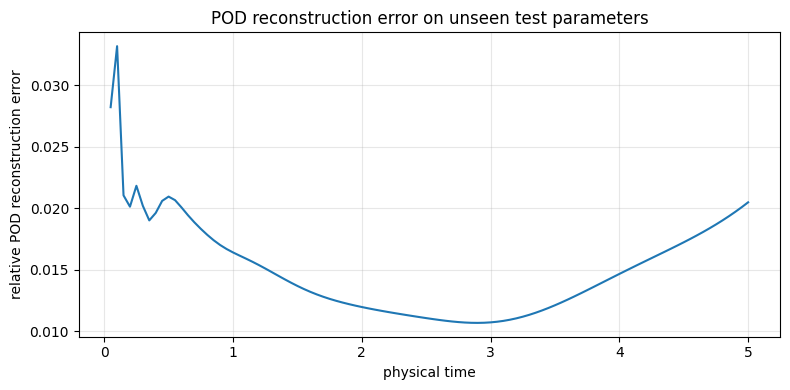

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 4)
)

plt.plot(
    times,
    test_timewise,
)

plt.xlabel(
    "physical time"
)

plt.ylabel(
    "relative POD reconstruction error"
)

plt.title(
    "POD reconstruction error on unseen test parameters"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()

plt.show()

In [ ]:
print(
    "Condition normalizer mean shape:",
    prepared_pilot[
        "condition_normalizer"
    ].mean_.shape
)

print(
    "Coefficient normalizer mean shape:",
    prepared_pilot[
        "coefficient_normalizer"
    ].mean_.shape
)

Condition normalizer mean shape: (1, 4)
Coefficient normalizer mean shape: (1, 76)


### Result and interpretation

The POD selects **76 modes** out of 2763 physical degrees of freedom, corresponding to a compression factor of approximately **36.4×**.

The trajectory-relative reconstruction errors are about **0.99% on training**, **1.37% on validation**, and **1.27% on test**. The validation and test errors remain close to the training error, which indicates that the reduced basis generalizes well to unseen parameters and is not merely memorizing the training trajectories.

A `NaN` that appears at the initial time in the relative time-wise error is expected because the initial state has zero or nearly zero norm, making a relative normalization ill-defined at that instant.


## 16. Generator preflight and training diagnosis

Before launching the definitive training runs, both models are tested with short runs using the intended architectures. This reveals an important difference in optimization behavior.

With a learning rate of `1e-3`, RealNVP quickly improves its training likelihood but its validation NLL deteriorates dramatically after the first few epochs. Flow Matching, trained with `1e-4`, behaves much more smoothly. Additional checks on the normalized POD coefficients and on the parameter ranges do not reveal a sufficiently severe distribution shift to explain the RealNVP behavior.

The working hypothesis is therefore that the RealNVP training setup is too aggressive rather than that the POD or dataset split is fundamentally incorrect.

> The RealNVP NLL and the Flow Matching MSE are different objectives and must never be compared numerically as if they were on the same scale.


In [ ]:
from spde_surrogates.pipelines.static_realnvp import (
    train_static_realnvp,
)

import numpy as np
import time

In [ ]:
nf_preflight_train_config = {
    "batch_size": 128,
    "epochs": 10,
    "lr": 0.001,
    "weight_decay": 0.00001,
}

nf_preflight_model_config = {
    "n_layers": 8,
    "hidden_size": 128,
    "hidden_depth": 2,
}

In [ ]:
start = time.perf_counter()

nf_preflight = train_static_realnvp(
    prepared_data=prepared_pilot,
    model_config=nf_preflight_model_config,
    train_config=nf_preflight_train_config,
    verbose=True,
)

nf_preflight_time = time.perf_counter() - start

print(
    "NF preflight minutes:",
    nf_preflight_time / 60
)

epoch    1/10 - train NLL=89.3976 - val NLL=83.7332
epoch    2/10 - train NLL=56.7186 - val NLL=76.1068
epoch    3/10 - train NLL=35.4716 - val NLL=130.9800
epoch    4/10 - train NLL=19.6206 - val NLL=190.4537
epoch    5/10 - train NLL=7.1301 - val NLL=424.4809
epoch    6/10 - train NLL=-2.9213 - val NLL=683.9629
epoch    7/10 - train NLL=-11.1160 - val NLL=887.6739
epoch    8/10 - train NLL=-18.2190 - val NLL=1061.0129
epoch    9/10 - train NLL=-23.6063 - val NLL=1189.0496
epoch   10/10 - train NLL=-28.8014 - val NLL=1456.7286
NF preflight minutes: 0.6890312406666756


In [ ]:
print(
    "Train history length:",
    len(nf_preflight["train_history"])
)

print(
    "Val history length:",
    len(nf_preflight["val_history"])
)

print(
    "Train finite:",
    np.isfinite(
        nf_preflight["train_history"]
    ).all()
)

print(
    "Val finite:",
    np.isfinite(
        nf_preflight["val_history"]
    ).all()
)

print(
    "Final train loss:",
    nf_preflight["train_history"][-1]
)

print(
    "Final val loss:",
    nf_preflight["val_history"][-1]
)

Train history length: 10
Val history length: 10
Train finite: True
Val finite: True
Final train loss: -28.801398131224484
Final val loss: 1456.7286014556885


In [ ]:
from spde_surrogates.pipelines.static_flow_matching import (
    train_static_flow_matching,
)

In [ ]:
fm_preflight_model_config = {
    "hidden_dims": [
        256,
        256,
        256,
    ],
}

fm_preflight_train_config = {
    "batch_size": 128,
    "epochs": 10,
    "lr": 0.0001,
    "weight_decay": 0.00001,
}

fm_preflight_sampling_config = {
    "n_steps": 100,
}

In [ ]:
start = time.perf_counter()

fm_preflight = train_static_flow_matching(
    prepared_data=prepared_pilot,
    model_config=fm_preflight_model_config,
    train_config=fm_preflight_train_config,
    sampling_config=fm_preflight_sampling_config,
    verbose=True,
)

fm_preflight_time = time.perf_counter() - start

print(
    "FM preflight minutes:",
    fm_preflight_time / 60
)

epoch    1/10 - train FM loss=2.0001e+00 - val FM loss=2.3463e+00
epoch    2/10 - train FM loss=1.9939e+00 - val FM loss=2.3420e+00
epoch    3/10 - train FM loss=1.9804e+00 - val FM loss=2.3177e+00
epoch    4/10 - train FM loss=1.9624e+00 - val FM loss=2.2958e+00
epoch    5/10 - train FM loss=1.9501e+00 - val FM loss=2.2944e+00
epoch    6/10 - train FM loss=1.9319e+00 - val FM loss=2.2927e+00
epoch    7/10 - train FM loss=1.9219e+00 - val FM loss=2.2753e+00
epoch    8/10 - train FM loss=1.9011e+00 - val FM loss=2.2453e+00
epoch    9/10 - train FM loss=1.8820e+00 - val FM loss=2.2428e+00
epoch   10/10 - train FM loss=1.8533e+00 - val FM loss=2.1931e+00
FM preflight minutes: 0.18882719580002838


In [ ]:
print(
    "Train history length:",
    len(fm_preflight["train_history"])
)

print(
    "Val history length:",
    len(fm_preflight["val_history"])
)

print(
    "Train finite:",
    np.isfinite(
        fm_preflight["train_history"]
    ).all()
)

print(
    "Val finite:",
    np.isfinite(
        fm_preflight["val_history"]
    ).all()
)

print(
    "Final train loss:",
    fm_preflight["train_history"][-1]
)

print(
    "Final val loss:",
    fm_preflight["val_history"][-1]
)

Train history length: 10
Val history length: 10
Train finite: True
Val finite: True
Final train loss: 1.853318620372463
Final val loss: 2.19306289156278


In [ ]:
print(
    "Estimated NF 300 epochs:",
    nf_preflight_time * 30 / 60,
    "minutes"
)

print(
    "Estimated FM 300 epochs:",
    fm_preflight_time * 30 / 60,
    "minutes"
)

Estimated NF 300 epochs: 20.67093722000027 minutes
Estimated FM 300 epochs: 5.664815874000851 minutes


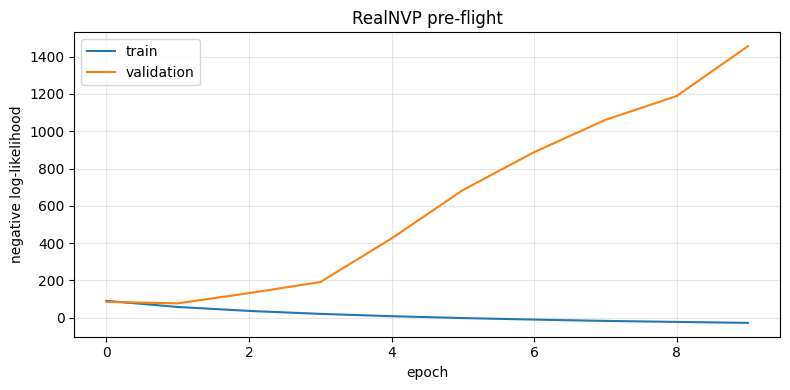

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(
    nf_preflight["train_history"],
    label="train",
)

plt.plot(
    nf_preflight["val_history"],
    label="validation",
)

plt.xlabel("epoch")
plt.ylabel("negative log-likelihood")
plt.title("RealNVP pre-flight")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

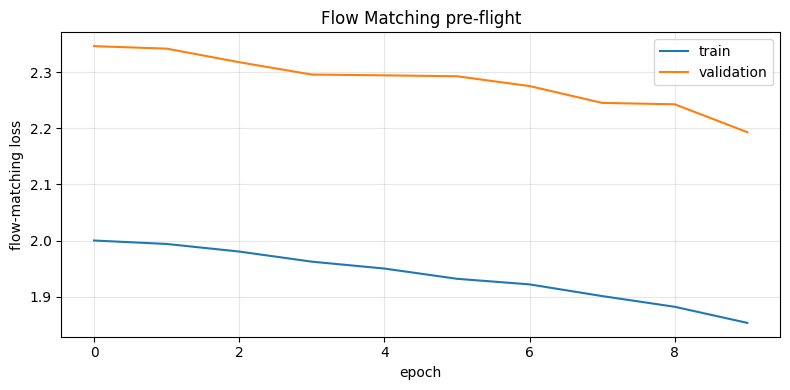

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    fm_preflight["train_history"],
    label="train",
)

plt.plot(
    fm_preflight["val_history"],
    label="validation",
)

plt.xlabel("epoch")
plt.ylabel("flow-matching loss")
plt.title("Flow Matching pre-flight")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
for epoch, (train_loss, val_loss) in enumerate(
    zip(
        nf_preflight["train_history"],
        nf_preflight["val_history"],
    ),
    start=1,
):
    print(
        f"Epoch {epoch:2d} | "
        f"train = {train_loss:12.4f} | "
        f"val = {val_loss:12.4f}"
    )

Epoch  1 | train =      89.3976 | val =      83.7332
Epoch  2 | train =      56.7186 | val =      76.1068
Epoch  3 | train =      35.4716 | val =     130.9800
Epoch  4 | train =      19.6206 | val =     190.4537
Epoch  5 | train =       7.1301 | val =     424.4809
Epoch  6 | train =      -2.9213 | val =     683.9629
Epoch  7 | train =     -11.1160 | val =     887.6739
Epoch  8 | train =     -18.2190 | val =    1061.0129
Epoch  9 | train =     -23.6063 | val =    1189.0496
Epoch 10 | train =     -28.8014 | val =    1456.7286


In [ ]:
nf_val = np.asarray(
    nf_preflight["val_history"]
)

best_epoch = int(
    np.argmin(nf_val)
) + 1

best_val = float(
    nf_val.min()
)

print("Best epoch:", best_epoch)
print("Best validation NLL:", best_val)

Best epoch: 2
Best validation NLL: 76.10679992039998


In [ ]:
pod = prepared_pilot["pod"]

coeff_train = pod.transform(
    prepared_pilot["trajectories_train"]
)

coeff_val = pod.transform(
    prepared_pilot["trajectories_val"]
)

coeff_test = pod.transform(
    prepared_pilot["trajectories_test"]
)

In [ ]:
coeff_normalizer = prepared_pilot[
    "coefficient_normalizer"
]

coeff_train_n = coeff_normalizer.transform(
    coeff_train
)

coeff_val_n = coeff_normalizer.transform(
    coeff_val
)

coeff_test_n = coeff_normalizer.transform(
    coeff_test
)

In [ ]:
def print_coeff_stats(name, x):
    values = np.asarray(x).ravel()

    print(f"\n{name}")
    print("mean:", values.mean())
    print("std:", values.std())
    print(
        "99% |value|:",
        np.quantile(
            np.abs(values),
            0.99,
        )
    )
    print(
        "max |value|:",
        np.abs(values).max()
    )


print_coeff_stats(
    "TRAIN",
    coeff_train_n,
)

print_coeff_stats(
    "VALIDATION",
    coeff_val_n,
)

print_coeff_stats(
    "TEST",
    coeff_test_n,
)


TRAIN
mean: 1.5868593815828933e-18
std: 1.0000000000000002
99% |value|: 3.039656520503804
max |value|: 8.966749952001079

VALIDATION
mean: -0.0008495962597626969
std: 1.1635117688793968
99% |value|: 3.8697622040709296
max |value|: 10.198633281950862

TEST
mean: -0.02412054081644746
std: 1.1305554279580523
99% |value|: 3.611014993197467
max |value|: 7.596426624228539


In [ ]:
mu_train_unique = np.unique(
    prepared_pilot["mus_train"],
    axis=0,
)

mu_val_unique = np.unique(
    prepared_pilot["mus_val"],
    axis=0,
)

mu_test_unique = np.unique(
    prepared_pilot["mus_test"],
    axis=0,
)

In [ ]:
for j in range(3):

    print(f"\nmu_{j+1}")

    print(
        "TRAIN:",
        mu_train_unique[:, j].min(),
        "->",
        mu_train_unique[:, j].max(),
    )

    print(
        "VAL:",
        mu_val_unique[:, j].min(),
        "->",
        mu_val_unique[:, j].max(),
    )

    print(
        "TEST:",
        mu_test_unique[:, j].min(),
        "->",
        mu_test_unique[:, j].max(),
    )


mu_1
TRAIN: -4.894740720659097 -> 5.769170380615385
VAL: -3.2608412294525326 -> 2.35763022717434
TEST: 0.022040110612039143 -> 2.17560918951356

mu_2
TRAIN: -5.28386524068518 -> 4.720669957405617
VAL: -2.5663279805954464 -> -1.0220854565564181
TEST: 0.38193104516239273 -> 4.5054821015421

mu_3
TRAIN: -4.552456008116115 -> 5.826717427328461
VAL: -3.2777825572295627 -> 4.39570989460039
TEST: -4.612579259048451 -> 1.6128115026158527


### Interpretation of the first preflight

RealNVP reaches its best validation value very early and then exhibits a rapidly increasing train/validation gap. The validation NLL eventually becomes extremely large even though the training NLL continues to improve.

Because the coefficient statistics do not show a severe out-of-distribution problem, the corrective action is to keep the architecture unchanged, reduce the learning rate to `1e-4`, and add early stopping with restoration of the best validation weights.


## 17. Early stopping and best-model restoration

Early stopping is introduced to prevent the definitive model from being selected at the final training epoch when validation performance has already deteriorated.

For RealNVP, the learning rate is reduced to `1e-4`. For both models, the trainer records the best validation epoch and restores the corresponding weights at the end of training. In the Flow Matching trainer, the validation noise and interpolation times are also fixed across epochs so that changes in validation loss primarily reflect changes in the model rather than changes in the random validation draw.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/training/realnvp_trainer.py

In [ ]:
import sys
import importlib

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.training.realnvp_trainer"
    ):
        del sys.modules[name]

    if name.startswith(
        "spde_surrogates.pipelines.static_realnvp"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.pipelines.static_realnvp import (
    train_static_realnvp,
)

In [ ]:
nf_preflight_v2_config = {
    "batch_size": 128,
    "epochs": 50,
    "lr": 0.0001,
    "weight_decay": 0.00001,
    "patience": 10,
    "min_delta": 0.0,
    "restore_best": True,
}

In [ ]:
nf_model_config_v2 = {
    "n_layers": 8,
    "hidden_size": 128,
    "hidden_depth": 2,
}

In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/training/realnvp_trainer.py

In [ ]:
import sys
import importlib

modules_to_remove = [
    name
    for name in list(sys.modules)
    if (
        name.startswith(
            "spde_surrogates.training.realnvp_trainer"
        )
        or name.startswith(
            "spde_surrogates.pipelines.static_realnvp"
        )
    )
]

for name in modules_to_remove:
    del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.pipelines.static_realnvp import (
    train_static_realnvp,
)

print("Reload OK")

Reload OK


In [ ]:
from spde_surrogates.training.realnvp_trainer import (
    train_realnvp,
)

import inspect

print(
    inspect.signature(
        train_realnvp
    )
)

(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)


In [ ]:
nf_preflight_v2_config = {
    "batch_size": 128,
    "epochs": 50,
    "lr": 0.0001,
    "weight_decay": 0.00001,
    "patience": 10,
    "min_delta": 0.0,
    "restore_best": True,
}

nf_model_config_v2 = {
    "n_layers": 8,
    "hidden_size": 128,
    "hidden_depth": 2,
}

In [ ]:
import time

start = time.perf_counter()

nf_preflight_v2 = train_static_realnvp(
    prepared_data=prepared_pilot,
    model_config=nf_model_config_v2,
    train_config=nf_preflight_v2_config,
    verbose=True,
)

elapsed = (
    time.perf_counter()
    - start
)

print(
    "Elapsed minutes:",
    elapsed / 60
)

Epoch    1/50 | train=1.066887e+02 | val=1.157929e+02 | best=1.157929e+02
Epoch    5/50 | train=8.237030e+01 | val=8.940012e+01 | best=8.940012e+01
Epoch   10/50 | train=5.735001e+01 | val=7.232784e+01 | best=7.232784e+01
Epoch   15/50 | train=4.480589e+01 | val=6.904469e+01 | best=6.868005e+01
Epoch   20/50 | train=3.575268e+01 | val=7.326628e+01 | best=6.866045e+01
Epoch   25/50 | train=2.782626e+01 | val=8.322617e+01 | best=6.866045e+01
Early stopping at epoch 26. Best epoch: 16.
Elapsed minutes: 1.5945117229333239


In [ ]:
train_v2 = np.asarray(
    nf_preflight_v2["train_history"]
)

val_v2 = np.asarray(
    nf_preflight_v2["val_history"]
)

best_epoch_v2 = int(
    np.argmin(val_v2)
) + 1

print(
    "Epochs actually run:",
    len(train_v2)
)

print(
    "Best epoch:",
    best_epoch_v2
)

print(
    "Best validation NLL:",
    val_v2[best_epoch_v2 - 1]
)

print(
    "Train NLL at best epoch:",
    train_v2[best_epoch_v2 - 1]
)

Epochs actually run: 26
Best epoch: 16
Best validation NLL: 68.66045379638672
Train NLL at best epoch: 43.981939561296215


In [ ]:
import inspect

import spde_surrogates.training.flow_matching_trainer as fmt
import spde_surrogates.pipelines.static_flow_matching as sfm

print(
    "Trainer file:",
    fmt.__file__
)

print(
    "\nTrainer signature:"
)

print(
    inspect.signature(
        fmt.train_flow_matching
    )
)

print(
    "\nTrainer seen by pipeline:"
)

print(
    inspect.signature(
        sfm.train_flow_matching
    )
)

Trainer file: /content/src/spde_surrogates/training/flow_matching_trainer.py

Trainer signature:
(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)

Trainer seen by pipeline:
(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)


In [ ]:
print(
    inspect.getsource(
        sfm.train_static_flow_matching
    )
)

def train_static_flow_matching(
    prepared_data,
    model_config=None,
    train_config=None,
    sampling_config=None,
    device=None,
    verbose=True,
):
    """
    Train a static POD + Flow Matching surrogate.

    IMPORTANT:
    prepared_data is the SAME object produced by
    prepare_static_data() and used by the RealNVP pipeline.

    This guarantees that NF and FM use exactly the same:
        - train/validation/test split
        - POD basis
        - POD dimension
        - condition normalization
        - coefficient normalization
    """

    if model_config is None:

        model_config = {
            "hidden_dims":
                (256, 256, 256),
        }

    if sampling_config is None:

        sampling_config = {
            "n_steps": 100,
        }

    dim_cond = (
        prepared_data[
            "X_train_norm"
        ].shape[-1]
    )

    dim_y = (
        prepared_data[
            "Y_train_norm"
        ].shape[-1]
    )

    model = (
        Cond

In [ ]:
import inspect

import spde_surrogates.training.flow_matching_trainer as fmt
import spde_surrogates.pipelines.static_flow_matching as sfm

print("TRAINER FILE:")
print(fmt.__file__)

print("\nTRAINER SIGNATURE:")
print(
    inspect.signature(
        fmt.train_flow_matching
    )
)

print("\nTRAINER SEEN BY PIPELINE:")
print(
    inspect.signature(
        sfm.train_flow_matching
    )
)

TRAINER FILE:
/content/src/spde_surrogates/training/flow_matching_trainer.py

TRAINER SIGNATURE:
(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)

TRAINER SEEN BY PIPELINE:
(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)


In [ ]:
print(
    inspect.getsource(
        sfm.train_static_flow_matching
    )
)

def train_static_flow_matching(
    prepared_data,
    model_config=None,
    train_config=None,
    sampling_config=None,
    device=None,
    verbose=True,
):
    """
    Train a static POD + Flow Matching surrogate.

    IMPORTANT:
    prepared_data is the SAME object produced by
    prepare_static_data() and used by the RealNVP pipeline.

    This guarantees that NF and FM use exactly the same:
        - train/validation/test split
        - POD basis
        - POD dimension
        - condition normalization
        - coefficient normalization
    """

    if model_config is None:

        model_config = {
            "hidden_dims":
                (256, 256, 256),
        }

    if sampling_config is None:

        sampling_config = {
            "n_steps": 100,
        }

    dim_cond = (
        prepared_data[
            "X_train_norm"
        ].shape[-1]
    )

    dim_y = (
        prepared_data[
            "Y_train_norm"
        ].shape[-1]
    )

    model = (
        Cond

In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/training/flow_matching_trainer.py

In [ ]:
import sys
import importlib
import inspect

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.training.flow_matching_trainer"
    ):
        del sys.modules[name]

    if name.startswith(
        "spde_surrogates.pipelines.static_flow_matching"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

import spde_surrogates.training.flow_matching_trainer as fmt
import spde_surrogates.pipelines.static_flow_matching as sfm

In [ ]:
print(
    inspect.signature(
        fmt.train_flow_matching
    )
)

print(
    inspect.signature(
        sfm.train_flow_matching
    )
)

(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)
(model, train_conditions, train_targets, val_conditions, val_targets, config=None, device=None, verbose=True)


In [ ]:
fm_preflight_v2_config = {
    "batch_size": 128,
    "epochs": 100,
    "lr": 0.0001,
    "weight_decay": 0.00001,
    "patience": 15,
    "min_delta": 0.0,
    "restore_best": True,
}

fm_model_config_v2 = {
    "hidden_dims": [
        256,
        256,
        256,
    ],
}

fm_sampling_config_v2 = {
    "n_steps": 100,
}

In [ ]:
import time

start = time.perf_counter()

fm_preflight_v2 = (
    sfm.train_static_flow_matching(
        prepared_data=prepared_pilot,
        model_config=fm_model_config_v2,
        train_config=fm_preflight_v2_config,
        sampling_config=fm_sampling_config_v2,
        verbose=True,
    )
)

fm_elapsed = (
    time.perf_counter()
    - start
)

print(
    "Elapsed minutes:",
    fm_elapsed / 60
)

Epoch    1/100 | train=1.997612e+00 | val=2.341231e+00 | best=2.341231e+00
Epoch   10/100 | train=1.874726e+00 | val=2.234498e+00 | best=2.234498e+00
Epoch   20/100 | train=1.639562e+00 | val=1.995505e+00 | best=1.995505e+00
Epoch   30/100 | train=1.511041e+00 | val=1.904774e+00 | best=1.904774e+00
Epoch   40/100 | train=1.420096e+00 | val=1.839373e+00 | best=1.839373e+00
Epoch   50/100 | train=1.355522e+00 | val=1.826579e+00 | best=1.812919e+00
Epoch   60/100 | train=1.307907e+00 | val=1.820436e+00 | best=1.810021e+00
Epoch   70/100 | train=1.259045e+00 | val=1.811527e+00 | best=1.806983e+00
Epoch   80/100 | train=1.221535e+00 | val=1.807633e+00 | best=1.797583e+00
Epoch   90/100 | train=1.198878e+00 | val=1.812431e+00 | best=1.797583e+00
Epoch  100/100 | train=1.167681e+00 | val=1.801831e+00 | best=1.797368e+00
Elapsed minutes: 1.5798123302666984


In [ ]:
fm_train_v2 = np.asarray(
    fm_preflight_v2[
        "train_history"
    ]
)

fm_val_v2 = np.asarray(
    fm_preflight_v2[
        "val_history"
    ]
)

fm_best_epoch = int(
    np.argmin(
        fm_val_v2
    )
) + 1

print(
    "Epochs actually run:",
    len(fm_train_v2)
)

print(
    "Best epoch:",
    fm_best_epoch
)

print(
    "Best validation FM loss:",
    fm_val_v2[
        fm_best_epoch - 1
    ]
)

print(
    "Train loss at best epoch:",
    fm_train_v2[
        fm_best_epoch - 1
    ]
)

print(
    "Final recorded validation:",
    fm_val_v2[-1]
)

Epochs actually run: 100
Best epoch: 91
Best validation FM loss: 1.7973676919937134
Train loss at best epoch: 1.184351609181481
Final recorded validation: 1.8018308877944946


### Result and interpretation

The stabilized RealNVP preflight runs for 26 epochs, reaches its best validation value at epoch **16**, and stops automatically after the configured patience. The best validation NLL is approximately **68.66**.

Flow Matching remains stable throughout the 100-epoch preflight and reaches its best validation loss near epoch **91**, at approximately **1.797**.

The important result is not the numerical comparison between the two losses, which is meaningless because the objectives differ. The relevant conclusion is that both training procedures are now stable enough for the definitive pilot run.


## 18. Definitive pilot training

The definitive pilot training uses the configurations selected after the preflight analysis. RealNVP is allowed up to 300 epochs with `lr=1e-4` and patience 20, while Flow Matching uses the same learning rate with patience 30.

Both models are trained on exactly the same reduced-order representation, group split, and normalized conditioning variables. This is essential for interpreting the later accuracy comparison as a comparison between generative models rather than between different preprocessing pipelines.


In [ ]:
from spde_surrogates.config import load_config

pilot_config = load_config(
    "/content/static_comparison_pilot.yaml"
)

print(pilot_config["realnvp"]["training"])
print(pilot_config["flow_matching"]["training"])

{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 20, 'min_delta': 0.0, 'restore_best': True}
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 30, 'min_delta': 0.0, 'restore_best': True}


In [ ]:
import numpy as np
import torch
import time

np.random.seed(
    pilot_config["experiment"]["seed"]
)

torch.manual_seed(
    pilot_config["experiment"]["seed"]
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        pilot_config["experiment"]["seed"]
    )

In [ ]:
import spde_surrogates.pipelines.static_realnvp as sr

In [ ]:
start = time.perf_counter()

nf_final = sr.train_static_realnvp(
    prepared_data=prepared_pilot,
    model_config=pilot_config[
        "realnvp"
    ]["model"],
    train_config=pilot_config[
        "realnvp"
    ]["training"],
    verbose=True,
)

nf_final_elapsed = (
    time.perf_counter()
    - start
)

print(
    "NF final training minutes:",
    nf_final_elapsed / 60
)

Epoch    1/300 | train=1.066065e+02 | val=1.145003e+02 | best=1.145003e+02
Epoch   30/300 | train=1.878054e+01 | val=1.201850e+02 | best=7.032401e+01
Early stopping at epoch 33. Best epoch: 13.
NF final training minutes: 2.2730721413333717


In [ ]:
nf_train_final = np.asarray(
    nf_final["train_history"]
)

nf_val_final = np.asarray(
    nf_final["val_history"]
)

nf_best_epoch = (
    int(np.argmin(nf_val_final))
    + 1
)

print(
    "NF epochs run:",
    len(nf_train_final)
)

print(
    "NF best epoch:",
    nf_best_epoch
)

print(
    "NF best validation:",
    nf_val_final.min()
)

print(
    "NF train @ best:",
    nf_train_final[
        nf_best_epoch - 1
    ]
)

NF epochs run: 33
NF best epoch: 13
NF best validation: 70.32401275634766
NF train @ best: 48.95021700501611


In [ ]:
from spde_surrogates.surrogates.static_pod import (
    StaticPODGenerativeSurrogate,
)

nf_surrogate_final = StaticPODGenerativeSurrogate(
    model=nf_final["model"],
    pod=prepared_pilot["pod"],
    condition_normalizer=prepared_pilot[
        "condition_normalizer"
    ],
    coefficient_normalizer=prepared_pilot[
        "coefficient_normalizer"
    ],
    sampling_config={},
)

In [ ]:
mu_test_example = prepared_pilot[
    "mus_test"
][0]

nf_test_samples = (
    nf_surrogate_final.sample(
        mu=mu_test_example,
        times=times,
        n_samples=2,
        temporal_coupling="shared_noise",
    )
)

print(nf_test_samples.shape)
print(np.isfinite(nf_test_samples).all())

(2, 101, 2763)
True


In [ ]:
from pathlib import Path

from spde_surrogates.persistence.checkpoint import (
    save_static_surrogate,
)

local_checkpoint_dir = Path(
    "/content/outputs/"
    "static_comparison_pilot/checkpoints"
)

local_checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

nf_checkpoint_path = (
    local_checkpoint_dir
    / "realnvp.pt"
)

In [ ]:
save_static_surrogate(
    path=nf_checkpoint_path,
    surrogate=nf_surrogate_final,
    model_type="realnvp",
    model_config=pilot_config[
        "realnvp"
    ]["model"],
    train_config=nf_final[
        "train_config"
    ],
    metadata={
        "experiment_name":
            "static_comparison_pilot",

        "n_mu":
            20,

        "n_realizations":
            10,

        "n_pod_modes":
            76,

        "dataset":
            "static_comparison_pilot_20x10.npz",
    },
)

print(
    nf_checkpoint_path.is_file()
)

True


In [ ]:
import shutil

drive_checkpoint_dir = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/"
    "outputs/static_comparison_pilot/"
    "checkpoints"
)

drive_checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

nf_drive_path = (
    drive_checkpoint_dir
    / "realnvp.pt"
)

shutil.copy2(
    nf_checkpoint_path,
    nf_drive_path,
)

print(
    "NF Drive backup:",
    nf_drive_path.is_file()
)

NF Drive backup: True


In [ ]:
np.random.seed(
    pilot_config["experiment"]["seed"]
)

torch.manual_seed(
    pilot_config["experiment"]["seed"]
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        pilot_config["experiment"]["seed"]
    )

In [ ]:
import spde_surrogates.pipelines.static_flow_matching as sfm

In [ ]:
start = time.perf_counter()

fm_final = sfm.train_static_flow_matching(
    prepared_data=prepared_pilot,
    model_config=pilot_config[
        "flow_matching"
    ]["model"],
    train_config=pilot_config[
        "flow_matching"
    ]["training"],
    sampling_config=pilot_config[
        "flow_matching"
    ]["sampling"],
    verbose=True,
)

fm_final_elapsed = (
    time.perf_counter()
    - start
)

print(
    "FM final training minutes:",
    fm_final_elapsed / 60
)

Epoch    1/300 | train=1.995640e+00 | val=2.359817e+00 | best=2.359817e+00
Epoch   30/300 | train=1.529097e+00 | val=1.951249e+00 | best=1.951249e+00
Epoch   60/300 | train=1.326002e+00 | val=1.871292e+00 | best=1.860682e+00
Epoch   90/300 | train=1.213775e+00 | val=1.869945e+00 | best=1.850010e+00
Early stopping at epoch 116. Best epoch: 86.
FM final training minutes: 2.0884212706166485


In [ ]:
fm_train_final = np.asarray(
    fm_final["train_history"]
)

fm_val_final = np.asarray(
    fm_final["val_history"]
)

fm_best_epoch = (
    int(np.argmin(fm_val_final))
    + 1
)

print(
    "FM epochs run:",
    len(fm_train_final)
)

print(
    "FM best epoch:",
    fm_best_epoch
)

print(
    "FM best validation:",
    fm_val_final.min()
)

print(
    "FM train @ best:",
    fm_train_final[
        fm_best_epoch - 1
    ]
)

FM epochs run: 116
FM best epoch: 86
FM best validation: 1.8500101566314697
FM train @ best: 1.220918506948749


In [ ]:
fm_surrogate_final = StaticPODGenerativeSurrogate(
    model=fm_final["model"],
    pod=prepared_pilot["pod"],
    condition_normalizer=prepared_pilot[
        "condition_normalizer"
    ],
    coefficient_normalizer=prepared_pilot[
        "coefficient_normalizer"
    ],
    sampling_config=pilot_config[
        "flow_matching"
    ]["sampling"],
)

In [ ]:
fm_test_samples = (
    fm_surrogate_final.sample(
        mu=mu_test_example,
        times=times,
        n_samples=2,
        temporal_coupling="shared_noise",
    )
)

print(fm_test_samples.shape)
print(np.isfinite(fm_test_samples).all())

(2, 101, 2763)
True


In [ ]:
fm_checkpoint_path = (
    local_checkpoint_dir
    / "flow_matching.pt"
)

save_static_surrogate(
    path=fm_checkpoint_path,
    surrogate=fm_surrogate_final,
    model_type="flow_matching",
    model_config=pilot_config[
        "flow_matching"
    ]["model"],
    train_config=fm_final[
        "train_config"
    ],
    metadata={
        "experiment_name":
            "static_comparison_pilot",

        "n_mu":
            20,

        "n_realizations":
            10,

        "n_pod_modes":
            76,

        "dataset":
            "static_comparison_pilot_20x10.npz",
    },
)

In [ ]:
fm_drive_path = (
    drive_checkpoint_dir
    / "flow_matching.pt"
)

shutil.copy2(
    fm_checkpoint_path,
    fm_drive_path,
)

print(
    "FM local:",
    fm_checkpoint_path.is_file()
)

print(
    "FM Drive backup:",
    fm_drive_path.is_file()
)

FM local: True
FM Drive backup: True


### Result and interpretation

RealNVP runs for 33 epochs and achieves its best validation NLL at epoch **13**, with a value of approximately **70.32**. Flow Matching runs for 116 epochs and reaches its best validation loss at epoch **86**, with a value of approximately **1.850**.

The two trained models are saved successfully to Google Drive. The different numerical scales of the two validation losses should again not be interpreted as a direct comparison of model quality; final model quality is evaluated using common distributional metrics.


## 19. Quantitative evaluation of the pilot

The definitive pilot comparison is performed on three parameter configurations that were never used during training. For each parameter, the test set contains 10 FOM realizations, while each surrogate generates 100 synthetic trajectories.

The primary metric is the Energy Distance on complete trajectories. The evaluation also records a time-wise Energy Distance and a nearest-neighbor relative error. The exact finite-sample estimator used for Energy Distance is verified later in the methodological section.


In [ ]:
!rm -rf /content/src
!rm -f /content/src.zip

In [ ]:
!unzip -q /content/src.zip -d /content

In [ ]:
!python -m py_compile /content/src/spde_surrogates/evaluation/metrics.py

In [ ]:
import sys
import importlib

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.evaluation"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.evaluation.evaluator import (
    evaluate_surrogate,
)

In [ ]:
test_indices = prepared_pilot[
    "split"
]["test_indices"]

test_group_ids = group_ids[
    test_indices
]

print(
    "Test trajectories:",
    len(test_group_ids)
)

print(
    "Test groups:",
    np.unique(test_group_ids)
)

print(
    "Number of test mu:",
    len(np.unique(test_group_ids))
)

Test trajectories: 30
Test groups: [ 6 13 19]
Number of test mu: 3


In [ ]:
_, test_counts = np.unique(
    test_group_ids,
    return_counts=True,
)

print(test_counts)

[10 10 10]


In [ ]:
EVALUATION_SEED = 2026

In [ ]:
import torch
import time

np.random.seed(
    EVALUATION_SEED
)

torch.manual_seed(
    EVALUATION_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

start = time.perf_counter()

nf_eval_final = evaluate_surrogate(
    surrogate=nf_surrogate_final,
    real_trajectories=prepared_pilot[
        "trajectories_test"
    ],
    mus=prepared_pilot[
        "mus_test"
    ],
    group_ids=test_group_ids,
    times=times,
    n_generated=100,
    temporal_coupling="shared_noise",
    verbose=True,
)

nf_eval_seconds = (
    time.perf_counter()
    - start
)

print(
    "NF evaluation seconds:",
    nf_eval_seconds
)

group   1/3 (id=6) - Nreal=10 - Ngen=100 - D2=2.579455e+01
group   2/3 (id=13) - Nreal=10 - Ngen=100 - D2=2.202563e+01
group   3/3 (id=19) - Nreal=10 - Ngen=100 - D2=1.858576e+01
NF evaluation seconds: 12.590139620002446


In [ ]:
np.random.seed(
    EVALUATION_SEED
)

torch.manual_seed(
    EVALUATION_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

start = time.perf_counter()

fm_eval_final = evaluate_surrogate(
    surrogate=fm_surrogate_final,
    real_trajectories=prepared_pilot[
        "trajectories_test"
    ],
    mus=prepared_pilot[
        "mus_test"
    ],
    group_ids=test_group_ids,
    times=times,
    n_generated=100,
    temporal_coupling="shared_noise",
    verbose=True,
)

fm_eval_seconds = (
    time.perf_counter()
    - start
)

print(
    "FM evaluation seconds:",
    fm_eval_seconds
)

group   1/3 (id=6) - Nreal=10 - Ngen=100 - D2=1.092512e+01
group   2/3 (id=13) - Nreal=10 - Ngen=100 - D2=6.525478e+00
group   3/3 (id=19) - Nreal=10 - Ngen=100 - D2=7.364368e+00
FM evaluation seconds: 47.29106329899878


In [ ]:
def print_evaluation_summary(
    name,
    evaluation,
):
    summary = evaluation[
        "summary"
    ]

    print(f"\n{name}")

    print(
        "Energy mean:",
        summary["energy_mean"]
    )

    print(
        "Energy median:",
        summary["energy_median"]
    )

    print(
        "Energy min:",
        summary["energy_min"]
    )

    print(
        "Energy max:",
        summary["energy_max"]
    )

    print(
        "Energy std:",
        summary["energy_std"]
    )

    print(
        "NN relative mean:",
        summary[
            "nearest_neighbor_mean"
        ]
    )


print_evaluation_summary(
    "REALNVP",
    nf_eval_final,
)

print_evaluation_summary(
    "FLOW MATCHING",
    fm_eval_final,
)


REALNVP
Energy mean: 22.13531304842849
Energy median: 22.02563245769256
Energy min: 18.585759569138588
Energy max: 25.794547118454325
Energy std: 2.9439969267172064
NN relative mean: 0.27651065115729795

FLOW MATCHING
Energy mean: 8.27165640810597
Energy median: 7.364368394756312
Energy min: 6.525478313163553
Energy max: 10.925122516398048
Energy std: 1.9072835714945835
NN relative mean: 0.21629146214419803


In [ ]:
print("REALNVP")

for result in nf_eval_final[
    "per_group"
]:
    print(
        "group:",
        result["group_id"],
        "| mu:",
        result["mu"],
        "| D2:",
        result[
            "energy_distance_squared"
        ],
    )

REALNVP
group: 6 | mu: [0.37861649 0.38193105 1.6128115 ] | D2: 25.794547118454325
group: 13 | mu: [ 0.02204011  1.48743542 -4.61257926] | D2: 22.02563245769256
group: 19 | mu: [2.17560919 4.5054821  0.12506805] | D2: 18.585759569138588


In [ ]:
print("FLOW MATCHING")

for result in fm_eval_final[
    "per_group"
]:
    print(
        "group:",
        result["group_id"],
        "| mu:",
        result["mu"],
        "| D2:",
        result[
            "energy_distance_squared"
        ],
    )

FLOW MATCHING
group: 6 | mu: [0.37861649 0.38193105 1.6128115 ] | D2: 10.925122516398048
group: 13 | mu: [ 0.02204011  1.48743542 -4.61257926] | D2: 6.525478313163553
group: 19 | mu: [2.17560919 4.5054821  0.12506805] | D2: 7.364368394756312


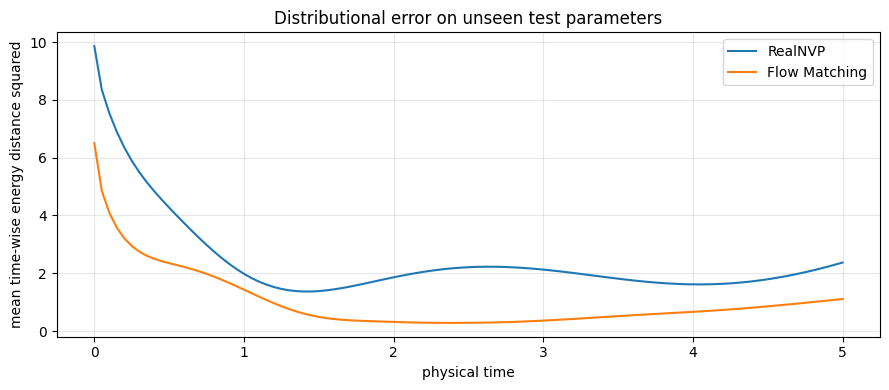

In [ ]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(9, 4)
)

plt.plot(
    times,
    nf_eval_final[
        "summary"
    ]["timewise_mean"],
    label="RealNVP",
)

plt.plot(
    times,
    fm_eval_final[
        "summary"
    ]["timewise_mean"],
    label="Flow Matching",
)

plt.xlabel(
    "physical time"
)

plt.ylabel(
    "mean time-wise energy distance squared"
)

plt.title(
    "Distributional error on unseen test parameters"
)

plt.grid(
    True,
    alpha=0.3,
)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pickle

evaluation_drive_path = (
    Path(
        "/content/drive/MyDrive/Tesi/"
        "generative-spde-surrogates/"
        "outputs/static_comparison_pilot"
    )
    / "evaluation_shared_noise.pkl"
)

evaluation_drive_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    evaluation_drive_path,
    "wb",
) as file:

    pickle.dump(
        {
            "nf":
                nf_eval_final,

            "fm":
                fm_eval_final,

            "evaluation_seed":
                EVALUATION_SEED,

            "n_generated":
                100,

            "temporal_coupling":
                "shared_noise",
        },
        file,
    )

print(
    evaluation_drive_path.is_file()
)

True


### Main pilot result

The mean trajectory Energy Distance is approximately **22.14 for RealNVP** and **8.27 for Flow Matching**. Flow Matching therefore reduces the mean Energy Distance by roughly **62.6%**.

The improvement is not produced by a single favorable test point: Flow Matching has a lower Energy Distance for **all 3/3 unseen parameter configurations**. The nearest-neighbor relative mean also improves, from approximately **0.2765** for RealNVP to **0.2163** for Flow Matching.

This provides the first clear experimental evidence that Flow Matching is representing the conditional FOM distribution more accurately than RealNVP in the current static POD setting.


## 20. Online benchmark and qualitative pilot comparison

After measuring accuracy, the second part of the comparison concerns online efficiency. The benchmark is run for batch sizes `N = 1, 10, 50, 100`, using the same physical time grid and POD reconstruction.

A qualitative comparison is also carried out on a representative test group with a large NF/FM accuracy gap. Temporal probes and animations are used to verify that the distributional advantage observed numerically also corresponds to sensible physical trajectories.


In [ ]:
from spde_surrogates.evaluation.benchmark import (
    benchmark_surrogates,
)

In [ ]:
benchmark_mu = prepared_pilot[
    "mus_test"
][0]

print(benchmark_mu)

[0.37861649 0.38193105 1.6128115 ]


In [ ]:
benchmark_final = benchmark_surrogates(
    surrogates={
        "RealNVP": nf_surrogate_final,
        "Flow Matching": fm_surrogate_final,
    },
    mu=benchmark_mu,
    times=times,
    sample_sizes=[
        1,
        10,
        50,
        100,
    ],
    n_repeats=5,
    n_warmup=2,
    temporal_coupling="shared_noise",
)


Benchmarking RealNVP...
  N=    1 | median=0.048635 s | per sample=4.863532e-02 s | throughput=20.56 samples/s
  N=   10 | median=0.236863 s | per sample=2.368629e-02 s | throughput=42.22 samples/s
  N=   50 | median=0.733870 s | per sample=1.467741e-02 s | throughput=68.13 samples/s
  N=  100 | median=0.981510 s | per sample=9.815101e-03 s | throughput=101.88 samples/s

Benchmarking Flow Matching...
  N=    1 | median=0.242617 s | per sample=2.426167e-01 s | throughput=4.12 samples/s
  N=   10 | median=1.373896 s | per sample=1.373896e-01 s | throughput=7.28 samples/s
  N=   50 | median=5.049479 s | per sample=1.009896e-01 s | throughput=9.90 samples/s
  N=  100 | median=9.444932 s | per sample=9.444932e-02 s | throughput=10.59 samples/s


In [ ]:
for model_name in [
    "RealNVP",
    "Flow Matching",
]:

    print("\n", model_name)

    for result in benchmark_final[
        model_name
    ]:

        print(
            "N =",
            result["n_samples"],
            "| median =",
            result["median_seconds"],
            "s",
            "| per sample =",
            result["seconds_per_sample"],
            "s",
            "| samples/s =",
            result["samples_per_second"],
        )


 RealNVP
N = 1 | median = 0.04863531799855991 s | per sample = 0.04863531799855991 s | samples/s = 20.561189710522914
N = 10 | median = 0.23686291400008486 s | per sample = 0.023686291400008486 s | samples/s = 42.21851294118765
N = 50 | median = 0.7338703100031125 s | per sample = 0.01467740620006225 s | samples/s = 68.13192919575658
N = 100 | median = 0.9815101499989396 s | per sample = 0.009815101499989397 s | samples/s = 101.88381648433084

 Flow Matching
N = 1 | median = 0.2426166790028219 s | per sample = 0.2426166790028219 s | samples/s = 4.121728168525334
N = 10 | median = 1.3738957220011798 s | per sample = 0.137389572200118 s | samples/s = 7.2785727765672545
N = 50 | median = 5.049478767999972 s | per sample = 0.10098957535999943 s | samples/s = 9.902012127838752
N = 100 | median = 9.44493218900243 s | per sample = 0.0944493218900243 s | samples/s = 10.587688508387478


### Pilot generation efficiency

For 100 generated trajectories, RealNVP requires about **0.98 s**, corresponding to roughly 102 trajectories per second. Flow Matching requires about **9.44 s**, or roughly 10.6 trajectories per second.

At this batch size, Flow Matching is therefore approximately **9.6× slower**. This is consistent with the different sampling mechanisms: RealNVP applies a finite sequence of invertible transformations, while Flow Matching numerically integrates the learned velocity field over 100 Euler steps.

The pilot already reveals the central trade-off of the thesis comparison: **Flow Matching is substantially more accurate, while RealNVP is substantially faster online**.


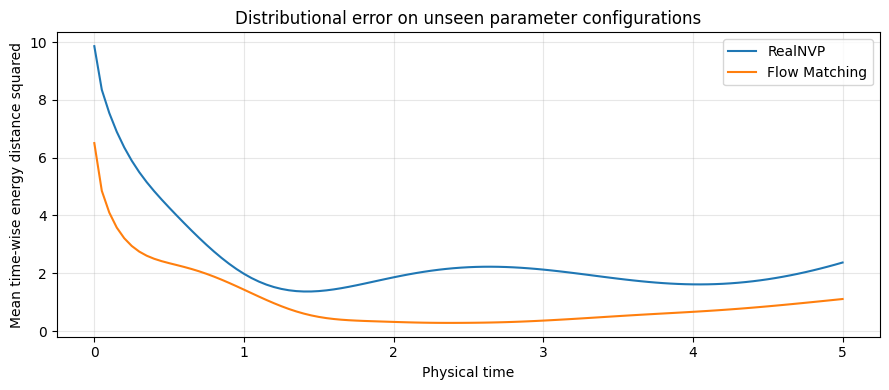

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))

plt.plot(
    times,
    nf_eval_final["summary"]["timewise_mean"],
    label="RealNVP",
)

plt.plot(
    times,
    fm_eval_final["summary"]["timewise_mean"],
    label="Flow Matching",
)

plt.xlabel("Physical time")
plt.ylabel("Mean time-wise energy distance squared")
plt.title(
    "Distributional error on unseen parameter configurations"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
target_group = 13 #differenza maggiore

mask_group = (
    test_group_ids == target_group
)

real_group = prepared_pilot[
    "trajectories_test"
][mask_group]

mu_group = prepared_pilot[
    "mus_test"
][mask_group][0]

print("mu:", mu_group)
print("Real trajectories:", real_group.shape)

mu: [ 0.02204011  1.48743542 -4.61257926]
Real trajectories: (10, 101, 2763)


In [ ]:
torch.manual_seed(2026)

nf_group_samples = (
    nf_surrogate_final.sample(
        mu=mu_group,
        times=times,
        n_samples=20,
        temporal_coupling="shared_noise",
    )
)

torch.manual_seed(2026)

fm_group_samples = (
    fm_surrogate_final.sample(
        mu=mu_group,
        times=times,
        n_samples=20,
        temporal_coupling="shared_noise",
    )
)

print(real_group.shape)
print(nf_group_samples.shape)
print(fm_group_samples.shape)

(10, 101, 2763)
(20, 101, 2763)
(20, 101, 2763)


Selected DOF: 1904


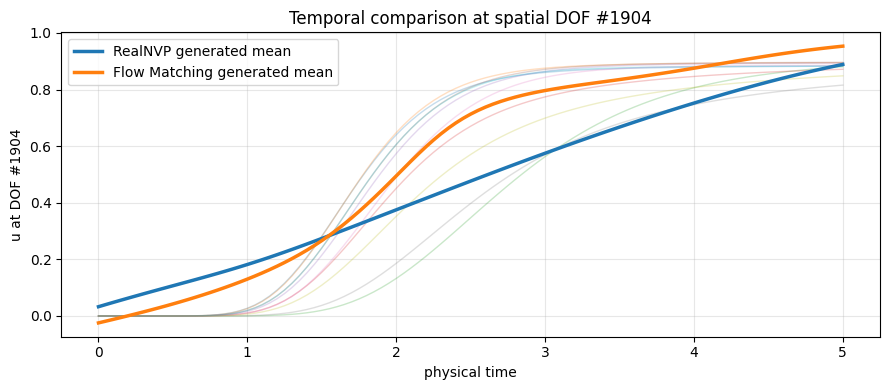

In [ ]:
from spde_surrogates.evaluation.qualitative import (
    plot_temporal_probe_comparison,
)

fig, ax, probe = (
    plot_temporal_probe_comparison(
        times=times,
        real_trajectories=real_group,
        generated_sets={
            "RealNVP":
                nf_group_samples,

            "Flow Matching":
                fm_group_samples,
        },
    )
)

print("Selected DOF:", probe)

plt.show()

In [ ]:
U_real = real_group[0]
U_nf = nf_group_samples[0]
U_fm = fm_group_samples[0]

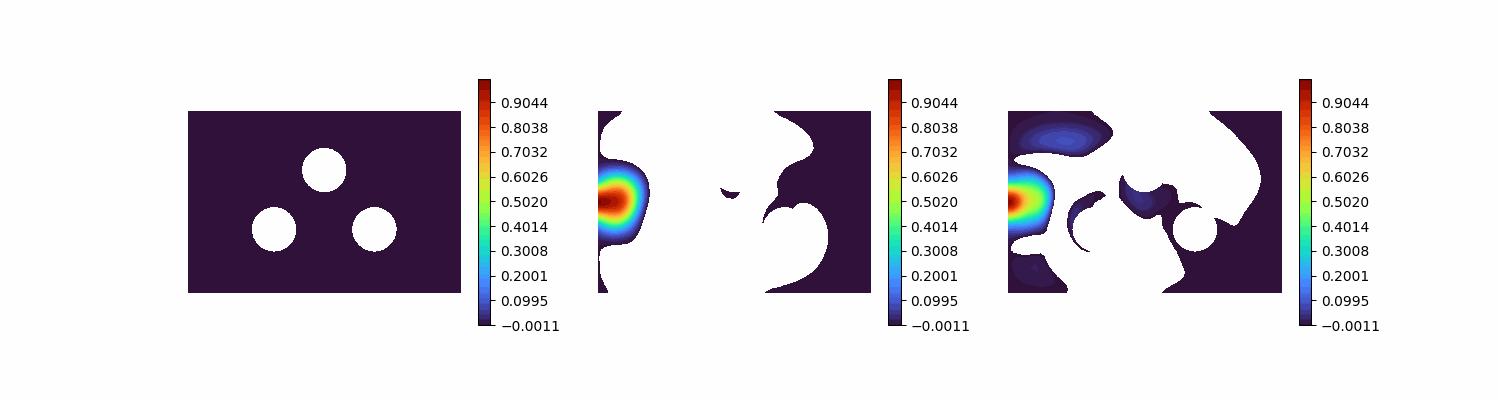

In [ ]:
from spde_surrogates.problems import (
    randomized_advection_diffusion as rad
)

rad.animate_trajectory_comparison(
    (
        U_real,
        U_nf,
        U_fm,
    )
)

### Qualitative interpretation

Group 13 is selected for closer inspection because it shows one of the largest differences between RealNVP and Flow Matching in the quantitative evaluation.

The temporal probe and FEniCS animation provide a more intuitive view of the result. They are particularly useful for discussions with supervisors because they connect the abstract distributional metrics to the actual evolution of the physical field.


## 21. Recovering the pilot after a Colab reset

This section documents a practical but important robustness test. After the runtime state was lost, the experiment was reconstructed without rerunning the expensive FOM generation, POD fit, or model training.

The dataset is reloaded from Drive, the two surrogates are restored from their checkpoints, and the saved evaluation and benchmark results are loaded from persistent files. The split and POD reconstruction metrics can then be reconstructed from the saved artifacts.

The import and missing-variable errors visible at the beginning of this section are part of that troubleshooting process. They motivated the final recovery procedure and the decision to save more experimental metadata permanently.


In [ ]:
!python -m py_compile /content/src/spde_surrogates/evaluation/reporting.py

[Errno 2] No such file or directory: '/content/src/spde_surrogates/evaluation/reporting.py'

In [ ]:
import sys
import importlib

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.evaluation.reporting"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.evaluation.reporting import (
    export_static_comparison_report,
)

ModuleNotFoundError: No module named 'spde_surrogates'

In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(0, "/content/src")

print(sys.path[0])

/content/src


In [ ]:
import spde_surrogates

print("Package OK")

Package OK


In [ ]:
from spde_surrogates.evaluation.reporting import (
    export_static_comparison_report,
)

print("Reporting OK")

Reporting OK


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates"
)

print(PROJECT_DRIVE)

/content/drive/MyDrive/Tesi/generative-spde-surrogates


In [ ]:
from spde_surrogates.config import load_config

pilot_config = load_config(
    "/content/static_comparison_pilot.yaml"
)

print(pilot_config["experiment"]["name"])

static_comparison_pilot


In [ ]:
from spde_surrogates.data.dataset import (
    load_fom_dataset,
)

dataset_path = (
    PROJECT_DRIVE
    / "data"
    / "static_comparison_pilot_20x10.npz"
)

(
    mu_bank,
    times,
    mus,
    trajectories,
    group_ids,
) = load_fom_dataset(
    dataset_path
)

In [ ]:
print(mu_bank.shape)
print(times.shape)
print(mus.shape)
print(trajectories.shape)
print(group_ids.shape)

(20, 3)
(101,)
(200, 3)
(200, 101, 2763)
(200,)


In [ ]:
from spde_surrogates.persistence.checkpoint import (
    load_static_surrogate,
)

In [ ]:
checkpoint_dir = (
    PROJECT_DRIVE
    / "outputs"
    / "static_comparison_pilot"
    / "checkpoints"
)

nf_checkpoint = (
    checkpoint_dir
    / "realnvp.pt"
)

fm_checkpoint = (
    checkpoint_dir
    / "flow_matching.pt"
)

In [ ]:
nf_surrogate_final, nf_info = (
    load_static_surrogate(
        nf_checkpoint
    )
)

fm_surrogate_final, fm_info = (
    load_static_surrogate(
        fm_checkpoint
    )
)

In [ ]:
print(
    "NF:",
    nf_info["model_type"],
    nf_surrogate_final.pod.n_modes_,
)

print(
    "FM:",
    fm_info["model_type"],
    fm_surrogate_final.pod.n_modes_,
)

NF: realnvp 76
FM: flow_matching 76


In [ ]:
import pickle

results_dir = (
    PROJECT_DRIVE
    / "outputs"
    / "static_comparison_pilot"
)

In [ ]:
with open(
    results_dir / "evaluation_shared_noise.pkl",
    "rb",
) as file:

    saved_evaluation = pickle.load(file)

nf_eval_final = saved_evaluation["nf"]
fm_eval_final = saved_evaluation["fm"]

In [ ]:
print(
    nf_eval_final["summary"]["energy_mean"]
)

print(
    fm_eval_final["summary"]["energy_mean"]
)

22.13531304842849
8.27165640810597


In [ ]:
print(
    benchmark_final.keys()
)

NameError: name 'benchmark_final' is not defined

In [ ]:
from spde_surrogates.data.splitting import (
    split_by_group,
)

split_recovered = split_by_group(
    group_ids=group_ids,
    train_fraction=pilot_config[
        "split"
    ]["train_fraction"],
    val_fraction=pilot_config[
        "split"
    ]["val_fraction"],
    test_fraction=pilot_config[
        "split"
    ]["test_fraction"],
    seed=pilot_config[
        "split"
    ]["seed"],
)

In [ ]:
train_indices = split_recovered[
    "train_indices"
]

val_indices = split_recovered[
    "val_indices"
]

test_indices = split_recovered[
    "test_indices"
]

In [ ]:
pod_recovered = (
    nf_surrogate_final.pod
)

prepared_pilot = {
    "pod":
        pod_recovered,

    "split":
        split_recovered,

    "trajectories_train":
        trajectories[
            train_indices
        ],

    "trajectories_val":
        trajectories[
            val_indices
        ],

    "trajectories_test":
        trajectories[
            test_indices
        ],

    "mus_train":
        mus[
            train_indices
        ],

    "mus_val":
        mus[
            val_indices
        ],

    "mus_test":
        mus[
            test_indices
        ],
}

In [ ]:
print(
    prepared_pilot[
        "trajectories_train"
    ].shape
)

print(
    prepared_pilot[
        "trajectories_val"
    ].shape
)

print(
    prepared_pilot[
        "trajectories_test"
    ].shape
)

(140, 101, 2763)
(30, 101, 2763)
(30, 101, 2763)


In [ ]:
train_pod_metrics = (
    pod_recovered.reconstruction_metrics(
        prepared_pilot[
            "trajectories_train"
        ]
    )
)

val_pod_metrics = (
    pod_recovered.reconstruction_metrics(
        prepared_pilot[
            "trajectories_val"
        ]
    )
)

test_pod_metrics = (
    pod_recovered.reconstruction_metrics(
        prepared_pilot[
            "trajectories_test"
        ]
    )
)

In [ ]:
print(
    train_pod_metrics[
        "trajectory_relative_error"
    ]
)

print(
    val_pod_metrics[
        "trajectory_relative_error"
    ]
)

print(
    test_pod_metrics[
        "trajectory_relative_error"
    ]
)

0.00992709248897171
0.013693522996589767
0.012708079693239414


In [ ]:
pilot_pod_metrics = {
    "train": train_pod_metrics,
    "val": val_pod_metrics,
    "test": test_pod_metrics,
}

In [ ]:
print("NF info keys:", nf_info.keys())
print("FM info keys:", fm_info.keys())

print("\nNF train config:")
print(nf_info.get("train_config"))

print("\nFM train config:")
print(fm_info.get("train_config"))

NF info keys: dict_keys(['format_version', 'model_type', 'model_config', 'train_config', 'sampling_config', 'metadata'])
FM info keys: dict_keys(['format_version', 'model_type', 'model_config', 'train_config', 'sampling_config', 'metadata'])

NF train config:
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 20, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 13, 'best_val_loss': 70.32401275634766, 'epochs_ran': 33}

FM train config:
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 30, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 86, 'best_val_loss': 1.8500101566314697, 'epochs_ran': 116}


In [ ]:
nf_result_recovered = {
    "train_config": nf_info["train_config"],
    "train_history": [],
    "val_history": [],
}

fm_result_recovered = {
    "train_config": fm_info["train_config"],
    "train_history": [],
    "val_history": [],
}

In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(0, "/content/src")

In [ ]:
!python -m py_compile /content/src/spde_surrogates/evaluation/reporting.py

In [ ]:
import importlib
import sys

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.evaluation.reporting"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.evaluation.reporting import (
    export_static_comparison_report,
)

In [ ]:
print(
    nf_eval_final["summary"]["energy_mean"]
)

print(
    fm_eval_final["summary"]["energy_mean"]
)

print(
    benchmark_final.keys()
)

22.13531304842849
8.27165640810597


NameError: name 'benchmark_final' is not defined

In [ ]:
from pathlib import Path

report_dir = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/"
    "outputs/static_comparison_pilot/"
    "report"
)

In [ ]:
report_paths = export_static_comparison_report(
    output_dir=report_dir,
    config=pilot_config,
    prepared_data=prepared_pilot,
    pod_metrics=pilot_pod_metrics,
    nf_result=nf_result_recovered,
    fm_result=fm_result_recovered,
    nf_evaluation=nf_eval_final,
    fm_evaluation=fm_eval_final,
    benchmark=benchmark_final,
    times=times,
)

print("REPORT CREATED")

NameError: name 'benchmark_final' is not defined

In [ ]:
print(
    report_paths["summary"]
)

NameError: name 'report_paths' is not defined

In [ ]:
!find "/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report" -maxdepth 3 -type f -print

find: ‘/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report’: No such file or directory


In [ ]:
import numpy as np
import torch

test_group_ids = group_ids[
    test_indices
]

target_group = 13

mask_group = (
    test_group_ids
    == target_group
)

real_group = prepared_pilot[
    "trajectories_test"
][mask_group]

mu_group = prepared_pilot[
    "mus_test"
][mask_group][0]

print("mu =", mu_group)
print(real_group.shape)

In [ ]:
torch.manual_seed(2026)

nf_group_samples = (
    nf_surrogate_final.sample(
        mu=mu_group,
        times=times,
        n_samples=20,
        temporal_coupling="shared_noise",
    )
)

torch.manual_seed(2026)

fm_group_samples = (
    fm_surrogate_final.sample(
        mu=mu_group,
        times=times,
        n_samples=20,
        temporal_coupling="shared_noise",
    )
)

In [ ]:
from spde_surrogates.evaluation.qualitative import (
    plot_temporal_probe_comparison,
)

import matplotlib.pyplot as plt

fig, ax, probe = (
    plot_temporal_probe_comparison(
        times=times,
        real_trajectories=real_group,
        generated_sets={
            "RealNVP":
                nf_group_samples,

            "Flow Matching":
                fm_group_samples,
        },
    )
)

probe_path = (
    report_dir
    / "figures"
    / "temporal_probe_group13.png"
)

fig.savefig(
    probe_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Selected DOF:", probe)
print("Saved:", probe_path.is_file())

In [ ]:
print(report_paths["summary"])

In [ ]:
print("NF:")
print(nf_info["train_config"])

print("\nFM:")
print(fm_info["train_config"])

NF:
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 20, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 13, 'best_val_loss': 70.32401275634766, 'epochs_ran': 33}

FM:
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 30, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 86, 'best_val_loss': 1.8500101566314697, 'epochs_ran': 116}


In [ ]:
pilot_pod_metrics = {
    "train": train_pod_metrics,
    "val": val_pod_metrics,
    "test": test_pod_metrics,
}

nf_result_recovered = {
    "train_config": nf_info["train_config"],
    "train_history": [],
    "val_history": [],
}

fm_result_recovered = {
    "train_config": fm_info["train_config"],
    "train_history": [],
    "val_history": [],
}

In [ ]:
report_paths = export_static_comparison_report(
    output_dir=report_dir,
    config=pilot_config,
    prepared_data=prepared_pilot,
    pod_metrics=pilot_pod_metrics,
    nf_result=nf_result_recovered,
    fm_result=fm_result_recovered,
    nf_evaluation=nf_eval_final,
    fm_evaluation=fm_eval_final,
    benchmark=benchmark_final,
    times=times,
)

print(report_paths["summary"])

NameError: name 'benchmark_final' is not defined

In [ ]:
print(nf_info["train_config"])
print(fm_info["train_config"])

{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 20, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 13, 'best_val_loss': 70.32401275634766, 'epochs_ran': 33}
{'batch_size': 128, 'epochs': 300, 'lr': 0.0001, 'weight_decay': 1e-05, 'patience': 30, 'min_delta': 0.0, 'restore_best': True, 'best_epoch': 86, 'best_val_loss': 1.8500101566314697, 'epochs_ran': 116}


In [ ]:
pilot_pod_metrics = {
    "train": train_pod_metrics,
    "val": val_pod_metrics,
    "test": test_pod_metrics,
}

nf_result_recovered = {
    "train_config": nf_info["train_config"],
    "train_history": [],
    "val_history": [],
}

fm_result_recovered = {
    "train_config": fm_info["train_config"],
    "train_history": [],
    "val_history": [],
}

print("Recovered training metadata OK")

Recovered training metadata OK


In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(0, "/content/src")

In [ ]:
!python -m py_compile /content/src/spde_surrogates/evaluation/reporting.py

In [ ]:
import importlib

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.evaluation.reporting"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

from spde_surrogates.evaluation.reporting import (
    export_static_comparison_report,
)

print("Reporting module OK")

Reporting module OK


In [ ]:
from pathlib import Path

report_dir = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/"
    "outputs/static_comparison_pilot/"
    "report"
)

In [ ]:
report_paths = export_static_comparison_report(
    output_dir=report_dir,
    config=pilot_config,
    prepared_data=prepared_pilot,
    pod_metrics=pilot_pod_metrics,
    nf_result=nf_result_recovered,
    fm_result=fm_result_recovered,
    nf_evaluation=nf_eval_final,
    fm_evaluation=fm_eval_final,
    benchmark=benchmark_final,
    times=times,
)

print("REPORT CREATED")
print()
print(report_paths["summary"])

REPORT CREATED

{'experiment_name': 'static_comparison_pilot', 'dataset': {'n_mu': 20, 'n_realizations': 10, 'n_times': 101, 'n_dofs': 2763}, 'pod': {'n_modes': 76, 'compression_factor': 36.35526315789474, 'train_trajectory_relative_error': 0.00992709248897171, 'val_trajectory_relative_error': 0.013693522996589767, 'test_trajectory_relative_error': 0.012708079693239414}, 'realnvp': {'energy_mean': 22.13531304842849, 'energy_median': 22.02563245769256, 'energy_min': 18.585759569138588, 'energy_max': 25.794547118454325, 'energy_std': 2.9439969267172064, 'nearest_neighbor_mean': 0.27651065115729795, 'best_epoch': 13, 'best_val_loss': 70.32401275634766, 'epochs_ran': 33}, 'flow_matching': {'energy_mean': 8.27165640810597, 'energy_median': 7.364368394756312, 'energy_min': 6.525478313163553, 'energy_max': 10.925122516398048, 'energy_std': 1.9072835714945835, 'nearest_neighbor_mean': 0.21629146214419803, 'best_epoch': 86, 'best_val_loss': 1.8500101566314697, 'epochs_ran': 116}, 'comparison': 

In [ ]:
!find "/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report" -maxdepth 3 -type f -print

/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/tables/per_group_energy.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/tables/benchmark.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/tables/timewise_energy.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/figures/timewise_energy.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/figures/generation_time.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/figures/throughput.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/summary.json
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_pilot/report/summary.md


In [ ]:
import pickle
from pathlib import Path

results_dir = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates/"
    "outputs/static_comparison_pilot"
)

with open(
    results_dir / "benchmark.pkl",
    "rb",
) as file:
    benchmark_final = pickle.load(file)

print("Benchmark recovered.")
print(benchmark_final.keys())

Benchmark recovered.
dict_keys(['RealNVP', 'Flow Matching'])


In [ ]:
print(report_paths["summary"])

{'experiment_name': 'static_comparison_pilot', 'dataset': {'n_mu': 20, 'n_realizations': 10, 'n_times': 101, 'n_dofs': 2763}, 'pod': {'n_modes': 76, 'compression_factor': 36.35526315789474, 'train_trajectory_relative_error': 0.00992709248897171, 'val_trajectory_relative_error': 0.013693522996589767, 'test_trajectory_relative_error': 0.012708079693239414}, 'realnvp': {'energy_mean': 22.13531304842849, 'energy_median': 22.02563245769256, 'energy_min': 18.585759569138588, 'energy_max': 25.794547118454325, 'energy_std': 2.9439969267172064, 'nearest_neighbor_mean': 0.27651065115729795, 'best_epoch': 13, 'best_val_loss': 70.32401275634766, 'epochs_ran': 33}, 'flow_matching': {'energy_mean': 8.27165640810597, 'energy_median': 7.364368394756312, 'energy_min': 6.525478313163553, 'energy_max': 10.925122516398048, 'energy_std': 1.9072835714945835, 'nearest_neighbor_mean': 0.21629146214419803, 'best_epoch': 86, 'best_val_loss': 1.8500101566314697, 'epochs_ran': 116}, 'comparison': {'fm_energy_mean

### Result and interpretation

The pilot report is successfully regenerated from persistent artifacts. The recovered values reproduce the original experiment: 76 POD modes, about 1.27% POD test error, Energy Distance means of about 22.14 for RealNVP and 8.27 for Flow Matching, and a Flow Matching slowdown of about 9.62× at `N=100`.

This demonstrates that the pilot is not tied to a particular Colab session. The key scientific result can be reconstructed from saved files without repeating expensive computations.


# Part III — Extended experiment `40 × 10`

## 22. Motivation and setup

The `20 × 10` pilot shows a strong advantage for Flow Matching, but only three parameter configurations are available in the test set. To make the conclusion more robust, the number of distinct parameter configurations is doubled while keeping ten stochastic realizations for each parameter:

\[
40\ \mu \times 10\ \omega = 400\ \text{FOM trajectories}.
\]

The model architectures and the main training hyperparameters are intentionally kept unchanged. The aim is to test whether the pilot conclusion survives a broader coverage of parameter space, not to introduce a simultaneous architecture change.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
try:
    from dlroms import *
except:
    !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
    from dlroms import *

import numpy as np
import matplotlib.pyplot as plt

clc()

In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src",
    )

import spde_surrogates

print("Package OK")

Package OK


In [ ]:
from spde_surrogates.config import (
    load_config,
)

config_40x10 = load_config(
    "/content/static_comparison_40x10.yaml"
)

print(config_40x10["data"])

{'path': 'data/static_comparison_40x10.npz', 'n_mu': 40, 'n_realizations': 10, 'nimp': 3, 'dt': 0.05, 'steps': 100}


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates"
)

dataset_drive_path = (
    DRIVE_ROOT
    / "data"
    / "static_comparison_40x10.npz"
)

print(
    "Dataset already exists:",
    dataset_drive_path.is_file(),
)

Dataset already exists: False


In [ ]:
import inspect

import spde_surrogates.data.dataset as ds

print(
    inspect.signature(
        ds.build_fom_dataset
    )
)

print()
print(
    inspect.signature(
        ds.save_fom_dataset
    )
)

print()
print(
    inspect.signature(
        ds.get_fom_dataset
    )
)

(problem, n_mu, n_realizations, nimp, dt, steps, seed=None)

(path, mu_bank, times, conds, trajectories, group_ids)

(path, problem, n_mu, n_realizations, nimp, dt, steps, seed=None)


In [ ]:
print(
    inspect.getsource(
        ds.build_fom_dataset
    )
)


def build_fom_dataset(
    problem,
    n_mu,
    n_realizations,
    nimp,
    dt,
    steps,
    seed=None,
):
    """
    Build a dataset of FOM trajectories.

    Parameters
    ----------
    problem
        Module implementing the physical problem.
        It must provide:
        - sample_mu()
        - sample_permeability(nimp)
        - FOMsolver(mu, permeability, dt, steps)

    n_mu : int
        Number of different conditioning parameters mu.

    n_realizations : int
        Number of stochastic realizations for each mu.

    nimp : int
        Number of impurities used to generate the random permeability.

    dt : float
        Physical time step.

    steps : int
        Number of time steps.

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    mu_bank
        Array with all distinct mu values.

    times
        Physical time grid.

    conds
        Mu associated with every generated trajectory.

    trajectories
        FOM tr

In [ ]:
print(inspect.getsource(ds.build_fom_dataset))

def build_fom_dataset(
    problem,
    n_mu,
    n_realizations,
    nimp,
    dt,
    steps,
    seed=None,
):
    """
    Build a dataset of FOM trajectories.

    Parameters
    ----------
    problem
        Module implementing the physical problem.
        It must provide:
        - sample_mu()
        - sample_permeability(nimp)
        - FOMsolver(mu, permeability, dt, steps)

    n_mu : int
        Number of different conditioning parameters mu.

    n_realizations : int
        Number of stochastic realizations for each mu.

    nimp : int
        Number of impurities used to generate the random permeability.

    dt : float
        Physical time step.

    steps : int
        Number of time steps.

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    mu_bank
        Array with all distinct mu values.

    times
        Physical time grid.

    conds
        Mu associated with every generated trajectory.

    trajectories
        FOM tr

## 23. Resumable FOM generation

Generating 400 full trajectories requires several hours, so the dataset builder is extended with trajectory-level checkpointing. Each completed trajectory is written to persistent storage and the NumPy random state is saved alongside the progress metadata.

This design allows an interrupted Colab run to resume from the first missing trajectory while preserving the exact stochastic sequence that would have been obtained in an uninterrupted execution.


In [ ]:
!rm -rf /content/src
!unzip -q /content/src.zip -d /content

In [ ]:
import sys

if "/content/src" not in sys.path:
    sys.path.insert(
        0,
        "/content/src",
    )

In [ ]:
!python -m py_compile /content/src/spde_surrogates/data/dataset.py

In [ ]:
import sys
import importlib

for name in list(sys.modules):
    if name.startswith(
        "spde_surrogates.data.dataset"
    ):
        del sys.modules[name]

importlib.invalidate_caches()

import spde_surrogates.data.dataset as ds

print(
    hasattr(
        ds,
        "build_fom_dataset_resumable",
    )
)

True


In [ ]:
import importlib

problem = importlib.import_module(
    config_40x10[
        "problem"
    ]["module"]
)

In [ ]:
import shutil
from pathlib import Path

resume_smoke_dir = Path(
    "/content/resume_smoke"
)

if resume_smoke_dir.exists():
    shutil.rmtree(
        resume_smoke_dir
    )

In [ ]:
reference = ds.build_fom_dataset(
    problem=problem,
    n_mu=2,
    n_realizations=2,
    nimp=1,
    dt=0.05,
    steps=2,
    seed=321,
)

mu   1/2, realizzazione  1/2, U.shape=(3, 2763)
mu   1/2, realizzazione  2/2, U.shape=(3, 2763)
mu   2/2, realizzazione  1/2, U.shape=(3, 2763)
mu   2/2, realizzazione  2/2, U.shape=(3, 2763)


In [ ]:
partial = (
    ds.build_fom_dataset_resumable(
        problem=problem,
        n_mu=2,
        n_realizations=2,
        nimp=1,
        dt=0.05,
        steps=2,
        checkpoint_dir=resume_smoke_dir,
        seed=321,
        max_new_trajectories=2,
    )
)

print(
    "Partial return:",
    partial
)

Initialized new resumable dataset.
Total trajectories: 4
mu   1/2, realizzazione  1/2, totale    1/4, U.shape=(3, 2763)
mu   1/2, realizzazione  2/2, totale    2/4, U.shape=(3, 2763)
Stopping current call after 2 new trajectories.
Progress saved: 2/4
Partial return: None


In [ ]:
resumed = (
    ds.build_fom_dataset_resumable(
        problem=problem,
        n_mu=2,
        n_realizations=2,
        nimp=1,
        dt=0.05,
        steps=2,
        checkpoint_dir=resume_smoke_dir,
        seed=321,
    )
)

Resuming dataset generation.
Already completed: 2/4
mu   2/2, realizzazione  1/2, totale    3/4, U.shape=(3, 2763)
mu   2/2, realizzazione  2/2, totale    4/4, U.shape=(3, 2763)
All trajectories generated.
Reconstructing final arrays...
Dataset reconstruction complete.


In [ ]:
names = [
    "mu_bank",
    "times",
    "conditions",
    "trajectories",
    "group_ids",
]

for name, ref, res in zip(
    names,
    reference,
    resumed,
):

    same = np.array_equal(
        ref,
        res,
    )

    max_difference = (
        0.0
        if same
        else np.max(
            np.abs(
                np.asarray(ref)
                - np.asarray(res)
            )
        )
    )

    print(
        name,
        "| same =",
        same,
        "| max difference =",
        max_difference,
    )

mu_bank | same = True | max difference = 0.0
times | same = True | max difference = 0.0
conditions | same = True | max difference = 0.0
trajectories | same = True | max difference = 0.0
group_ids | same = True | max difference = 0.0


### Result and interpretation

A small controlled experiment compares continuous generation with an interrupted run followed by resume. The two outputs match exactly for `mu_bank`, the time grid, conditioning values, trajectories, and group identifiers.

This verifies that the resumable implementation is not merely convenient: it is numerically equivalent to the original continuous builder at fixed seed and configuration.


## 24. Generation and integrity of the `40 × 10` dataset

After validating the resumable mechanism, the complete 400-trajectory dataset is generated. The final arrays are saved in a single `.npz` file, reloaded through the standard project loader, and compared with the arrays still in memory.

A SHA-256 digest is also computed and stored. These checks ensure that the long FOM calculation is safely archived before any intermediate checkpoint files are considered disposable.


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Tesi/"
    "generative-spde-surrogates"
)

checkpoint_40x10 = (
    DRIVE_ROOT
    / "data"
    / "checkpoints"
    / "static_comparison_40x10"
)

In [ ]:
dataset_40x10 = (
    ds.build_fom_dataset_resumable(
        problem=problem,

        n_mu=config_40x10[
            "data"
        ]["n_mu"],

        n_realizations=config_40x10[
            "data"
        ]["n_realizations"],

        nimp=config_40x10[
            "data"
        ]["nimp"],

        dt=config_40x10[
            "data"
        ]["dt"],

        steps=config_40x10[
            "data"
        ]["steps"],

        checkpoint_dir=
            checkpoint_40x10,

        seed=config_40x10[
            "experiment"
        ]["seed"],
    )
)

Initialized new resumable dataset.
Total trajectories: 400
mu   1/40, realizzazione  1/10, totale    1/400, U.shape=(101, 2763)
mu   1/40, realizzazione  2/10, totale    2/400, U.shape=(101, 2763)
mu   1/40, realizzazione  3/10, totale    3/400, U.shape=(101, 2763)
mu   1/40, realizzazione  4/10, totale    4/400, U.shape=(101, 2763)
mu   1/40, realizzazione  5/10, totale    5/400, U.shape=(101, 2763)
mu   1/40, realizzazione  6/10, totale    6/400, U.shape=(101, 2763)
mu   1/40, realizzazione  7/10, totale    7/400, U.shape=(101, 2763)
mu   1/40, realizzazione  8/10, totale    8/400, U.shape=(101, 2763)
mu   1/40, realizzazione  9/10, totale    9/400, U.shape=(101, 2763)
mu   1/40, realizzazione 10/10, totale   10/400, U.shape=(101, 2763)
mu   2/40, realizzazione  1/10, totale   11/400, U.shape=(101, 2763)
mu   2/40, realizzazione  2/10, totale   12/400, U.shape=(101, 2763)
mu   2/40, realizzazione  3/10, totale   13/400, U.shape=(101, 2763)
mu   2/40, realizzazione  4/10, totale   14/

In [ ]:
(
    mu_bank_40,
    times_40,
    mus_40,
    trajectories_40,
    group_ids_40,
) = dataset_40x10

print("mu_bank:", mu_bank_40.shape)
print("times:", times_40.shape)
print("mus:", mus_40.shape)
print("trajectories:", trajectories_40.shape)
print("group_ids:", group_ids_40.shape)

print(
    "finite trajectories:",
    np.isfinite(trajectories_40).all(),
)

print(
    "unique groups:",
    len(np.unique(group_ids_40)),
)

print(
    "realizations per group:",
    np.unique(
        np.unique(
            group_ids_40,
            return_counts=True,
        )[1]
    ),
)

mu_bank: (40, 3)
times: (101,)
mus: (400, 3)
trajectories: (400, 101, 2763)
group_ids: (400,)
finite trajectories: True
unique groups: 40
realizations per group: [10]


In [ ]:
import inspect
import spde_surrogates.data.dataset as ds

print(inspect.signature(ds.save_fom_dataset))

(path, mu_bank, times, conds, trajectories, group_ids)


In [ ]:
from pathlib import Path

dataset_40_path = (
    DRIVE_ROOT
    / "data"
    / "static_comparison_40x10.npz"
)

dataset_40_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

ds.save_fom_dataset(
    dataset_40_path,
    mu_bank_40,
    times_40,
    mus_40,
    trajectories_40,
    group_ids_40,
)

print("Dataset saved:", dataset_40_path.is_file())
print("Path:", dataset_40_path)

Dataset saved: True
Path: /content/drive/MyDrive/Tesi/generative-spde-surrogates/data/static_comparison_40x10.npz


In [ ]:
size_gb = (
    dataset_40_path.stat().st_size
    / 1024**3
)

print(
    "Dataset size:",
    size_gb,
    "GB",
)

Dataset size: 0.7878907341510057 GB


In [ ]:
import hashlib

def sha256_file(path):
    sha = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


dataset_40_sha256 = sha256_file(
    dataset_40_path
)

print(
    "SHA256:",
    dataset_40_sha256
)

SHA256: 9001c101d251ddb4a111f066a5b15cde989378785bb98ccc16870705c9b280d7


In [ ]:
hash_path = (
    dataset_40_path.parent
    / "static_comparison_40x10.sha256.txt"
)

with open(
    hash_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(
        dataset_40_sha256
        + "  "
        + dataset_40_path.name
        + "\n"
    )

print(
    "Hash saved:",
    hash_path.is_file()
)

Hash saved: True


In [ ]:
loaded_40x10 = ds.load_fom_dataset(
    dataset_40_path
)

(
    mu_bank_loaded,
    times_loaded,
    mus_loaded,
    trajectories_loaded,
    group_ids_loaded,
) = loaded_40x10

In [ ]:
print(
    "mu_bank:",
    mu_bank_loaded.shape
)

print(
    "times:",
    times_loaded.shape
)

print(
    "mus:",
    mus_loaded.shape
)

print(
    "trajectories:",
    trajectories_loaded.shape
)

print(
    "group_ids:",
    group_ids_loaded.shape
)

print(
    "finite:",
    np.isfinite(
        trajectories_loaded
    ).all()
)

mu_bank: (40, 3)
times: (101,)
mus: (400, 3)
trajectories: (400, 101, 2763)
group_ids: (400,)
finite: True


In [ ]:
print(
    "mu_bank same:",
    np.array_equal(
        mu_bank_40,
        mu_bank_loaded,
    )
)

print(
    "times same:",
    np.array_equal(
        times_40,
        times_loaded,
    )
)

print(
    "mus same:",
    np.array_equal(
        mus_40,
        mus_loaded,
    )
)

print(
    "trajectories same:",
    np.array_equal(
        trajectories_40,
        trajectories_loaded,
    )
)

print(
    "group_ids same:",
    np.array_equal(
        group_ids_40,
        group_ids_loaded,
    )
)

mu_bank same: True
times same: True
mus same: True
trajectories same: True
group_ids same: True


In [ ]:
dataset_40_sha256_check = sha256_file(
    dataset_40_path
)

print(
    "SHA256 unchanged:",
    dataset_40_sha256_check
    == dataset_40_sha256
)

SHA256 unchanged: True


### Result and interpretation

The final dataset contains 40 parameter configurations, 10 realizations per parameter, 101 time instants, and 2763 physical degrees of freedom. All 400 trajectories are finite.

The reloaded arrays match the in-memory arrays exactly and the SHA-256 check remains unchanged. The expensive FOM dataset can therefore be considered safely stored and reusable.


## 25. Split and POD on the extended dataset

The group-wise split produces 28 training parameters, 6 validation parameters, and 6 test parameters, corresponding to 280, 60, and 60 trajectories. Explicit overlap checks are performed to verify that the three parameter sets are disjoint.

As in the pilot, the POD basis is fitted only on the training trajectories and then evaluated on the unseen validation and test parameters.


In [ ]:
from spde_surrogates.pipelines.static_realnvp import (
    prepare_static_data,
)

In [ ]:
prepared_40x10 = prepare_static_data(
    trajectories=trajectories_loaded,
    conds=mus_loaded,
    times=times_loaded,
    group_ids=group_ids_loaded,
    split_config=config_40x10["split"],
    pod_config=config_40x10["pod"],
)

print("Preparation completed")

Preparation completed


In [ ]:
print(
    inspect.signature(
        prepare_static_data
    )
)


(trajectories, conds, times, group_ids, split_config=None, pod_config=None)


In [ ]:
split_40 = prepared_40x10["split"]

train_indices_40 = split_40["train_indices"]
val_indices_40 = split_40["val_indices"]
test_indices_40 = split_40["test_indices"]

print("Train trajectories:", len(train_indices_40))
print("Val trajectories:", len(val_indices_40))
print("Test trajectories:", len(test_indices_40))

Train trajectories: 280
Val trajectories: 60
Test trajectories: 60


In [ ]:
train_groups_40 = np.unique(
    group_ids_loaded[train_indices_40]
)

val_groups_40 = np.unique(
    group_ids_loaded[val_indices_40]
)

test_groups_40 = np.unique(
    group_ids_loaded[test_indices_40]
)

print("Train mu:", len(train_groups_40))
print("Val mu:", len(val_groups_40))
print("Test mu:", len(test_groups_40))

Train mu: 28
Val mu: 6
Test mu: 6


In [ ]:
print(
    "Train/Val overlap:",
    np.intersect1d(
        train_groups_40,
        val_groups_40,
    ).size,
)

print(
    "Train/Test overlap:",
    np.intersect1d(
        train_groups_40,
        test_groups_40,
    ).size,
)

print(
    "Val/Test overlap:",
    np.intersect1d(
        val_groups_40,
        test_groups_40,
    ).size,
)

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


In [ ]:
pod_40 = prepared_40x10["pod"]

print(
    "Selected POD modes:",
    pod_40.n_modes_,
)

print(
    "Full-order dimension:",
    pod_40.n_dofs_,
)

print(
    "Compression factor:",
    pod_40.n_dofs_
    / pod_40.n_modes_,
)

Selected POD modes: 79
Full-order dimension: 2763
Compression factor: 34.9746835443038


In [ ]:
train_pod_metrics_40 = (
    pod_40.reconstruction_metrics(
        trajectories_loaded[
            train_indices_40
        ]
    )
)

val_pod_metrics_40 = (
    pod_40.reconstruction_metrics(
        trajectories_loaded[
            val_indices_40
        ]
    )
)

test_pod_metrics_40 = (
    pod_40.reconstruction_metrics(
        trajectories_loaded[
            test_indices_40
        ]
    )
)

In [ ]:
train_error_40 = (
    train_pod_metrics_40[
        "trajectory_relative_error"
    ]
)

val_error_40 = (
    val_pod_metrics_40[
        "trajectory_relative_error"
    ]
)

test_error_40 = (
    test_pod_metrics_40[
        "trajectory_relative_error"
    ]
)

print(
    "TRAIN relative error:",
    train_error_40,
    "| percent:",
    100 * train_error_40,
)

print(
    "VAL relative error:",
    val_error_40,
    "| percent:",
    100 * val_error_40,
)

print(
    "TEST relative error:",
    test_error_40,
    "| percent:",
    100 * test_error_40,
)

TRAIN relative error: 0.00999051798394775 | percent: 0.9990517983947751
VAL relative error: 0.015054476105008726 | percent: 1.5054476105008727
TEST relative error: 0.012177025425485955 | percent: 1.2177025425485954


In [ ]:
print("20x10 PILOT")
print("POD modes: 76")
print("Train error: 0.9927%")
print("Val error:   1.3694%")
print("Test error:  1.2708%")

print()

print("40x10")
print(
    "POD modes:",
    pod_40.n_modes_,
)
print(
    "Train error:",
    100 * train_error_40,
    "%"
)
print(
    "Val error:",
    100 * val_error_40,
    "%"
)
print(
    "Test error:",
    100 * test_error_40,
    "%"
)

20x10 PILOT
POD modes: 76
Train error: 0.9927%
Val error:   1.3694%
Test error:  1.2708%

40x10
POD modes: 79
Train error: 0.9990517983947751 %
Val error: 1.5054476105008727 %
Test error: 1.2177025425485954 %


### Result and interpretation

The overlap checks are all zero. POD selects **79 modes**, only three more than in the pilot despite doubling the number of parameter configurations.

The trajectory-relative errors are approximately **0.999% on training**, **1.505% on validation**, and **1.218% on test**. The test error is actually slightly lower than in the `20 × 10` experiment.

This is a strong indication that the POD representation remains stable as the parameter coverage increases and that the reduced-order approximation is not the limiting factor in the NF/FM comparison.


## 26. Definitive training on the `40 × 10` dataset

The same training choices validated on the pilot are reused for the extended experiment. This preserves experimental comparability and isolates the effect of the larger dataset.

One practical improvement is introduced here: the full training histories are saved persistently together with the checkpoints, so that training curves can be reconstructed even after a Colab reset.


In [ ]:
import numpy as np
import torch
import time

SEED = config_40x10["experiment"]["seed"]

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
import spde_surrogates.pipelines.static_realnvp as sr

start = time.perf_counter()

nf_40 = sr.train_static_realnvp(
    prepared_data=prepared_40x10,
    model_config=config_40x10[
        "realnvp"
    ]["model"],
    train_config=config_40x10[
        "realnvp"
    ]["training"],
    verbose=True,
)

nf_40_elapsed = (
    time.perf_counter()
    - start
)

print(
    "NF training minutes:",
    nf_40_elapsed / 60
)

Epoch    1/300 | train=1.074224e+02 | val=1.191617e+02 | best=1.191617e+02
Epoch   30/300 | train=-5.036272e-02 | val=1.327948e+02 | best=7.246011e+01
Early stopping at epoch 32. Best epoch: 12.
NF training minutes: 5.956100292699982


In [ ]:
nf_train_40 = np.asarray(
    nf_40["train_history"]
)

nf_val_40 = np.asarray(
    nf_40["val_history"]
)

nf_best_epoch_40 = (
    int(np.argmin(nf_val_40))
    + 1
)

print(
    "NF epochs run:",
    len(nf_train_40)
)

print(
    "NF best epoch:",
    nf_best_epoch_40
)

print(
    "NF best validation:",
    nf_val_40.min()
)

print(
    "NF train @ best:",
    nf_train_40[
        nf_best_epoch_40 - 1
    ]
)

NF epochs run: 32
NF best epoch: 12
NF best validation: 72.4601058959961
NF train @ best: 33.276600207230324


In [ ]:
from spde_surrogates.surrogates.static_pod import (
    StaticPODGenerativeSurrogate,
)

nf_surrogate_40 = StaticPODGenerativeSurrogate(
    model=nf_40["model"],
    pod=prepared_40x10["pod"],
    condition_normalizer=prepared_40x10[
        "condition_normalizer"
    ],
    coefficient_normalizer=prepared_40x10[
        "coefficient_normalizer"
    ],
    sampling_config={},
)

In [ ]:
mu_example_40 = prepared_40x10[
    "mus_test"
][0]

nf_samples_check = nf_surrogate_40.sample(
    mu=mu_example_40,
    times=times_loaded,
    n_samples=2,
    temporal_coupling="shared_noise",
)

print(nf_samples_check.shape)
print(np.isfinite(nf_samples_check).all())

(2, 101, 2763)
True


In [ ]:
from pathlib import Path

from spde_surrogates.persistence.checkpoint import (
    save_static_surrogate,
)

checkpoint_dir_40 = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "checkpoints"
)

checkpoint_dir_40.mkdir(
    parents=True,
    exist_ok=True,
)

nf_checkpoint_40 = (
    checkpoint_dir_40
    / "realnvp.pt"
)

save_static_surrogate(
    path=nf_checkpoint_40,
    surrogate=nf_surrogate_40,
    model_type="realnvp",
    model_config=config_40x10[
        "realnvp"
    ]["model"],
    train_config=nf_40[
        "train_config"
    ],
    metadata={
        "experiment_name":
            "static_comparison_40x10",

        "n_mu":
            40,

        "n_realizations":
            10,

        "n_pod_modes":
            pod_40.n_modes_,

        "dataset":
            "static_comparison_40x10.npz",
    },
)

print(
    "NF checkpoint:",
    nf_checkpoint_40.is_file()
)

NF checkpoint: True


In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
import spde_surrogates.pipelines.static_flow_matching as sfm

start = time.perf_counter()

fm_40 = sfm.train_static_flow_matching(
    prepared_data=prepared_40x10,
    model_config=config_40x10[
        "flow_matching"
    ]["model"],
    train_config=config_40x10[
        "flow_matching"
    ]["training"],
    sampling_config=config_40x10[
        "flow_matching"
    ]["sampling"],
    verbose=True,
)

fm_40_elapsed = (
    time.perf_counter()
    - start
)

print(
    "FM training minutes:",
    fm_40_elapsed / 60
)

Epoch    1/300 | train=1.998762e+00 | val=2.788630e+00 | best=2.788630e+00
Epoch   30/300 | train=1.389041e+00 | val=2.140537e+00 | best=2.137903e+00
Epoch   60/300 | train=1.205752e+00 | val=2.076474e+00 | best=2.075328e+00
Epoch   90/300 | train=1.105591e+00 | val=2.072820e+00 | best=2.063981e+00
Early stopping at epoch 106. Best epoch: 76.
FM training minutes: 3.650285511816643


In [ ]:
fm_train_40 = np.asarray(
    fm_40["train_history"]
)

fm_val_40 = np.asarray(
    fm_40["val_history"]
)

fm_best_epoch_40 = (
    int(np.argmin(fm_val_40))
    + 1
)

print(
    "FM epochs run:",
    len(fm_train_40)
)

print(
    "FM best epoch:",
    fm_best_epoch_40
)

print(
    "FM best validation:",
    fm_val_40.min()
)

print(
    "FM train @ best:",
    fm_train_40[
        fm_best_epoch_40 - 1
    ]
)

FM epochs run: 106
FM best epoch: 76
FM best validation: 2.0639805793762207
FM train @ best: 1.151767797382414


In [ ]:
fm_surrogate_40 = StaticPODGenerativeSurrogate(
    model=fm_40["model"],
    pod=prepared_40x10["pod"],
    condition_normalizer=prepared_40x10[
        "condition_normalizer"
    ],
    coefficient_normalizer=prepared_40x10[
        "coefficient_normalizer"
    ],
    sampling_config=config_40x10[
        "flow_matching"
    ]["sampling"],
)

In [ ]:
fm_samples_check = fm_surrogate_40.sample(
    mu=mu_example_40,
    times=times_loaded,
    n_samples=2,
    temporal_coupling="shared_noise",
)

print(fm_samples_check.shape)
print(np.isfinite(fm_samples_check).all())

(2, 101, 2763)
True


In [ ]:
fm_checkpoint_40 = (
    checkpoint_dir_40
    / "flow_matching.pt"
)

save_static_surrogate(
    path=fm_checkpoint_40,
    surrogate=fm_surrogate_40,
    model_type="flow_matching",
    model_config=config_40x10[
        "flow_matching"
    ]["model"],
    train_config=fm_40[
        "train_config"
    ],
    metadata={
        "experiment_name":
            "static_comparison_40x10",

        "n_mu":
            40,

        "n_realizations":
            10,

        "n_pod_modes":
            pod_40.n_modes_,

        "dataset":
            "static_comparison_40x10.npz",
    },
)

print(
    "FM checkpoint:",
    fm_checkpoint_40.is_file()
)

FM checkpoint: True


In [ ]:
import pickle

training_state_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "training_results.pkl"
)

training_state_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    training_state_path,
    "wb",
) as file:
    pickle.dump(
        {
            "realnvp": {
                "train_history":
                    nf_40["train_history"],

                "val_history":
                    nf_40["val_history"],

                "train_config":
                    nf_40["train_config"],

                "elapsed_seconds":
                    nf_40_elapsed,
            },

            "flow_matching": {
                "train_history":
                    fm_40["train_history"],

                "val_history":
                    fm_40["val_history"],

                "train_config":
                    fm_40["train_config"],

                "elapsed_seconds":
                    fm_40_elapsed,
            },
        },
        file,
    )

print(
    "Training histories saved:",
    training_state_path.is_file()
)

Training histories saved: True


### Result and interpretation

RealNVP runs for 32 epochs and reaches its best validation NLL at epoch **12**, with a value of approximately **72.46**. Flow Matching runs for 106 epochs and reaches its best validation loss at epoch **76**, with a value of approximately **2.064**.

The qualitative training behavior is consistent with the pilot: RealNVP reaches its best validation model relatively early, while Flow Matching improves more gradually. Both checkpoints and the training histories are saved successfully.


## 27. Evaluation on six unseen parameter configurations

This is the most important quantitative test of the static comparison. The test set now contains six unseen parameter values, twice as many as in the pilot. For each test parameter, 10 real FOM trajectories are compared with 100 generated trajectories from each surrogate.

If the Flow Matching advantage observed in the pilot persists across these six independent parameter groups, the original conclusion becomes substantially more credible.


In [ ]:
temporal_coupling="shared_noise"

In [ ]:
test_group_ids_40 = (
    group_ids_loaded[
        test_indices_40
    ]
)

print(
    "Test trajectories:",
    len(test_group_ids_40)
)

print(
    "Test groups:",
    np.unique(test_group_ids_40)
)

print(
    "Number of test mu:",
    len(
        np.unique(
            test_group_ids_40
        )
    )
)

Test trajectories: 60
Test groups: [ 5  8 13 18 32 38]
Number of test mu: 6


In [ ]:
groups, counts = np.unique(
    test_group_ids_40,
    return_counts=True,
)

print("Groups:", groups)
print("Counts:", counts)

Groups: [ 5  8 13 18 32 38]
Counts: [10 10 10 10 10 10]


In [ ]:
from spde_surrogates.evaluation.evaluator import (
    evaluate_surrogate,
)

In [ ]:
EVALUATION_SEED = 2026

In [ ]:
import time
import torch

np.random.seed(
    EVALUATION_SEED
)

torch.manual_seed(
    EVALUATION_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

start = time.perf_counter()

nf_eval_40 = evaluate_surrogate(
    surrogate=nf_surrogate_40,

    real_trajectories=
        prepared_40x10[
            "trajectories_test"
        ],

    mus=
        prepared_40x10[
            "mus_test"
        ],

    group_ids=
        test_group_ids_40,

    times=
        times_loaded,

    n_generated=100,

    temporal_coupling=
        "shared_noise",

    verbose=True,
)

nf_eval_40_seconds = (
    time.perf_counter()
    - start
)

print(
    "NF evaluation seconds:",
    nf_eval_40_seconds
)

group   1/6 (id=5) - Nreal=10 - Ngen=100 - D2=1.426701e+01
group   2/6 (id=8) - Nreal=10 - Ngen=100 - D2=1.857203e+01
group   3/6 (id=13) - Nreal=10 - Ngen=100 - D2=2.392260e+01
group   4/6 (id=18) - Nreal=10 - Ngen=100 - D2=1.816968e+01
group   5/6 (id=32) - Nreal=10 - Ngen=100 - D2=1.566680e+01
group   6/6 (id=38) - Nreal=10 - Ngen=100 - D2=2.418476e+01
NF evaluation seconds: 41.450366468998254


In [ ]:
np.random.seed(
    EVALUATION_SEED
)

torch.manual_seed(
    EVALUATION_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

start = time.perf_counter()

fm_eval_40 = evaluate_surrogate(
    surrogate=fm_surrogate_40,

    real_trajectories=
        prepared_40x10[
            "trajectories_test"
        ],

    mus=
        prepared_40x10[
            "mus_test"
        ],

    group_ids=
        test_group_ids_40,

    times=
        times_loaded,

    n_generated=100,

    temporal_coupling=
        "shared_noise",

    verbose=True,
)

fm_eval_40_seconds = (
    time.perf_counter()
    - start
)

print(
    "FM evaluation seconds:",
    fm_eval_40_seconds
)

group   1/6 (id=5) - Nreal=10 - Ngen=100 - D2=5.689658e+00
group   2/6 (id=8) - Nreal=10 - Ngen=100 - D2=7.628963e+00
group   3/6 (id=13) - Nreal=10 - Ngen=100 - D2=7.146987e+00
group   4/6 (id=18) - Nreal=10 - Ngen=100 - D2=7.676052e+00
group   5/6 (id=32) - Nreal=10 - Ngen=100 - D2=6.611357e+00
group   6/6 (id=38) - Nreal=10 - Ngen=100 - D2=1.242908e+01
FM evaluation seconds: 79.26558582600046


In [ ]:
def print_summary_40(
    name,
    evaluation,
):
    s = evaluation["summary"]

    print("\n" + name)

    print(
        "Energy mean:",
        s["energy_mean"]
    )

    print(
        "Energy median:",
        s["energy_median"]
    )

    print(
        "Energy min:",
        s["energy_min"]
    )

    print(
        "Energy max:",
        s["energy_max"]
    )

    print(
        "Energy std:",
        s["energy_std"]
    )

    print(
        "NN relative mean:",
        s["nearest_neighbor_mean"]
    )


print_summary_40(
    "REALNVP 40x10",
    nf_eval_40,
)

print_summary_40(
    "FLOW MATCHING 40x10",
    fm_eval_40,
)


REALNVP 40x10
Energy mean: 19.1304798343506
Energy median: 18.370856318450052
Energy min: 14.26701191798341
Energy max: 24.18475600523763
Energy std: 3.7726094984036793
NN relative mean: 0.26123778898649735

FLOW MATCHING 40x10
Energy mean: 7.8636832088008495
Energy median: 7.387975089886162
Energy min: 5.689657825279028
Energy max: 12.429082753569716
Energy std: 2.1502532201690707
NN relative mean: 0.21005814787039248


In [ ]:
print("\nREALNVP")

for result in nf_eval_40[
    "per_group"
]:
    print(
        "group:",
        result["group_id"],
        "| mu:",
        result["mu"],
        "| D2:",
        result[
            "energy_distance_squared"
        ],
    )


REALNVP
group: 5 | mu: [ 2.85594487 -3.81009923 -3.89457893] | D2: 14.26701191798341
group: 8 | mu: [ 2.66932059 -2.12449303 -1.65853613] | D2: 18.5720285158436
group: 13 | mu: [ 0.02204011  1.48743542 -4.61257926] | D2: 23.922597944449016
group: 18 | mu: [-1.88683399 -2.35055053 -0.99573347] | D2: 18.169684121056505
group: 32 | mu: [-4.18647057 -1.21348449 -3.10972923] | D2: 15.666800501533437
group: 38 | mu: [-1.93594985  0.6284409   0.94261762] | D2: 24.18475600523763


In [ ]:
print("\nFLOW MATCHING")

for result in fm_eval_40[
    "per_group"
]:
    print(
        "group:",
        result["group_id"],
        "| mu:",
        result["mu"],
        "| D2:",
        result[
            "energy_distance_squared"
        ],
    )


FLOW MATCHING
group: 5 | mu: [ 2.85594487 -3.81009923 -3.89457893] | D2: 5.689657825279028
group: 8 | mu: [ 2.66932059 -2.12449303 -1.65853613] | D2: 7.6289630233878185
group: 13 | mu: [ 0.02204011  1.48743542 -4.61257926] | D2: 7.146987156384505
group: 18 | mu: [-1.88683399 -2.35055053 -0.99573347] | D2: 7.676051824298675
group: 32 | mu: [-4.18647057 -1.21348449 -3.10972923] | D2: 6.611356669885353
group: 38 | mu: [-1.93594985  0.6284409   0.94261762] | D2: 12.429082753569716


In [ ]:
nf_by_group_40 = {
    int(r["group_id"]): r
    for r in nf_eval_40["per_group"]
}

fm_by_group_40 = {
    int(r["group_id"]): r
    for r in fm_eval_40["per_group"]
}

fm_wins = 0

for group_id in sorted(
    nf_by_group_40
):

    nf_d2 = nf_by_group_40[
        group_id
    ][
        "energy_distance_squared"
    ]

    fm_d2 = fm_by_group_40[
        group_id
    ][
        "energy_distance_squared"
    ]

    winner = (
        "FM"
        if fm_d2 < nf_d2
        else "NF"
    )

    if winner == "FM":
        fm_wins += 1

    print(
        f"group {group_id:2d}"
        f" | NF = {nf_d2:.6f}"
        f" | FM = {fm_d2:.6f}"
        f" | winner = {winner}"
    )

print()
print(
    "FM wins:",
    fm_wins,
    "/",
    len(nf_by_group_40),
)

group  5 | NF = 14.267012 | FM = 5.689658 | winner = FM
group  8 | NF = 18.572029 | FM = 7.628963 | winner = FM
group 13 | NF = 23.922598 | FM = 7.146987 | winner = FM
group 18 | NF = 18.169684 | FM = 7.676052 | winner = FM
group 32 | NF = 15.666801 | FM = 6.611357 | winner = FM
group 38 | NF = 24.184756 | FM = 12.429083 | winner = FM

FM wins: 6 / 6


In [ ]:
import pickle

evaluation_40_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "evaluation_shared_noise.pkl"
)

evaluation_40_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    evaluation_40_path,
    "wb",
) as file:

    pickle.dump(
        {
            "nf":
                nf_eval_40,

            "fm":
                fm_eval_40,

            "evaluation_seed":
                EVALUATION_SEED,

            "n_generated":
                100,

            "temporal_coupling":
                "shared_noise",

            "nf_elapsed_seconds":
                nf_eval_40_seconds,

            "fm_elapsed_seconds":
                fm_eval_40_seconds,
        },
        file,
    )

print(
    "Evaluation saved:",
    evaluation_40_path.is_file()
)

Evaluation saved: True


### Definitive quantitative result

The mean trajectory Energy Distance is approximately **19.13 for RealNVP** and **7.86 for Flow Matching**, which corresponds to a reduction of about **58.9%**.

The nearest-neighbor relative mean also improves from approximately **0.2612** to **0.2101**. Most importantly, Flow Matching obtains a lower Energy Distance for **all 6/6 unseen test parameters**.

The larger experiment therefore confirms the trend seen in the pilot. The advantage of Flow Matching is not an artifact of having only three test parameter values.


## 28. Definitive benchmark and reporting

The online benchmark is repeated under the same conditions used in the pilot. Since the POD dimension changes only from 76 to 79, large changes in the cost of reconstruction are not expected.

The results are then exported through the common reporting module so that the extended experiment can be compared directly with the pilot using the same summary quantities.


In [ ]:
from spde_surrogates.evaluation.benchmark import (
    benchmark_surrogates,
)

benchmark_mu_40 = prepared_40x10[
    "mus_test"
][0]

benchmark_40 = benchmark_surrogates(
    surrogates={
        "RealNVP": nf_surrogate_40,
        "Flow Matching": fm_surrogate_40,
    },
    mu=benchmark_mu_40,
    times=times_loaded,
    sample_sizes=[
        1,
        10,
        50,
        100,
    ],
    n_repeats=5,
    n_warmup=2,
    temporal_coupling="shared_noise",
)


Benchmarking RealNVP...
  N=    1 | median=0.033240 s | per sample=3.323978e-02 s | throughput=30.08 samples/s
  N=   10 | median=0.261493 s | per sample=2.614934e-02 s | throughput=38.24 samples/s
  N=   50 | median=0.926212 s | per sample=1.852425e-02 s | throughput=53.98 samples/s
  N=  100 | median=1.070419 s | per sample=1.070419e-02 s | throughput=93.42 samples/s

Benchmarking Flow Matching...
  N=    1 | median=0.228169 s | per sample=2.281693e-01 s | throughput=4.38 samples/s
  N=   10 | median=1.821054 s | per sample=1.821054e-01 s | throughput=5.49 samples/s
  N=   50 | median=5.581357 s | per sample=1.116271e-01 s | throughput=8.96 samples/s
  N=  100 | median=9.986981 s | per sample=9.986981e-02 s | throughput=10.01 samples/s


In [ ]:
for model_name in [
    "RealNVP",
    "Flow Matching",
]:

    print("\n", model_name)

    for result in benchmark_40[
        model_name
    ]:

        print(
            "N =",
            result["n_samples"],
            "| median =",
            result["median_seconds"],
            "s",
            "| per sample =",
            result["seconds_per_sample"],
            "s",
            "| samples/s =",
            result["samples_per_second"],
        )


 RealNVP
N = 1 | median = 0.03323978099797387 s | per sample = 0.03323978099797387 s | samples/s = 30.084434071961997
N = 10 | median = 0.26149336299931747 s | per sample = 0.02614933629993175 s | samples/s = 38.24188838026494
N = 50 | median = 0.926212382997619 s | per sample = 0.018524247659952378 s | samples/s = 53.98329899043094
N = 100 | median = 1.0704193470010068 s | per sample = 0.010704193470010068 s | samples/s = 93.42133088323743

 Flow Matching
N = 1 | median = 0.22816929799955687 s | per sample = 0.22816929799955687 s | samples/s = 4.38271059589245
N = 10 | median = 1.821054121999623 s | per sample = 0.1821054121999623 s | samples/s = 5.491324985453711
N = 50 | median = 5.581356732000131 s | per sample = 0.11162713464000262 s | samples/s = 8.958395315126548
N = 100 | median = 9.986980964000395 s | per sample = 0.09986980964000396 s | samples/s = 10.01303600762486


In [ ]:
import pickle

benchmark_40_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "benchmark.pkl"
)

with open(
    benchmark_40_path,
    "wb",
) as file:
    pickle.dump(
        benchmark_40,
        file,
    )

print(
    "Benchmark saved:",
    benchmark_40_path.is_file()
)

Benchmark saved: True


In [ ]:
print(
    "Evaluation saved:",
    evaluation_40_path.is_file()
)

print(
    "Benchmark saved:",
    benchmark_40_path.is_file()
)

Evaluation saved: True
Benchmark saved: True


In [ ]:
import pickle

benchmark_40_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "benchmark.pkl"
)

with open(
    benchmark_40_path,
    "wb",
) as file:
    pickle.dump(
        benchmark_40,
        file,
    )

print(
    "Benchmark saved:",
    benchmark_40_path.is_file()
)

print(
    "Evaluation saved:",
    evaluation_40_path.is_file()
)

Benchmark saved: True
Evaluation saved: True


### Definitive generation benchmark

For 100 generated trajectories, RealNVP requires about **1.07 s**, corresponding to approximately 93.4 trajectories per second. Flow Matching requires about **9.99 s**, corresponding to roughly 10 trajectories per second.

The Flow Matching slowdown is therefore about **9.3×**, very close to the value measured in the pilot. The accuracy–efficiency trade-off is not only present in both experiments, but quantitatively stable across them.


In [ ]:
pod_metrics_40 = {
    "train": train_pod_metrics_40,
    "val": val_pod_metrics_40,
    "test": test_pod_metrics_40,
}

In [ ]:
from spde_surrogates.evaluation.reporting import (
    export_static_comparison_report,
)

In [ ]:
from pathlib import Path

report_40_dir = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "report"
)

In [ ]:
report_40 = export_static_comparison_report(
    output_dir=report_40_dir,
    config=config_40x10,
    prepared_data=prepared_40x10,
    pod_metrics=pod_metrics_40,
    nf_result=nf_40,
    fm_result=fm_40,
    nf_evaluation=nf_eval_40,
    fm_evaluation=fm_eval_40,
    benchmark=benchmark_40,
    times=times_loaded,
)

print("40x10 REPORT CREATED")
print()
print(report_40["summary"])

40x10 REPORT CREATED

{'experiment_name': 'static_comparison_40x10', 'dataset': {'n_mu': 40, 'n_realizations': 10, 'n_times': 101, 'n_dofs': 2763}, 'pod': {'n_modes': 79, 'compression_factor': 34.9746835443038, 'train_trajectory_relative_error': 0.00999051798394775, 'val_trajectory_relative_error': 0.015054476105008726, 'test_trajectory_relative_error': 0.012177025425485955}, 'realnvp': {'energy_mean': 19.1304798343506, 'energy_median': 18.370856318450052, 'energy_min': 14.26701191798341, 'energy_max': 24.18475600523763, 'energy_std': 3.7726094984036793, 'nearest_neighbor_mean': 0.26123778898649735, 'best_epoch': 12, 'best_val_loss': 72.4601058959961, 'epochs_ran': 32}, 'flow_matching': {'energy_mean': 7.8636832088008495, 'energy_median': 7.387975089886162, 'energy_min': 5.689657825279028, 'energy_max': 12.429082753569716, 'energy_std': 2.1502532201690707, 'nearest_neighbor_mean': 0.21005814787039248, 'best_epoch': 76, 'best_val_loss': 2.0639805793762207, 'epochs_ran': 106}, 'compariso

In [ ]:
!find "/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report" -maxdepth 3 -type f -print

/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/tables/per_group_energy.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/tables/benchmark.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/tables/timewise_energy.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/tables/training_history.csv
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/figures/timewise_energy.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/figures/generation_time.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/figures/throughput.png
/content/drive/MyDrive/Tesi/generative-spde-surrogates/outputs/static_comparison_40x10/report/figures/training_realnvp.png
/content/drive/MyDrive/Tesi/generati

In [ ]:
comparison_20_40 = {
    "pilot_20x10": {
        "test_mu": 3,
        "pod_modes": 76,
        "pod_test_error_percent":
            1.2708079693239414,

        "nf_energy_mean":
            22.13531304842849,

        "fm_energy_mean":
            8.27165640810597,

        "fm_energy_reduction_percent":
            62.631400829936666,

        "fm_wins":
            "3/3",

        "nf_n100_seconds":
            0.9815101499989396,

        "fm_n100_seconds":
            9.44493218900243,
    },

    "experiment_40x10": {
        "test_mu": 6,
        "pod_modes": 79,
        "pod_test_error_percent":
            1.2177025425485954,

        "nf_energy_mean":
            19.1304798343506,

        "fm_energy_mean":
            7.8636832088008495,

        "fm_energy_reduction_percent":
            58.89448002929411,

        "fm_wins":
            "6/6",

        "nf_n100_seconds":
            1.070419,

        "fm_n100_seconds":
            9.986981,
    },
}

In [ ]:
import json

comparison_path = (
    DRIVE_ROOT
    / "outputs"
    / "comparison_20x10_vs_40x10.json"
)

with open(
    comparison_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        comparison_20_40,
        file,
        indent=2,
    )

print(
    "Comparison saved:",
    comparison_path.is_file()
)

Comparison saved: True


### Comparison between the pilot and the extended experiment

| Quantity | `20 × 10` | `40 × 10` |
|---|---:|---:|
| Unseen test parameters | 3 | 6 |
| POD modes | 76 | 79 |
| POD test error | 1.27% | 1.22% |
| RealNVP mean Energy Distance | 22.14 | 19.13 |
| Flow Matching mean Energy Distance | 8.27 | 7.86 |
| FM reduction relative to NF | 62.6% | 58.9% |
| Test parameters won by FM | 3/3 | 6/6 |

The agreement between the two experiments is one of the strongest pieces of evidence in the notebook. Increasing the parameter coverage changes the exact numerical values, but it does not change the scientific conclusion: Flow Matching remains substantially more accurate than RealNVP on unseen parameter configurations.


# Part IV — Final methodological checks

## 29. Verification of the Energy Distance estimator

Before treating the comparison as thesis-ready, the exact finite-sample form of the Energy Distance implementation is inspected directly.

The final function uses `unbiased=True` by default. The within-real and within-generated terms exclude diagonal self-distances through the `n(n-1)` normalization, different numbers of real and generated samples are supported, and the estimator is returned without artificially clipping negative finite-sample values to zero.


In [ ]:
import inspect

from spde_surrogates.evaluation.metrics import (
    energy_distance_squared,
)

print(
    inspect.getsource(
        energy_distance_squared
    )
)

def energy_distance_squared(
    real_samples,
    generated_samples,
    unbiased=True,
):
    """
    Empirical squared energy-distance quantity.

    D^2 =
        2 E ||X - Y||
        - E ||X - X'||
        - E ||Y - Y'||

    If unbiased=True, diagonal self-distances are excluded
    from the X-X' and Y-Y' terms. This corresponds more
    closely to the expectation over independent copies.

    Different numbers of real and generated samples are
    fully supported.
    """

    real_samples = np.asarray(
        real_samples
    )

    generated_samples = np.asarray(
        generated_samples
    )

    n_real = real_samples.shape[0]
    n_generated = generated_samples.shape[0]

    if n_real == 0:
        raise ValueError(
            "real_samples cannot be empty."
        )

    if n_generated == 0:
        raise ValueError(
            "generated_samples cannot be empty."
        )

    if unbiased and n_real < 2:
        raise ValueError(
            "At least two real samp

In [ ]:
import inspect
import numpy as np

from spde_surrogates.evaluation.metrics import (
    energy_distance_squared,
)

source = inspect.getsource(
    energy_distance_squared
)

print(source)

def energy_distance_squared(
    real_samples,
    generated_samples,
    unbiased=True,
):
    """
    Empirical squared energy-distance quantity.

    D^2 =
        2 E ||X - Y||
        - E ||X - X'||
        - E ||Y - Y'||

    If unbiased=True, diagonal self-distances are excluded
    from the X-X' and Y-Y' terms. This corresponds more
    closely to the expectation over independent copies.

    Different numbers of real and generated samples are
    fully supported.
    """

    real_samples = np.asarray(
        real_samples
    )

    generated_samples = np.asarray(
        generated_samples
    )

    n_real = real_samples.shape[0]
    n_generated = generated_samples.shape[0]

    if n_real == 0:
        raise ValueError(
            "real_samples cannot be empty."
        )

    if n_generated == 0:
        raise ValueError(
            "generated_samples cannot be empty."
        )

    if unbiased and n_real < 2:
        raise ValueError(
            "At least two real samp

In [ ]:
import inspect

from spde_surrogates.evaluation.metrics import (
    energy_distance_squared,
)

source = inspect.getsource(
    energy_distance_squared
)

print(source)

def energy_distance_squared(
    real_samples,
    generated_samples,
    unbiased=True,
):
    """
    Empirical squared energy-distance quantity.

    D^2 =
        2 E ||X - Y||
        - E ||X - X'||
        - E ||Y - Y'||

    If unbiased=True, diagonal self-distances are excluded
    from the X-X' and Y-Y' terms. This corresponds more
    closely to the expectation over independent copies.

    Different numbers of real and generated samples are
    fully supported.
    """

    real_samples = np.asarray(
        real_samples
    )

    generated_samples = np.asarray(
        generated_samples
    )

    n_real = real_samples.shape[0]
    n_generated = generated_samples.shape[0]

    if n_real == 0:
        raise ValueError(
            "real_samples cannot be empty."
        )

    if n_generated == 0:
        raise ValueError(
            "generated_samples cannot be empty."
        )

    if unbiased and n_real < 2:
        raise ValueError(
            "At least two real samp

In [ ]:
print("\n--- LINES OF INTEREST ---")

for line in source.splitlines():
    if any(
        keyword in line
        for keyword in [
            "real_real",
            "generated_generated",
            "cross_term",
            "mean()",
            "sum()",
            "max(",
            "return",
        ]
    ):
        print(line)


--- LINES OF INTEREST ---
    d_real_real = pairwise_distances(
    d_generated_generated = pairwise_distances(
    cross_term = (
        d_real_generated.mean()
        real_real_term = (
            d_real_real.sum()
        generated_generated_term = (
            d_generated_generated.sum()
        real_real_term = (
            d_real_real.mean()
        generated_generated_term = (
            d_generated_generated.mean()
        2.0 * cross_term
        - real_real_term
        - generated_generated_term
    return float(value)


In [ ]:
import inspect

print(
    inspect.signature(
        energy_distance_squared
    )
)

(real_samples, generated_samples, unbiased=True)


In [ ]:
rng = np.random.default_rng(123)

X = rng.normal(
    size=(10, 5)
)

Y = rng.normal(
    size=(100, 5)
)

d_default = energy_distance_squared(
    X,
    Y,
)

d_unbiased = energy_distance_squared(
    X,
    Y,
    unbiased=True,
)

d_biased = energy_distance_squared(
    X,
    Y,
    unbiased=False,
)

print(
    "Default:",
    d_default
)

print(
    "Unbiased:",
    d_unbiased
)

print(
    "Biased:",
    d_biased
)

print(
    "Default == unbiased:",
    np.isclose(
        d_default,
        d_unbiased,
    )
)

print(
    "Default == biased:",
    np.isclose(
        d_default,
        d_biased,
    )
)

Default: 0.10792936767036032
Unbiased: 0.10792936767036032
Biased: 0.42684941853287883
Default == unbiased: True
Default == biased: False


### Result and interpretation

The direct numerical check confirms that the default function call is identical to the explicit `unbiased=True` call and differs from the biased V-statistic version. No zero clipping is applied.

This confirms that the previously reported `20 × 10` and `40 × 10` results were already computed with the intended estimator and do not need to be recalculated.


## 30. Sensitivity to temporal coupling

The static surrogate learns time-conditioned marginal distributions of the form

\[
q(u(t)\mid \mu,t),
\]

rather than the complete joint distribution of the trajectory over all times. A full trajectory therefore still requires a choice of how the latent randomness should be coupled across the temporal grid.

Two strategies are compared. With `shared_noise`, the same latent vector is reused at every time. With `independent`, a new latent vector is sampled at every time. This sensitivity analysis is used to separate marginal distributional accuracy from the temporal structure imposed during sampling.


In [ ]:
np.random.seed(EVALUATION_SEED)
torch.manual_seed(EVALUATION_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

nf_eval_40_independent = evaluate_surrogate(
    surrogate=nf_surrogate_40,
    real_trajectories=
        prepared_40x10[
            "trajectories_test"
        ],
    mus=
        prepared_40x10[
            "mus_test"
        ],
    group_ids=test_group_ids_40,
    times=times_loaded,
    n_generated=100,
    temporal_coupling="independent",
    verbose=True,
)

group   1/6 (id=5) - Nreal=10 - Ngen=100 - D2=1.499059e+01
group   2/6 (id=8) - Nreal=10 - Ngen=100 - D2=1.975944e+01
group   3/6 (id=13) - Nreal=10 - Ngen=100 - D2=2.439154e+01
group   4/6 (id=18) - Nreal=10 - Ngen=100 - D2=1.659722e+01
group   5/6 (id=32) - Nreal=10 - Ngen=100 - D2=1.618549e+01
group   6/6 (id=38) - Nreal=10 - Ngen=100 - D2=2.392584e+01


In [ ]:
np.random.seed(EVALUATION_SEED)
torch.manual_seed(EVALUATION_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        EVALUATION_SEED
    )

fm_eval_40_independent = evaluate_surrogate(
    surrogate=fm_surrogate_40,
    real_trajectories=
        prepared_40x10[
            "trajectories_test"
        ],
    mus=
        prepared_40x10[
            "mus_test"
        ],
    group_ids=test_group_ids_40,
    times=times_loaded,
    n_generated=100,
    temporal_coupling="independent",
    verbose=True,
)

group   1/6 (id=5) - Nreal=10 - Ngen=100 - D2=6.372550e+00
group   2/6 (id=8) - Nreal=10 - Ngen=100 - D2=7.937325e+00
group   3/6 (id=13) - Nreal=10 - Ngen=100 - D2=7.994042e+00
group   4/6 (id=18) - Nreal=10 - Ngen=100 - D2=7.285283e+00
group   5/6 (id=32) - Nreal=10 - Ngen=100 - D2=7.370815e+00
group   6/6 (id=38) - Nreal=10 - Ngen=100 - D2=1.264748e+01


In [ ]:
print("REALNVP")

print(
    "shared trajectory D2:",
    nf_eval_40[
        "summary"
    ]["energy_mean"]
)

print(
    "independent trajectory D2:",
    nf_eval_40_independent[
        "summary"
    ]["energy_mean"]
)

print()

print("FLOW MATCHING")

print(
    "shared trajectory D2:",
    fm_eval_40[
        "summary"
    ]["energy_mean"]
)

print(
    "independent trajectory D2:",
    fm_eval_40_independent[
        "summary"
    ]["energy_mean"]
)

REALNVP
shared trajectory D2: 19.1304798343506
independent trajectory D2: 19.3083537206937

FLOW MATCHING
shared trajectory D2: 7.8636832088008495
independent trajectory D2: 8.267915203741637


In [ ]:
nf_shared_timewise = np.asarray(
    nf_eval_40[
        "summary"
    ]["timewise_mean"]
)

nf_independent_timewise = np.asarray(
    nf_eval_40_independent[
        "summary"
    ]["timewise_mean"]
)

fm_shared_timewise = np.asarray(
    fm_eval_40[
        "summary"
    ]["timewise_mean"]
)

fm_independent_timewise = np.asarray(
    fm_eval_40_independent[
        "summary"
    ]["timewise_mean"]
)

In [ ]:
print("REALNVP")

print(
    "shared timewise average:",
    np.mean(
        nf_shared_timewise
    )
)

print(
    "independent timewise average:",
    np.mean(
        nf_independent_timewise
    )
)

print()

print("FLOW MATCHING")

print(
    "shared timewise average:",
    np.mean(
        fm_shared_timewise
    )
)

print(
    "independent timewise average:",
    np.mean(
        fm_independent_timewise
    )
)

REALNVP
shared timewise average: 1.9964845443036625
independent timewise average: 2.015150136984519

FLOW MATCHING
shared timewise average: 0.9282981767597709
independent timewise average: 0.9454134031544627


In [ ]:
import pickle

sensitivity_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "evaluation_temporal_coupling.pkl"
)

with open(
    sensitivity_path,
    "wb",
) as file:
    pickle.dump(
        {
            "shared_noise": {
                "realnvp":
                    nf_eval_40,

                "flow_matching":
                    fm_eval_40,
            },

            "independent": {
                "realnvp":
                    nf_eval_40_independent,

                "flow_matching":
                    fm_eval_40_independent,
            },

            "evaluation_seed":
                EVALUATION_SEED,

            "n_generated":
                100,
        },
        file,
    )

print(
    "Sensitivity saved:",
    sensitivity_path.is_file()
)

Sensitivity saved: True


### Result and interpretation

The mean trajectory Energy Distance changes only moderately when switching from `shared_noise` to `independent`.

For RealNVP, the mean value changes from approximately **19.13** to **19.31**. For Flow Matching, it changes from approximately **7.86** to **8.27**. The corresponding time-wise averages also remain close.

Two conclusions follow. First, the ranking between RealNVP and Flow Matching is robust to the temporal-coupling choice. Second, the whole-trajectory Energy Distance appears relatively insensitive to the actual dependence structure between consecutive times. This motivates the more targeted temporal-coherence diagnostic introduced next.


## 31. Temporal-coherence diagnostic

To measure temporal regularity more directly, consecutive increments

\[
U(t_{k+1})-U(t_k)
\]

are examined. An initial attempt normalizes each increment by the norm of the state at time `t_k`, but this becomes unstable because the FOM starts from a zero or nearly zero initial condition.

The diagnostic is therefore reformulated using a trajectory-level RMS scale. This avoids division by an almost-zero initial state and allows the magnitude of consecutive changes to be compared meaningfully between FOM, shared-noise generation, and independent-noise generation.


In [ ]:
target_group_40 = np.unique(
    test_group_ids_40
)[0]

mask = (
    test_group_ids_40
    == target_group_40
)

real_temporal = (
    prepared_40x10[
        "trajectories_test"
    ][mask]
)

mu_temporal = (
    prepared_40x10[
        "mus_test"
    ][mask][0]
)

print(mu_temporal)
print(real_temporal.shape)

[ 2.85594487 -3.81009923 -3.89457893]
(10, 101, 2763)


In [ ]:
torch.manual_seed(2026)

fm_shared_samples = (
    fm_surrogate_40.sample(
        mu=mu_temporal,
        times=times_loaded,
        n_samples=100,
        temporal_coupling="shared_noise",
    )
)

torch.manual_seed(2026)

fm_independent_samples = (
    fm_surrogate_40.sample(
        mu=mu_temporal,
        times=times_loaded,
        n_samples=100,
        temporal_coupling="independent",
    )
)

In [ ]:
def relative_temporal_increment(
    trajectories,
    eps=1e-12,
):
    trajectories = np.asarray(
        trajectories
    )

    delta = (
        trajectories[:, 1:, :]
        - trajectories[:, :-1, :]
    )

    numerator = np.linalg.norm(
        delta,
        axis=2,
    )

    denominator = np.linalg.norm(
        trajectories[:, :-1, :],
        axis=2,
    )

    return (
        numerator
        / (denominator + eps)
    )

In [ ]:
real_increment = (
    relative_temporal_increment(
        real_temporal
    )
)

fm_shared_increment = (
    relative_temporal_increment(
        fm_shared_samples
    )
)

fm_independent_increment = (
    relative_temporal_increment(
        fm_independent_samples
    )
)

print(
    "FOM mean increment:",
    np.mean(real_increment)
)

print(
    "FM shared mean increment:",
    np.mean(fm_shared_increment)
)

print(
    "FM independent mean increment:",
    np.mean(
        fm_independent_increment
    )
)

FOM mean increment: 24317354423.606983
FM shared mean increment: 0.024139769783814727
FM independent mean increment: 0.35790073390758775


In [ ]:
def normalized_temporal_increment(
    trajectories,
    eps=1e-12,
):
    trajectories = np.asarray(
        trajectories
    )

    # Consecutive temporal increments
    delta = (
        trajectories[:, 1:, :]
        - trajectories[:, :-1, :]
    )

    delta_norm = np.linalg.norm(
        delta,
        axis=2,
    )

    # Characteristic magnitude of each trajectory:
    # RMS state norm over time.
    state_norm = np.linalg.norm(
        trajectories,
        axis=2,
    )

    trajectory_scale = np.sqrt(
        np.mean(
            state_norm ** 2,
            axis=1,
        )
    )

    return (
        delta_norm
        / (
            trajectory_scale[:, None]
            + eps
        )
    )

In [ ]:
real_increment = normalized_temporal_increment(
    real_temporal
)

fm_shared_increment = normalized_temporal_increment(
    fm_shared_samples
)

fm_independent_increment = normalized_temporal_increment(
    fm_independent_samples
)

In [ ]:
print(
    "FOM mean increment:",
    np.mean(real_increment)
)

print(
    "FM shared mean increment:",
    np.mean(fm_shared_increment)
)

print(
    "FM independent mean increment:",
    np.mean(fm_independent_increment)
)

FOM mean increment: 0.026122699532448636
FM shared mean increment: 0.01884926368657337
FM independent mean increment: 0.30113812334991663


In [ ]:
def print_increment_stats(
    name,
    increments,
):
    values = np.asarray(
        increments
    ).ravel()

    print(
        name,
        "| mean:",
        np.mean(values),
        "| median:",
        np.median(values),
        "| q95:",
        np.quantile(
            values,
            0.95,
        ),
    )


print_increment_stats(
    "FOM",
    real_increment,
)

print_increment_stats(
    "FM shared",
    fm_shared_increment,
)

print_increment_stats(
    "FM independent",
    fm_independent_increment,
)

FOM | mean: 0.026122699532448636 | median: 0.020174349282596045 | q95: 0.051757387352384436
FM shared | mean: 0.01884926368657337 | median: 0.01818943046232782 | q95: 0.02838218006686534
FM independent | mean: 0.30113812334991663 | median: 0.28063288911730605 | q95: 0.5125650417583719


### Result and interpretation

The normalized consecutive-increment statistics are

| Trajectories | Mean | Median | 95th percentile |
|---|---:|---:|---:|
| FOM | **0.0261** | **0.0202** | **0.0518** |
| Flow Matching — `shared_noise` | **0.0188** | **0.0182** | **0.0284** |
| Flow Matching — `independent` | **0.3011** | **0.2806** | **0.5126** |

The difference is substantial. Independent latent noise produces temporal jumps that are roughly an order of magnitude larger than those observed in the FOM. In terms of the mean diagnostic, the independent strategy is about sixteen times larger than the shared-noise strategy.

The shared-noise trajectories are much closer to the FOM in temporal regularity and are actually somewhat smoother than the reference trajectories. This may indicate a degree of temporal over-regularization.

This result should be interpreted carefully: `shared_noise` is an effective **sampling-time coupling heuristic**, but the static surrogate still does not learn the joint trajectory distribution directly.


In [ ]:
import json

temporal_diagnostic = {
    "metric":
        "normalized consecutive temporal increment",

    "fom": {
        "mean":
            0.026122699532448636,
        "median":
            0.020174349282596045,
        "q95":
            0.051757387352384436,
    },

    "flow_matching_shared": {
        "mean":
            0.01884926368657337,
        "median":
            0.01818943046232782,
        "q95":
            0.02838218006686534,
    },

    "flow_matching_independent": {
        "mean":
            0.30113812334991663,
        "median":
            0.28063288911730605,
        "q95":
            0.5125650417583719,
    },
}

temporal_diagnostic_path = (
    DRIVE_ROOT
    / "outputs"
    / "static_comparison_40x10"
    / "temporal_coherence.json"
)

with open(
    temporal_diagnostic_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        temporal_diagnostic,
        file,
        indent=2,
    )

print(
    "Temporal diagnostic saved:",
    temporal_diagnostic_path.is_file()
)

Temporal diagnostic saved: True


# Part V — Final consolidation

## 32. Saving and checking the experimental artifacts

The last stage of the notebook consolidates the numerical results into persistent JSON, CSV, and Markdown summaries and verifies that the files required to reconstruct the experiment are available on Google Drive.

The checks cover the dataset, the RealNVP and Flow Matching checkpoints, the training histories, the evaluation files, the benchmark results, and the temporal-coupling and temporal-coherence diagnostics. The goal is to leave the project in a state where the scientific conclusions can be recovered without repeating the expensive computations.


In [ ]:
import csv
import json
from pathlib import Path


FINAL_DIR = (
    Path(
        "/content/drive/MyDrive/Tesi/"
        "generative-spde-surrogates/"
        "outputs/final_static_comparison"
    )
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


final_summary = {
    "pilot_20x10": {
        "n_mu": 20,
        "n_realizations": 10,
        "test_mu": 3,

        "pod_modes": 76,
        "pod_test_error_percent":
            1.2708079693239414,

        "realnvp_energy_mean":
            22.13531304842849,

        "flow_matching_energy_mean":
            8.27165640810597,

        "flow_matching_energy_reduction_percent":
            62.631400829936666,

        "realnvp_nn_relative_mean":
            0.27651065115729795,

        "flow_matching_nn_relative_mean":
            0.21629146214419803,

        "flow_matching_wins":
            "3/3",

        "realnvp_n100_seconds":
            0.9815101499989396,

        "flow_matching_n100_seconds":
            9.44493218900243,

        "flow_matching_slowdown_n100":
            9.622857378512727,
    },

    "experiment_40x10": {
        "n_mu": 40,
        "n_realizations": 10,
        "test_mu": 6,

        "pod_modes": 79,
        "pod_test_error_percent":
            1.2177025425485954,

        "realnvp_energy_mean":
            19.1304798343506,

        "flow_matching_energy_mean":
            7.8636832088008495,

        "flow_matching_energy_reduction_percent":
            58.89448002929411,

        "realnvp_nn_relative_mean":
            0.26123778898649735,

        "flow_matching_nn_relative_mean":
            0.21005814787039248,

        "flow_matching_wins":
            "6/6",

        "realnvp_n100_seconds":
            1.070419,

        "flow_matching_n100_seconds":
            9.986981,

        "flow_matching_slowdown_n100":
            9.329,
    },

    "temporal_coupling_40x10": {
        "realnvp_shared_energy":
            19.1304798343506,

        "realnvp_independent_energy":
            19.3083537206937,

        "flow_matching_shared_energy":
            7.8636832088008495,

        "flow_matching_independent_energy":
            8.267915203741637,

        "realnvp_shared_timewise_average":
            1.9964845443036625,

        "realnvp_independent_timewise_average":
            2.015150136984519,

        "flow_matching_shared_timewise_average":
            0.9282981767597709,

        "flow_matching_independent_timewise_average":
            0.9454134031544627,
    },

    "temporal_coherence": {
        "fom": {
            "mean": 0.026122699532448636,
            "median": 0.020174349282596045,
            "q95": 0.051757387352384436,
        },

        "flow_matching_shared": {
            "mean": 0.01884926368657337,
            "median": 0.01818943046232782,
            "q95": 0.02838218006686534,
        },

        "flow_matching_independent": {
            "mean": 0.30113812334991663,
            "median": 0.28063288911730605,
            "q95": 0.5125650417583719,
        },
    },
}

In [ ]:
json_path = (
    FINAL_DIR
    / "final_summary.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_summary,
        file,
        indent=2,
    )

print(
    "JSON saved:",
    json_path.is_file()
)

JSON saved: True


In [ ]:
csv_path = (
    FINAL_DIR
    / "final_summary.csv"
)

rows = [
    {
        "experiment": "20x10",
        "test_mu": 3,
        "pod_modes": 76,
        "pod_test_error_percent":
            1.2708079693239414,
        "nf_energy_mean":
            22.13531304842849,
        "fm_energy_mean":
            8.27165640810597,
        "fm_energy_reduction_percent":
            62.631400829936666,
        "nf_nn_mean":
            0.27651065115729795,
        "fm_nn_mean":
            0.21629146214419803,
        "fm_wins": "3/3",
        "nf_n100_seconds":
            0.9815101499989396,
        "fm_n100_seconds":
            9.44493218900243,
    },

    {
        "experiment": "40x10",
        "test_mu": 6,
        "pod_modes": 79,
        "pod_test_error_percent":
            1.2177025425485954,
        "nf_energy_mean":
            19.1304798343506,
        "fm_energy_mean":
            7.8636832088008495,
        "fm_energy_reduction_percent":
            58.89448002929411,
        "nf_nn_mean":
            0.26123778898649735,
        "fm_nn_mean":
            0.21005814787039248,
        "fm_wins": "6/6",
        "nf_n100_seconds":
            1.070419,
        "fm_n100_seconds":
            9.986981,
    },
]

with open(
    csv_path,
    "w",
    newline="",
    encoding="utf-8",
) as file:

    writer = csv.DictWriter(
        file,
        fieldnames=rows[0].keys(),
    )

    writer.writeheader()
    writer.writerows(rows)

print(
    "CSV saved:",
    csv_path.is_file()
)

CSV saved: True


In [ ]:
md_path = (
    FINAL_DIR
    / "final_summary.md"
)

text = r"""
# Static POD Generative Surrogates - Final Comparison

## Experimental setup

Two experiments were considered:

- Pilot: 20 parameter configurations x 10 stochastic realizations.
- Extended experiment: 40 parameter configurations x 10 stochastic realizations.

The extended experiment uses 28 parameter configurations for training,
6 for validation and 6 unseen configurations for testing.

## POD

The POD representation remains stable when increasing the dataset size.

| Experiment | POD modes | Test relative error |
|---|---:|---:|
| 20x10 | 76 | 1.271% |
| 40x10 | 79 | 1.218% |

## Distributional accuracy

| Experiment | RealNVP Energy mean | Flow Matching Energy mean | FM reduction |
|---|---:|---:|---:|
| 20x10 | 22.1353 | 8.2717 | 62.63% |
| 40x10 | 19.1305 | 7.8637 | 58.89% |

Flow Matching performs better for every unseen parameter configuration:

- 20x10: 3/3 test parameters.
- 40x10: 6/6 test parameters.

The extended experiment therefore confirms the trend observed in the pilot.

## Generative efficiency

For 100 generated trajectories:

| Method | Median generation time |
|---|---:|
| RealNVP | 1.070 s |
| Flow Matching | 9.987 s |

RealNVP is approximately one order of magnitude faster during online generation.

## Temporal coupling

The ranking between Flow Matching and RealNVP is preserved when changing
from shared latent noise to independent latent noise.

However, the temporal coherence diagnostic reveals a substantial difference.

| Trajectories | Mean normalized temporal increment |
|---|---:|
| FOM | 0.0261 |
| Flow Matching - shared noise | 0.0188 |
| Flow Matching - independent noise | 0.3011 |

Independent noise introduces much stronger temporal jumps.

Shared noise therefore provides a substantially more coherent trajectory
construction, although this temporal dependence is imposed during sampling
and is not directly learned by the static surrogate.

## Main conclusion

Flow Matching consistently provides substantially better distributional
accuracy than RealNVP on unseen parameter configurations.

This advantage is confirmed when increasing the dataset from 20x10 to
40x10 and is observed for every test parameter configuration.

RealNVP remains considerably faster during online generation.

The static approach therefore exhibits a clear accuracy-efficiency trade-off:

- Flow Matching: higher distributional accuracy.
- RealNVP: higher sampling efficiency.

The static models learn time-conditioned marginal distributions rather than
the complete joint trajectory distribution. Shared latent noise provides an
effective temporal coupling heuristic, but direct generative modeling of full
trajectories remains a possible future development.
"""

with open(
    md_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(text)

print(
    "Markdown saved:",
    md_path.is_file()
)

Markdown saved: True


In [ ]:
print("FINAL FILES")

for path in sorted(
    FINAL_DIR.glob("*")
):
    print(
        path.name,
        "|",
        path.stat().st_size,
        "bytes"
    )

FINAL FILES
final_summary.csv | 485 bytes
final_summary.json | 2160 bytes
final_summary.md | 2702 bytes


In [ ]:
important_paths = {
    "dataset":
        DRIVE_ROOT
        / "data"
        / "static_comparison_40x10.npz",

    "NF checkpoint":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "checkpoints"
        / "realnvp.pt",

    "FM checkpoint":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "checkpoints"
        / "flow_matching.pt",

    "training results":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "training_results.pkl",

    "evaluation":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "evaluation_shared_noise.pkl",

    "benchmark":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "benchmark.pkl",

    "temporal coupling":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "evaluation_temporal_coupling.pkl",

    "temporal coherence":
        DRIVE_ROOT
        / "outputs"
        / "static_comparison_40x10"
        / "temporal_coherence.json",
}

for name, path in (
    important_paths.items()
):
    print(
        name,
        "OK" if path.is_file()
        else "MISSING"
    )

dataset OK
NF checkpoint OK
FM checkpoint OK
training results OK
evaluation OK
benchmark OK
temporal coupling OK
temporal coherence OK


# Final conclusions of the validation log

The short-term objectives of the static-surrogate work are complete. The refactored FOM/data/POD pipeline has been checked against the previous implementation, both conditional generators have been integrated behind the same interface, and the evaluation and persistence infrastructure has been tested end to end.

From a reduced-order perspective, POD is not the limiting factor in the current experiments: the `40 × 10` dataset is compressed from 2763 physical degrees of freedom to 79 modes while retaining a test trajectory error of about **1.2%**.

From a generative-model perspective, the conclusion is consistent across both experiments. Flow Matching provides substantially lower distributional error than RealNVP and wins on every unseen test parameter configuration considered (`3/3` in the pilot and `6/6` in the extended experiment). RealNVP, however, remains approximately one order of magnitude faster for batches of 100 generated trajectories.

The temporal analysis adds an important qualification. Reusing the same latent noise across time produces much more coherent trajectories than sampling independent noise at every time, but this coherence is imposed by the sampling strategy rather than learned as a joint temporal distribution.

The static comparison can therefore be considered closed for the current short-term objectives. Any future work on direct generative modeling of complete trajectories should be treated as the next research phase rather than as unfinished validation of the present pipeline.
